# Appendix A — Dynamical (multislice) diffraction with abTEM

> **This is an appendix, not part of the twin.** The kinematical twin in
> `STEM_Digital_Twin_Kinematical.ipynb` does not depend on anything here, and neither
> does GridScope. The point of this notebook is to show that the capability *can* be
> added, and exactly where it plugs in — nothing more.

## Why this is an appendix and not a feature

The twin's DIFF mode is **kinematical**: single-scattering, correct spot *positions*,
runs in seconds, no heavy dependencies. That is deliberate. It is what you develop
acquisition and decision logic against, and it is what GridScope ships.

Multislice gives you something kinematical diffraction cannot: physically correct spot
*intensities*, thickness fringes, channelling contrast, Kikuchi lines, and — with frozen
phonons — the thermal-diffuse background. Those are the channels quantitative tools read
(thickness, atom counting, strain, ptychography). They are also slow, GPU-hungry, and
carry a dependency stack that pins NumPy versions.

So the two live apart, joined by one line:

```python
positions_A, Z = sample.get_atoms_in_region(cx_um, cy_um, half_width_um, depth_nm)
```

**That is the entire seam.** Every sample implements it. The twin's imaging and
diffraction read it, and so does `AbtemDiffraction.atoms_from_twin_sample`. Swap abTEM for
Prismatic, or for anything else, by implementing `saed` / `cbed` / `scan_4d` over your
engine — take an ASE `Atoms` in, return the same arrays out. Nothing in the twin changes.

## What is in here

1. The `abtem_diffraction.py` module — `AbtemDiffraction` with `saed`, `cbed`, `scan_4d`,
   `build_crystal`, `build_crystal_tilted`, `atoms_from_twin_sample`, `show`, `save_4d`.
2. Kinematical-vs-dynamical comparison on the same specimen.
3. 4D-STEM generation and export.
4. A specimen-tilt series.
5. The py4DSTEM round-trip, and the packaging caveat that forces it to be a separate step.

**Packaging caveat.** py4DSTEM pins `numpy<2`, so installing it downgrades NumPy and needs
a runtime restart. Generate and save the 4D data with abTEM (NumPy 2.x) first, then install
py4DSTEM in a *separate* step and analyse the saved file. Do not install it alongside the
twin.


In [1]:
!pip -q install twisted ase scipy tifffile abtem

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 927.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.7/401.7 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.6/270.6 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 

## 1. Build the `samples/` package

In [2]:
import os
os.makedirs('samples', exist_ok=True)
print('samples/ ready')


samples/ ready


In [3]:
%%writefile samples/base.py
"""
samples/base.py

Sample base class. Now carries an OPTIONAL crystallographic `lattice`
descriptor so the server can compute real kinematical diffraction for
crystalline samples. Non-crystalline samples leave `lattice=None` and the
server falls back to an FFT-based diffraction proxy.
"""
import numpy as np
from dataclasses import dataclass, field
from typing import Dict, Any, List, Optional


def make_lamella_slab(D, H, W, generation_range_um, sample_length_um,
                      sample_width_um, base_level=90.0, slab_level=42000.0,
                      edge_softness_px=6.0, texture=0.0, seed=0):
    """Build a uniform FIB-lamella slab volume for CRYSTAL samples.

    A single crystal in HAADF at low/moderate magnification is a roughly UNIFORM
    slab (mass-thickness contrast), NOT a visible lattice -- atomic columns are
    ~0.2 nm apart and cannot be rendered in a coarse voxel volume (a voxel here is
    tens of nm). So we render the specimen as a bright slab of the lamella's
    lateral size (sample_length_um x sample_width_um) sitting in vacuum, with soft
    edges. The crystallinity lives entirely in the DIFFRACTION path (real Angstrom
    lattice via get_atoms_in_region). This fixes the old bug where a fake dot
    lattice at ~600 nm spacing was visible at every magnification.

    The lateral pixel scale is set by generation_range_um (the physical width the
    W axis spans). The slab occupies the central sample_length x sample_width; the
    rest is vacuum (dark), so panning past the lamella edge shows vacuum, as on a
    real TEM.
    """
    px_per_um = W / float(generation_range_um)
    V = np.full((D, H, W), float(base_level), dtype=np.float32)
    # lamella footprint in pixels, centred
    half_len_px = 0.5 * float(sample_length_um) * px_per_um
    half_wid_px = 0.5 * float(sample_width_um) * px_per_um
    cx, cy = W / 2.0, H / 2.0
    X = np.arange(W)[None, :] - cx
    Y = np.arange(H)[:, None] - cy
    # soft-edged rectangular footprint (smoothstep at the edges)
    def soft(d, half, s):
        return np.clip(0.5 - (np.abs(d) - half) / max(1e-6, s) * 0.5 + 0.5, 0.0, 1.0)
    fx = np.clip((half_len_px - np.abs(X)) / max(1e-6, edge_softness_px) + 0.5, 0.0, 1.0)
    fy = np.clip((half_wid_px - np.abs(Y)) / max(1e-6, edge_softness_px) + 0.5, 0.0, 1.0)
    footprint = (fx * fy).astype(np.float32)   # (H, W) in [0,1]
    slab = base_level + slab_level * footprint
    if texture > 0:
        rng = np.random.default_rng(seed)
        # gentle large-scale thickness/mass texture (not a lattice)
        t = rng.normal(0, 1, (max(4, H // 32), max(4, W // 32))).astype(np.float32)
        from numpy.fft import fft2, ifft2
        t = np.real(ifft2(fft2(t)))
        t = np.kron(t, np.ones((H // t.shape[0] + 1, W // t.shape[1] + 1)))[:H, :W]
        t = (t - t.mean()) / (t.std() + 1e-6)
        slab = slab * (1.0 + texture * t * footprint)
    V[:] = slab[None, :, :]
    return np.clip(V, 0, 65535).astype(np.float32)


@dataclass
class SampleMetadata:
    name: str
    display_name: str
    description: str
    default_params: Dict[str, Any] = field(default_factory=dict)
    param_schema: Dict[str, Any] = field(default_factory=dict)


@dataclass
class CrystalLattice:
    """
    Minimal crystallographic description sufficient for kinematical
    diffraction-spot generation.

    - real_vectors: 3x3 array, rows are the real-space lattice vectors a1,a2,a3
      in Angstroms. The crystal is assumed aligned so a3 is roughly along the
      beam (z) at zero tilt.
    - basis: list of (fractional_xyz, atomic_number) for atoms in the unit cell.
    - name: label for display.
    """
    real_vectors: np.ndarray
    basis: List[Any]
    name: str = "crystal"

    def reciprocal_vectors(self) -> np.ndarray:
        """Return 3x3 reciprocal lattice vectors (rows b1,b2,b3), 2*pi convention."""
        a1, a2, a3 = self.real_vectors[0], self.real_vectors[1], self.real_vectors[2]
        vol = np.dot(a1, np.cross(a2, a3))
        b1 = 2 * np.pi * np.cross(a2, a3) / vol
        b2 = 2 * np.pi * np.cross(a3, a1) / vol
        b3 = 2 * np.pi * np.cross(a1, a2) / vol
        return np.array([b1, b2, b3], dtype=np.float64)

    def structure_factor(self, h, k, l) -> complex:
        """Kinematical structure factor F_hkl = sum_j Z_j exp(2pi i (h x + k y + l z))."""
        F = 0.0 + 0.0j
        for frac, Z in self.basis:
            fx, fy, fz = frac
            phase = 2 * np.pi * (h * fx + k * fy + l * fz)
            F += Z * np.exp(1j * phase)
        return F


class Sample:
    meta: SampleMetadata = None
    # ------------------------------------------------------------------
    # Physical specimen geometry: a FIB-lamella-like slab. The volume's W
    # (x) axis spans `sample_length_um`, H (y) spans `sample_width_um`, and
    # D (z) spans `thickness_nm`. Moving the stage beyond the lamella edges
    # shows VACUUM (no signal), as on a real TEM. `sample_fov_um` is kept as
    # a backward-compatible alias for the length.
    # ------------------------------------------------------------------
    sample_length_um: float = 20.0    # lamella length  (x / W axis)
    sample_width_um: float = 5.0      # lamella width   (y / H axis)
    thickness_nm: float = 100.0       # lamella thickness (z / D axis); can be
                                      # overridden at load_sample or by the
                                      # simulation environment
    # `generation_range_um` is the physical width the volume's W axis spans (the
    # extent over which the sample is GENERATED). It is deliberately >= the
    # largest imaging FOV you intend to use, so imaging within it never hits the
    # generated edge. This is NOT the imaging field of view (that is set per
    # acquisition via device_settings/magnification). `sample_fov_um` is kept as a
    # backward-compatible alias.
    generation_range_um: float = 20.0
    sample_fov_um: float = 20.0       # legacy alias (= generation_range_um)
    # Inherent length scale of the sample's finest meaningful detail, in
    # nanometres. Used by the server as a resolution limit: when the current
    # pixel size (FOV / magnification) is coarser than this, the fine detail is
    # blurred out, so the user must raise magnification to resolve it (and then
    # drift / dose become the limiting factors, as on a real instrument).
    # 0 = no inherent scale (feature always resolvable). Subclasses override.
    feature_scale_nm: float = 0.0
    tilt_strength_px_per_slice: float = 0.35
    # Optional crystallographic descriptor. If set (a CrystalLattice), the
    # server will generate real kinematical diffraction spots. If None, the
    # server uses the FFT proxy.
    lattice: Optional[CrystalLattice] = None

    def __init__(self, **params):
        defaults = self.meta.default_params if self.meta else {}
        self.params = {**defaults, **params}
        # Keep the legacy alias and the new name in sync (subclasses may set
        # either as a class attribute). generation_range_um is authoritative.
        gr = getattr(type(self), "generation_range_um", None)
        fv = getattr(type(self), "sample_fov_um", None)
        # instance value: prefer an explicitly set generation_range_um, else fov
        val = gr if gr is not None else (fv if fv is not None else 20.0)
        # if a subclass overrode sample_fov_um but not generation_range_um, honor it
        if fv is not None and gr == Sample.generation_range_um and fv != Sample.sample_fov_um:
            val = fv
        self.generation_range_um = float(val)
        self.sample_fov_um = float(val)

    def generate_volume(self, D, H, W):
        raise NotImplementedError

    def get_lattice(self):
        """Return the crystal lattice for diffraction, or None if amorphous."""
        return self.lattice

    # --- roaming ---------------------------------------------------------
    # Every sample roams by default: the sampling window may walk off the edge of
    # the volume instead of hitting a clamp. Two mechanisms:
    #
    #   "periodic" (default) -- the volume is one tile of an endlessly repeating
    #       specimen and the SAMPLER wraps. Costs nothing, needs no cooperation
    #       from the sample, works for all thirteen. The specimen repeats with
    #       period generation_range_um.
    #   "world" -- the sample implements generate_volume_at() over a position
    #       hash, so the server re-tiles and the specimen never repeats. Requires
    #       the generator to be a pure function of world position.
    #
    # Set supports_roaming = False only for a specimen that is genuinely finite
    # and where showing its continuation would be a lie.
    supports_roaming = True
    roaming_mode = "periodic"

    def generate_volume_at(self, D, H, W, origin_x_px=0.0, origin_y_px=0.0):
        """Generate the volume for a patch whose top-left is at the given WORLD
        pixel offset. The default ignores the offset, which is correct for a
        finite sample: there is only one patch. Roaming samples override this and
        must be deterministic in world coordinates -- driving back to a place has
        to reveal the same specimen you left."""
        return self.generate_volume(D, H, W)

    def get_atoms_in_region(self, cx_um, cy_um, half_width_um, depth_nm):
        """
        Default implementation for particle-based samples. If the sample has
        recorded `self._particles` (list of {'center_vox','radii_vox'}) and
        `self._vol_shape` during generate_volume, fill the in-region particles
        with atoms. Crystalline particles -> spots/rings; amorphous -> halos.
        Samples with their own lattice tiling override this.

        Returns (None, None) if the sample has no atomic structure.
        """
        if not hasattr(self, "_particles") or not hasattr(self, "_vol_shape"):
            return None, None
        D, H, W = self._vol_shape
        px_per_um = W / self.sample_fov_um
        shifted = []
        for part in self._particles:
            pz, py, px = part["center_vox"]
            # Centre ALL THREE axes on the volume centre. z has to be centred
            # along with x and y: once particles are distributed through the slab
            # rather than sitting on the mid-plane, leaving z un-centred offsets
            # the whole ensemble by half a specimen.
            shifted.append({"center_vox": (pz - D/2.0, py - H/2.0, px - W/2.0),
                            "radii_vox": part["radii_vox"]})
        amorphous = not getattr(self, "crystalline_particles", True)
        return atoms_in_particles(
            shifted, cx_um, cy_um, half_width_um, depth_nm, px_per_um,
            amorphous=amorphous,
            random_orientation=getattr(self, "particles_random_orientation", True))


def tile_lattice_in_region(lattice, half_width_A, depth_A):
    """
    Generate atom positions for a lattice tiled into a box centered at the
    origin of extent [-half_width_A, +half_width_A] in x,y and [-depth_A/2,
    +depth_A/2] in z. Returns (positions, atomic_numbers) where positions are
    in Angstroms relative to the box center.

    Vectorized: builds the integer cell index grid in numpy and filters in one
    shot rather than looping in Python.
    """
    a1, a2, a3 = lattice.real_vectors
    # Cell-index bracket. A cell origin is  p = [i,j,k] @ A  with A = (a1;a2;a3),
    # so the indices that can reach a point p are [i,j,k] = p @ inv(A). Evaluating
    # the eight corners of the target box in those fractional coordinates gives
    # the tightest integer range that can contribute, for any cell shape.
    #
    # (The previous bracket used `min(norm(a1[:2]), norm(a2[:2]), 1.0)`, which
    # CAPS the assumed spacing at 1 A rather than flooring it, and `2*half_width`
    # instead of `half_width`. For a 3.571 A cell that built ~76-85x more cells
    # than needed -- 11.5 million to keep 203k atoms -- all discarded by the mask
    # below. Same atoms out, seconds of wasted allocation.)
    A = np.array([np.asarray(a1, float), np.asarray(a2, float), np.asarray(a3, float)])
    hw = float(half_width_A); hz = float(depth_A) / 2.0
    try:
        Ainv = np.linalg.inv(A)
        corners = np.array([[sx * hw, sy * hw, sz * hz]
                            for sx in (-1.0, 1.0) for sy in (-1.0, 1.0)
                            for sz in (-1.0, 1.0)])
        frac = corners @ Ainv                       # fractional cell indices
        lim = np.abs(frac).max(axis=0)
        max_cell_i = int(np.ceil(lim[0])) + 1
        max_cell_j = int(np.ceil(lim[1])) + 1
        max_cell_k = int(np.ceil(lim[2])) + 1
    except np.linalg.LinAlgError:                   # degenerate cell: be safe
        sp = max(1e-6, min(np.linalg.norm(a1), np.linalg.norm(a2)))
        max_cell_i = max_cell_j = int(np.ceil(2.0 * hw / sp)) + 2
        max_cell_k = int(np.ceil(depth_A / max(1e-6, abs(a3[2])))) + 2

    # Build cell-index grid
    ii = np.arange(-max_cell_i, max_cell_i + 1)
    jj = np.arange(-max_cell_j, max_cell_j + 1)
    kk = np.arange(-max_cell_k, max_cell_k + 1)
    I, J, K = np.meshgrid(ii, jj, kk, indexing='ij')
    # Cell origins (N, 3)
    cell_origins = (I[..., None] * a1 + J[..., None] * a2 + K[..., None] * a3).reshape(-1, 3)

    all_pos = []; all_Z = []
    for frac, Z in lattice.basis:
        fx, fy, fz = frac
        offset = fx * a1 + fy * a2 + fz * a3
        positions = cell_origins + offset
        mask = ((np.abs(positions[:, 0]) <= half_width_A) &
                (np.abs(positions[:, 1]) <= half_width_A) &
                (np.abs(positions[:, 2]) <= depth_A / 2))
        kept = positions[mask]
        all_pos.append(kept)
        all_Z.append(np.full(len(kept), Z, dtype=np.int32))

    if not all_pos or sum(len(p) for p in all_pos) == 0:
        return np.zeros((0, 3), dtype=np.float64), np.zeros(0, dtype=np.int32)
    return np.concatenate(all_pos).astype(np.float64), np.concatenate(all_Z)


# ============================================================================
# Particle-based sample support (unified diffraction)
# ============================================================================
# Default Au FCC lattice for filling crystalline nanoparticles with atoms.
_AU_FCC = None


def atoms_in_requested_box(lattice, half_width_A, depth_A, max_atoms=250000):
    """Atoms filling the REQUESTED physical box, or a representative sub-box.

    Returns (positions_A, Z, is_representative).

    * If the requested box holds <= max_atoms, the atoms returned are exactly the
      atoms in that box -- the honest, region-accurate answer. This is the case
      for IMAGING fields of view (a few nm across), so the high-magnification
      image shows the real atoms that are really there.
    * If the request is enormous -- a selected-area DIFFRACTION aperture is
      ~0.4 um across and contains ~1e8-1e9 atoms -- we cannot enumerate them, so we
      return a REPRESENTATIVE cube centred on the same point (is_representative
      =True). This is the standard "representative volume" approximation and is
      what the kinematical pattern is computed from.
    """
    a1, a2, a3 = (np.asarray(v, float) for v in lattice.real_vectors)
    cell_vol = abs(np.dot(a1, np.cross(a2, a3)))
    density = len(lattice.basis) / max(cell_vol, 1e-9)      # atoms per A^3
    n_est = density * (2.0 * half_width_A) ** 2 * max(depth_A, 1e-6)
    if n_est <= max_atoms:
        pos, Z = tile_lattice_in_region(lattice, half_width_A, depth_A)
        return pos, Z, False
    side_A = float((max_atoms / max(density, 1e-12)) ** (1.0 / 3.0))
    pos, Z = tile_lattice_in_region(lattice, side_A / 2.0, min(depth_A, side_A))
    return pos, Z, True


def rotation_taking_to_beam(zone):
    """Rotation matrix R mapping direction `zone` onto the beam (+z).

    Applied to positions as `pos @ R.T`, so the requested crystal direction ends
    up parallel to the optic axis and the projection down z is the zone-axis
    pattern.

    This is the canonical definition. `dislocation_crystal.py` and
    `polycrystal_grains.py` re-export it, the latter under the alias
    `_rot_axis_to_beam`, so either import path works.
    """
    v0 = np.asarray(zone, dtype=float)
    n = np.linalg.norm(v0)
    if n < 1e-12:
        return np.eye(3)
    v0 = v0 / n
    beam = np.array([0.0, 0.0, 1.0])
    v = np.cross(v0, beam)
    c = float(np.dot(v0, beam))
    s = float(np.linalg.norm(v))
    if s < 1e-12:                      # already parallel (or antiparallel) to z
        return np.eye(3) if c > 0 else np.diag([1.0, -1.0, -1.0])
    K = np.array([[0.0, -v[2], v[1]],
                  [v[2], 0.0, -v[0]],
                  [-v[1], v[0], 0.0]])
    return np.eye(3) + K + K @ K * ((1.0 - c) / (s * s))


def projected_column_spacing_A(lattice, nmax=2):
    """Minimum distance between DISTINCT atomic COLUMNS projected along the beam.

    This is the spacing that actually has to be resolved in a high-magnification
    image, and it is NOT the same as the cell-vector length: e.g. FCC down [111]
    projects (via its ABC stacking) to columns only a/sqrt(6) = 1.46 A apart, not
    a = 3.57 A. The server's column renderer must gate on THIS number, otherwise
    it draws columns that are below Nyquist and they alias into a moire grid.

    This is the canonical definition. `polycrystal_grains.py` and
    `dislocation_crystal.py` both re-export it.

    Any sample that can be viewed down a zone axis should expose this through a
    `column_spacing_A()` method -- that is the hook the server looks for.
    """
    a1, a2, a3 = (np.asarray(v, float) for v in lattice.real_vectors)
    pts = []
    for i in range(-nmax, nmax + 1):
        for j in range(-nmax, nmax + 1):
            for k in range(-nmax, nmax + 1):
                o = i * a1 + j * a2 + k * a3
                for frac, _Z in lattice.basis:
                    p = o + frac[0] * a1 + frac[1] * a2 + frac[2] * a3
                    pts.append(p[:2])
    pts = np.unique(np.round(np.asarray(pts), 3), axis=0)
    if len(pts) < 2:
        return float(np.linalg.norm(a1))
    c = pts[np.argmin(np.linalg.norm(pts, axis=1))]
    d = np.linalg.norm(pts - c, axis=1)
    d = d[d > 1e-3]
    return float(d.min()) if len(d) else float(np.linalg.norm(a1))


def _get_au_fcc():
    global _AU_FCC
    if _AU_FCC is None:
        a = 4.05
        _AU_FCC = CrystalLattice(
            real_vectors=np.array([[a,0,0],[0,a,0],[0,0,a]], dtype=np.float64),
            basis=[((0,0,0),79),((0,0.5,0.5),79),((0.5,0,0.5),79),((0.5,0.5,0),79)],
            name="Au-FCC")
    return _AU_FCC


def atoms_in_particles(particles, cx_um, cy_um, half_width_um, depth_nm,
                       px_per_um, atom_cap=100000, lattice=None,
                       amorphous=False, amorphous_number_density=0.06,
                       particle_nm_per_vox=0.5, random_orientation=True,
                       orientation_seed=12345, rng=None):
    """
    Fill the particles that fall within the requested region with atoms.

    In-plane PLACEMENT of particles uses the display voxel scale (so particles
    sit where they appear in the image). Each particle's atomic FILLING uses a
    physical scale (particle_nm_per_vox) decoupled from the often-coarse display
    scale, so particle sizes and interatomic spacings come out realistic.

    random_orientation: if True, each crystalline particle is given a random,
        but deterministic (seeded by particle index), 3D orientation. An
        ensemble of many randomly-oriented small crystallites produces
        powder-ring-like diffraction -- the physically correct result for
        dispersed nanoparticles -- rather than a single-crystal spot pattern.

    particles: list of {'center_vox': (z,y,x), 'radii_vox': (rz,ry,rx)} with the
               volume CENTER as origin (in display voxels).
    Returns (positions_A, atomic_numbers) in Angstroms relative to region center.
    """
    if rng is None:
        rng = np.random.default_rng(0)
    if lattice is None:
        lattice = _get_au_fcc()

    half_vox = half_width_um * px_per_um
    cx_vox_off = cx_um * px_per_um
    cy_vox_off = cy_um * px_per_um
    disp_A_per_vox = (1.0 / px_per_um) * 1e4
    fill_A_per_vox = particle_nm_per_vox * 10.0

    def _random_rot(seed):
        r = np.random.default_rng(seed)
        ax = r.normal(size=3); ax /= (np.linalg.norm(ax) + 1e-12)
        ang = r.uniform(0, 2*np.pi)
        K = np.array([[0,-ax[2],ax[1]],[ax[2],0,-ax[0]],[-ax[1],ax[0],0]])
        return np.eye(3) + np.sin(ang)*K + (1-np.cos(ang))*(K@K)

    all_pos = []
    all_Z = []
    total = 0
    for p_idx, part in enumerate(particles):
        cz, cy, cx = part['center_vox']
        rz, ry, rx = part['radii_vox']
        rel_x = cx - cx_vox_off
        rel_y = cy - cy_vox_off
        if (abs(rel_x) - rx > half_vox) or (abs(rel_y) - ry > half_vox):
            continue

        Rx_A = rx * fill_A_per_vox
        Ry_A = ry * fill_A_per_vox
        Rz_A = rz * fill_A_per_vox
        ox_A = rel_x * disp_A_per_vox
        oy_A = rel_y * disp_A_per_vox
        # DEPTH of the particle. Carrying this through is what keeps the imaging
        # path and the diffraction / abTEM path describing the same specimen:
        # dropping it would build every particle on z = 0 regardless of where it
        # sits in the slab. Uses the FILLING scale, the same one that sets Rz_A, so
        # a particle's offset and its own z extent stay in one consistent unit.
        oz_A = cz * fill_A_per_vox

        if amorphous:
            vol_A3 = (4.0/3.0) * np.pi * Rx_A * Ry_A * Rz_A
            n_at = int(min(20000, max(8, vol_A3 * amorphous_number_density)))
            u = rng.normal(size=(n_at*2, 3))
            u /= (np.linalg.norm(u, axis=1, keepdims=True) + 1e-9)
            radii_frac = rng.uniform(0, 1, size=(n_at*2,)) ** (1.0/3.0)
            pts = (u * radii_frac[:, None])[:n_at]
            pts_A = pts * np.array([Rx_A, Ry_A, Rz_A])
            pos = np.stack([pts_A[:,0] + ox_A, pts_A[:,1] + oy_A,
                            pts_A[:,2] + oz_A], axis=1)
            Z = np.full(len(pos), 79, dtype=np.int32)
        else:
            bp, bZ = tile_lattice_in_region(lattice,
                                            half_width_A=max(Rx_A, Ry_A),
                                            depth_A=2*max(Rx_A, Ry_A, Rz_A))
            if len(bp) == 0:
                continue
            # rotate the crystal lattice for this particle (random but deterministic)
            if random_orientation:
                R = _random_rot(orientation_seed + p_idx)
                bp = bp @ R.T
            ex = bp[:,0] / (Rx_A + 1e-6)
            ey = bp[:,1] / (Ry_A + 1e-6)
            ez = bp[:,2] / (Rz_A + 1e-6)
            inside = (ex*ex + ey*ey + ez*ez) <= 1.0
            bp = bp[inside]; bZ = bZ[inside]
            bp = bp + np.array([ox_A, oy_A, oz_A])
            pos = bp; Z = bZ

        all_pos.append(pos)
        all_Z.append(Z)
        total += len(pos)
        if total > atom_cap:
            break

    if not all_pos or total == 0:
        return np.zeros((0,3), dtype=np.float64), np.zeros(0, dtype=np.int32)
    pos = np.concatenate(all_pos)
    Z = np.concatenate(all_Z)
    if len(pos) > atom_cap:
        idx = rng.choice(len(pos), atom_cap, replace=False)
        pos = pos[idx]; Z = Z[idx]
    return pos.astype(np.float64), Z.astype(np.int32)


Writing samples/base.py


In [4]:
%%writefile samples/__init__.py
import importlib
import pkgutil
from typing import Dict, Type
from .base import Sample, SampleMetadata

_REGISTRY: Dict[str, Type[Sample]] = {}


def register(cls: Type[Sample]) -> Type[Sample]:
    """Decorator: registers a Sample subclass by its meta.name."""
    if cls.meta is None:
        raise ValueError(f"{cls.__name__} must define a `meta` SampleMetadata")
    _REGISTRY[cls.meta.name] = cls
    return cls


def discover(force_reload: bool = False):
    """
    Rescan the samples/ directory and import any sample modules not yet loaded.

    Safe to call repeatedly. This is essential in environments (like Colab)
    where sample files may be written AFTER the package was first imported —
    a stale cached `samples` module would otherwise have an empty registry.

    If `force_reload=True`, already-imported sample modules are reloaded so
    their @register decorators run again. Useful after the registry has been
    reset (e.g. by importlib.reload on the package itself).
    """
    import sys as _sys
    import samples as pkg
    importlib.invalidate_caches()
    for _, modname, _ in pkgutil.iter_modules(pkg.__path__):
        if modname in ("base", "__init__"):
            continue
        full = f"samples.{modname}"
        if force_reload and full in _sys.modules:
            importlib.reload(_sys.modules[full])
        else:
            importlib.import_module(full)


def list_samples():
    discover()  # ensure fresh scan before every call
    return [
        {
            "name": cls.meta.name,
            "display_name": cls.meta.display_name,
            "description": cls.meta.description,
            "default_params": cls.meta.default_params,
            "param_schema": cls.meta.param_schema,
        }
        for cls in _REGISTRY.values()
    ]


def get_sample(name: str, **params) -> Sample:
    discover()  # ensure fresh scan before every call
    if name not in _REGISTRY:
        raise KeyError(
            f"Unknown sample '{name}'. Available: {list(_REGISTRY.keys())}"
        )
    return _REGISTRY[name](**params)


# Initial discovery at import time
discover()


Writing samples/__init__.py


### Crystalline samples (atomic lattice → spots; tilt navigates zone axes)

In [5]:
%%writefile samples/fcc_single_crystal.py
import numpy as np
from .base import Sample, SampleMetadata, CrystalLattice, make_lamella_slab, atoms_in_requested_box
from . import register


@register
class FCCSingleCrystal(Sample):
    feature_scale_nm = 0.2   # atomic-column spacing (~0.2 nm)
    meta = SampleMetadata(
        name="fcc_single_crystal",
        display_name="Fe (FCC, gamma-austenite)",
        description="Face-centered cubic single-crystal volume aligned with axes.",
        default_params={
            "a_px": 24,
            "sigma_px": 1.1,
            "base_level": 80.0,
            "atom_intensity": 9000.0,
            "a_angstrom": 3.571,  # gamma-Fe (austenite); approx RT-extrapolated value
            "atomic_number": 26,  # Fe
        },
        param_schema={
            "a_px":           {"type": "int",   "min": 8,   "max": 64},
            "sigma_px":       {"type": "float", "min": 0.5, "max": 4.0},
            "base_level":     {"type": "float", "min": 0,   "max": 1000},
            "atom_intensity": {"type": "float", "min": 100, "max": 60000},
            "a_angstrom":     {"type": "float", "min": 1.0, "max": 20.0},
            "atomic_number":  {"type": "int",   "min": 1,   "max": 100},
        },
    )

    def __init__(self, **params):
        super().__init__(**params)
        a = float(self.params["a_angstrom"])
        Z = int(self.params["atomic_number"])
        # FCC conventional cell: cubic, 4-atom basis
        self.lattice = CrystalLattice(
            real_vectors=np.array([[a, 0, 0], [0, a, 0], [0, 0, a]], dtype=np.float64),
            basis=[
                ((0.0, 0.0, 0.0), Z),
                ((0.0, 0.5, 0.5), Z),
                ((0.5, 0.0, 0.5), Z),
                ((0.5, 0.5, 0.0), Z),
            ],
            name="FCC",
        )

    def get_atoms_in_region(self, cx_um, cy_um, half_width_um, depth_nm):
        """Atoms really present in the requested region (single source of truth for
        both the atomic-column image and the diffraction pattern). Small imaging
        FOV -> exactly those atoms; huge SAED aperture -> a representative cube."""
        from .base import tile_lattice_in_region  # noqa: F401  (used indirectly)
        half_A = max(1.0, float(half_width_um) * 1.0e4)
        depth_A = max(1.0, float(depth_nm) * 10.0)
        pos, Z, _rep = atoms_in_requested_box(self.lattice, half_A, depth_A)
        return pos.astype(np.float64), Z.astype(np.int32)

    def generate_volume(self, D, H, W):
        p = self.params
        # A single crystal is a roughly uniform slab in HAADF at these scales;
        # the crystallinity is in the diffraction (get_atoms_in_region). Render
        # the lamella footprint in vacuum (see make_lamella_slab).
        return make_lamella_slab(
            D, H, W,
            generation_range_um=self.generation_range_um,
            sample_length_um=self.sample_length_um,
            sample_width_um=self.sample_width_um,
            base_level=float(p.get("base_level", 90.0)),
            slab_level=44000.0,
            texture=0.05, seed=1)


Writing samples/fcc_single_crystal.py


In [6]:
%%writefile samples/bcc_single_crystal.py
"""
samples/bcc_single_crystal.py
Body-centered cubic single crystal (e.g. alpha-Fe, W, Mo). Two-atom basis.
Carries a CrystalLattice so the server can render real kinematical diffraction.
"""
import numpy as np
from .base import Sample, SampleMetadata, CrystalLattice, make_lamella_slab, atoms_in_requested_box
from . import register


@register
class BCCSingleCrystal(Sample):
    feature_scale_nm = 0.2   # atomic-column spacing (~0.2 nm)
    meta = SampleMetadata(
        name="bcc_single_crystal",
        display_name="Fe (BCC, alpha-ferrite)",
        description="Body-centered cubic single-crystal volume (Fe/W-like).",
        default_params={
            "a_px": 24,
            "sigma_px": 1.1,
            "base_level": 80.0,
            "atom_intensity": 9000.0,
            "a_angstrom": 2.87,    # alpha-Fe lattice parameter
            "atomic_number": 26,   # Fe
        },
        param_schema={
            "a_px":           {"type": "int",   "min": 8,   "max": 64},
            "sigma_px":       {"type": "float", "min": 0.5, "max": 4.0},
            "base_level":     {"type": "float", "min": 0,   "max": 1000},
            "atom_intensity": {"type": "float", "min": 100, "max": 60000},
            "a_angstrom":     {"type": "float", "min": 1.0, "max": 20.0},
            "atomic_number":  {"type": "int",   "min": 1,   "max": 100},
        },
    )

    def __init__(self, **params):
        super().__init__(**params)
        a = float(self.params["a_angstrom"])
        Z = int(self.params["atomic_number"])
        self.lattice = CrystalLattice(
            real_vectors=np.array([[a, 0, 0], [0, a, 0], [0, 0, a]], dtype=np.float64),
            basis=[
                ((0.0, 0.0, 0.0), Z),
                ((0.5, 0.5, 0.5), Z),
            ],
            name="BCC",
        )

    def get_atoms_in_region(self, cx_um, cy_um, half_width_um, depth_nm):
        """Atoms really present in the requested region (single source of truth for
        both the atomic-column image and the diffraction pattern). Small imaging
        FOV -> exactly those atoms; huge SAED aperture -> a representative cube."""
        from .base import tile_lattice_in_region  # noqa: F401  (used indirectly)
        half_A = max(1.0, float(half_width_um) * 1.0e4)
        depth_A = max(1.0, float(depth_nm) * 10.0)
        pos, Z, _rep = atoms_in_requested_box(self.lattice, half_A, depth_A)
        return pos.astype(np.float64), Z.astype(np.int32)

    def generate_volume(self, D, H, W):
        p = self.params
        # A single crystal is a roughly uniform slab in HAADF at these scales;
        # the crystallinity is in the diffraction (get_atoms_in_region). Render
        # the lamella footprint in vacuum (see make_lamella_slab).
        return make_lamella_slab(
            D, H, W,
            generation_range_um=self.generation_range_um,
            sample_length_um=self.sample_length_um,
            sample_width_um=self.sample_width_um,
            base_level=float(p.get("base_level", 90.0)),
            slab_level=40000.0,
            texture=0.05, seed=1)


Writing samples/bcc_single_crystal.py


In [7]:
%%writefile samples/hcp_single_crystal.py
"""
samples/hcp_single_crystal.py
Hexagonal close-packed single crystal — clean Mg (no defects). Two-atom basis in
a hexagonal cell with c/a ratio. Carries a CrystalLattice so the server renders
real kinematical diffraction (hexagonal reciprocal lattice -> characteristic
6-fold symmetry down the c-axis). Edge dislocations live in `dislocation_crystal`.
"""
import numpy as np
from .base import Sample, SampleMetadata, CrystalLattice, make_lamella_slab, atoms_in_requested_box
from . import register


@register
class HCPSingleCrystal(Sample):
    feature_scale_nm = 0.2   # atomic-column spacing (~0.2 nm)
    meta = SampleMetadata(
        name="hcp_single_crystal",
        display_name="Mg (HCP)",
        description="Hexagonal close-packed single-crystal magnesium (clean).",
        default_params={
            "a_px": 22,            # in-plane lattice spacing in pixels
            "sigma_px": 1.1,
            "base_level": 80.0,
            "atom_intensity": 9000.0,
            "a_angstrom": 3.209,   # Mg basal lattice parameter
            "c_over_a": 1.624,     # Mg c/a ratio (near-ideal)
            "atomic_number": 12,   # Mg
        },
        param_schema={
            "a_px":           {"type": "int",   "min": 8,   "max": 64},
            "sigma_px":       {"type": "float", "min": 0.5, "max": 4.0},
            "base_level":     {"type": "float", "min": 0,   "max": 1000},
            "atom_intensity": {"type": "float", "min": 100, "max": 60000},
            "a_angstrom":     {"type": "float", "min": 1.0, "max": 20.0},
            "c_over_a":       {"type": "float", "min": 1.0, "max": 2.5},
            "atomic_number":  {"type": "int",   "min": 1,   "max": 100},
        },
    )

    def __init__(self, **params):
        super().__init__(**params)
        a = float(self.params["a_angstrom"])
        c = a * float(self.params["c_over_a"])
        Z = int(self.params["atomic_number"])
        # Hexagonal lattice vectors:
        # a1 = a (1,0,0); a2 = a (-1/2, sqrt(3)/2, 0); a3 = c (0,0,1)
        a1 = np.array([a, 0.0, 0.0])
        a2 = np.array([-0.5 * a, np.sqrt(3) / 2 * a, 0.0])
        a3 = np.array([0.0, 0.0, c])
        self.lattice = CrystalLattice(
            real_vectors=np.array([a1, a2, a3], dtype=np.float64),
            basis=[
                ((0.0, 0.0, 0.0), Z),
                ((1.0/3.0, 2.0/3.0, 0.5), Z),
            ],
            name="HCP",
        )

    def get_atoms_in_region(self, cx_um, cy_um, half_width_um, depth_nm):
        """Atoms really present in the requested region (single source of truth for
        both the atomic-column image and the diffraction pattern). Small imaging
        FOV -> exactly those atoms; huge SAED aperture -> a representative cube."""
        from .base import tile_lattice_in_region  # noqa: F401  (used indirectly)
        half_A = max(1.0, float(half_width_um) * 1.0e4)
        depth_A = max(1.0, float(depth_nm) * 10.0)
        pos, Z, _rep = atoms_in_requested_box(self.lattice, half_A, depth_A)
        return pos.astype(np.float64), Z.astype(np.int32)

    def generate_volume(self, D, H, W):
        p = self.params
        # A single crystal is a roughly uniform slab in HAADF at these scales;
        # the crystallinity is in the diffraction (get_atoms_in_region). Render
        # the lamella footprint in vacuum (see make_lamella_slab).
        return make_lamella_slab(
            D, H, W,
            generation_range_um=self.generation_range_um,
            sample_length_um=self.sample_length_um,
            sample_width_um=self.sample_width_um,
            base_level=float(p.get("base_level", 90.0)),
            slab_level=38000.0,
            texture=0.05, seed=1)


Writing samples/hcp_single_crystal.py


### New structural samples (polycrystal, dislocation, amorphous, shapes)

In [8]:
%%writefile samples/polycrystal_grains.py
"""
samples/polycrystal_grains.py
Procedural FCC polycrystal with a small number (default 4) of contiguous grains,
each a Voronoi region with its own crystallographic orientation. Atoms are placed
in real space according to which grain owns each location, so the IMG view and the
diffraction pattern come from the SAME atomic model:
  - an aperture inside one grain  -> a clean single-crystal spot pattern
  - an aperture spanning a boundary -> two overlapping single-crystal patterns
  - a wide aperture over many grains -> ring-like (powder) tendency
No external file needed.
"""
import numpy as np
from .base import Sample, SampleMetadata, CrystalLattice, tile_lattice_in_region
from . import register


def _rand_rot(seed):
    r = np.random.default_rng(seed)
    ax = r.normal(size=3); ax /= (np.linalg.norm(ax) + 1e-12)
    ang = r.uniform(0, 2*np.pi)
    K = np.array([[0,-ax[2],ax[1]],[ax[2],0,-ax[0]],[-ax[1],ax[0],0]])
    return np.eye(3) + np.sin(ang)*K + (1-np.cos(ang))*(K@K)


# Low-index zone axes a grain can be put on (used by orientation_mode="random_zone_axes").
# Each gives a DIFFERENT, resolvable projected column pattern and spot net:
#   [001] square, [011] rectangular, [111] hexagonal, [112]/[013] lower symmetry.
GRAIN_ZONE_AXES = [(0, 0, 1), (0, 1, 1), (1, 1, 1), (1, 1, 2), (0, 1, 3), (1, 2, 3)]

# These two helpers are defined in samples/base.py and imported into this
# namespace, with `_rot_axis_to_beam` kept as an alias, so either import path
# works.
from .base import rotation_taking_to_beam, projected_column_spacing_A  # noqa: E402,F401
_rot_axis_to_beam = rotation_taking_to_beam


@register
class PolycrystalGrains(Sample):
    feature_scale_nm = 0.25   # lattice fringe spacing (~0.25 nm)
    meta = SampleMetadata(
        name="polycrystal_grains",
        display_name="Polycrystal (Fe FCC, few grains)",
        description="A few contiguous, differently-oriented FCC grains (Voronoi).",
        default_params={
            "n_grains": 4,
            "seed": 7,
            "a_angstrom": 3.571,  # gamma-Fe (austenite)
            "atomic_number": 26,   # Fe
            "base_level": 90.0,
            "grain_intensity": 9000.0,
            "sigma_px": 1.1,
            # "random_zone_axes" = DEFAULT. Each grain is placed on a DIFFERENT
            #   low-index zone axis (plus a random spin about the beam), so grains
            #   genuinely differ AND stay resolvable.
            # "random_3d" = each grain gets a uniformly random 3-D orientation.
            #   More honest for an untextured polycrystal, but a random orientation
            #   is almost never near a zone axis, so most grains show no resolvable
            #   columns.
            # "in_plane"  = legacy: every grain keeps [001] along the beam and is
            #   only spun about it (all grains give the same square net, rotated).
            "orientation_mode": "random_zone_axes",
            "max_tilt_deg": 0.0,   # only used by the legacy "in_plane" mode
        },
        param_schema={
            "n_grains":        {"type": "int",   "min": 2,    "max": 12},
            "seed":            {"type": "int",   "min": 0,    "max": 2**31-1},
            "a_angstrom":      {"type": "float", "min": 1.0,  "max": 20.0},
            "atomic_number":   {"type": "int",   "min": 1,    "max": 100},
            "base_level":      {"type": "float", "min": 0,    "max": 1000},
            "grain_intensity": {"type": "float", "min": 100,  "max": 60000},
            "sigma_px":        {"type": "float", "min": 0.5,  "max": 4.0},
            "orientation_mode": {"type": "str", "choices": ["random_zone_axes", "random_3d", "in_plane"]},
            "max_tilt_deg":    {"type": "float", "min": 0.0,  "max": 30.0},
        },
    )
    crystalline_particles = True

    def __init__(self, **params):
        super().__init__(**params)
        a = float(self.params["a_angstrom"])
        Z = int(self.params["atomic_number"])
        self.lattice = CrystalLattice(
            real_vectors=np.array([[a,0,0],[0,a,0],[0,0,a]], dtype=np.float64),
            basis=[((0,0,0),Z),((0,0.5,0.5),Z),((0.5,0,0.5),Z),((0.5,0.5,0),Z)],
            name="FCC-poly")

    @staticmethod
    def _uniform_random_rotation(rng):
        """A rotation drawn UNIFORMLY from SO(3) (Shoemake's quaternion method).

        This is what gives a grain a genuinely random crystallographic
        orientation -- i.e. a random zone axis along the beam -- rather than the
        same zone axis merely spun about the beam.
        """
        u1, u2, u3 = rng.random(3)
        q1 = np.sqrt(1.0 - u1) * np.sin(2 * np.pi * u2)
        q2 = np.sqrt(1.0 - u1) * np.cos(2 * np.pi * u2)
        q3 = np.sqrt(u1) * np.sin(2 * np.pi * u3)
        q4 = np.sqrt(u1) * np.cos(2 * np.pi * u3)
        x, y, z, w = q1, q2, q3, q4
        return np.array([
            [1 - 2*(y*y + z*z), 2*(x*y - z*w),     2*(x*z + y*w)],
            [2*(x*y + z*w),     1 - 2*(x*x + z*z), 2*(y*z - x*w)],
            [2*(x*z - y*w),     2*(y*z + x*w),     1 - 2*(x*x + y*y)],
        ], dtype=np.float64)

    def _grain_setup(self, H, W):
        """Grain seed points (in voxels) and a deterministic orientation each.

        `orientation_mode` controls what "orientation" means:

        * "random_zone_axes" (DEFAULT): each grain is placed on a DIFFERENT
          low-index zone axis from GRAIN_ZONE_AXES, plus a random spin about the
          beam. Grains therefore differ in symmetry and spot spacing (not merely
          in rotation) while every grain stays ON a zone axis, so its projected
          columns remain resolvable. This is the mode to use when you want to SEE
          the orientation change as you pan across a boundary.

        * "random_3d" (physically realistic): each grain gets a UNIFORMLY RANDOM
          3-D orientation, so different grains present DIFFERENT ZONE AXES to the
          beam -- which is what a real randomly-textured polycrystal does. Note
          the trade-off: a random orientation is almost never near a zone axis, so
          most grains show NO resolvable atomic columns and only sparse,
          asymmetric spots. Realistic, but less legible than random_zone_axes.

        * "in_plane" (legacy): every grain keeps [001] along the beam and is only
          spun about the beam by a distinct angle, optionally tipped off-zone by
          up to `max_tilt_deg`. Every grain then gives the SAME square [001] net,
          just rotated. Kept only for the clean, didactic orientation-mapping
          demo; it is NOT what a real polycrystal does.
        """
        rng = np.random.default_rng(int(self.params["seed"]))
        ng = int(self.params["n_grains"])
        seeds_xy = np.column_stack([rng.uniform(0.1*W, 0.9*W, ng),
                                    rng.uniform(0.1*H, 0.9*H, ng)])
        mode = str(self.params.get("orientation_mode", "random_zone_axes")).lower()
        rots = []

        if mode == "random_zone_axes":
            # Each grain is put on a DIFFERENT low-index zone axis (plus a random
            # in-plane spin). Because every grain is still ON a zone axis, each one
            # shows a genuinely different but RESOLVABLE column pattern -- square
            # for [001], hexagonal for [111], rectangular for [011] -- and a
            # different spot net in DIFF. This is the mode to use when you want to
            # SEE the orientation change as you pan across a boundary.
            for g in range(ng):
                rg = np.random.default_rng(int(self.params["seed"]) * 1000 + g)
                zone = GRAIN_ZONE_AXES[rg.integers(0, len(GRAIN_ZONE_AXES))]
                R = _rot_axis_to_beam(zone)
                th = rg.uniform(0, 2 * np.pi)          # random spin about the beam
                Rz = np.array([[np.cos(th), -np.sin(th), 0],
                               [np.sin(th),  np.cos(th), 0],
                               [0, 0, 1.0]])
                rots.append(Rz @ R)
            return seeds_xy, rots

        if mode == "random_3d":
            # Uniformly random orientation per grain -- the physically honest model
            # of an untextured polycrystal. NOTE: a random orientation is almost
            # never near a zone axis, so most grains show NO resolvable atomic
            # columns (their projected atoms blur together) and only sparse,
            # asymmetric spots. Realistic, but less legible than random_zone_axes.
            for g in range(ng):
                rg = np.random.default_rng(int(self.params["seed"]) * 1000 + g)
                rots.append(self._uniform_random_rotation(rg))
            return seeds_xy, rots

        # ---- legacy "in_plane" mode ----
        base_angles = np.linspace(0, np.pi/2, ng, endpoint=False) + rng.uniform(0, 0.3, ng)
        max_tilt = np.deg2rad(float(self.params.get("max_tilt_deg", 0.0)))
        for g in range(ng):
            th = base_angles[g]
            Rz = np.array([[np.cos(th), -np.sin(th), 0],
                           [np.sin(th),  np.cos(th), 0],
                           [0, 0, 1.0]])
            if max_tilt > 0.0:
                r2 = np.random.default_rng(int(self.params["seed"]) * 100 + g)
                ax = r2.normal(size=3); ax[2] = 0  # tilt axis in-plane -> tips z out
                ax /= (np.linalg.norm(ax) + 1e-12)
                phi = r2.uniform(0.0, max_tilt)
                K = np.array([[0,-ax[2],ax[1]],[ax[2],0,-ax[0]],[-ax[1],ax[0],0]])
                Rtilt = np.eye(3) + np.sin(phi)*K + (1-np.cos(phi))*(K@K)
                rots.append(Rz @ Rtilt)
            else:
                rots.append(Rz)
        return seeds_xy, rots

    def lattice_at(self, cx_um, cy_um):
        """The ORIENTED lattice of the grain under a given specimen position.

        The server's high-magnification atomic-column renderer asks the sample for
        a single `lattice`; for a polycrystal that would draw the same columns
        everywhere. If the server calls `lattice_at(cx_um, cy_um)` (see the small
        hook in the notes accompanying this file), each grain shows the columns of
        ITS OWN orientation, so panning across a boundary visibly changes the
        atomic pattern. Returns None if the volume has not been generated yet.
        """
        if not hasattr(self, "_seeds_xy") or not hasattr(self, "_vol_shape"):
            return None
        D, H, W = self._vol_shape
        px_per_um_x = W / self.sample_length_um
        px_per_um_y = H / self.sample_width_um
        xv = float(np.clip(W / 2.0 + cx_um * px_per_um_x, 0, W - 1))
        yv = float(np.clip(H / 2.0 + cy_um * px_per_um_y, 0, H - 1))
        g = self._owner_at(xv, yv)
        R = self._rots[g]
        return CrystalLattice(
            real_vectors=self.lattice.real_vectors @ R.T,
            basis=self.lattice.basis,
            name=f"{self.lattice.name}-grain{g}")

    def grain_at(self, cx_um, cy_um):
        """Index of the grain under a specimen position (handy for the GUI)."""
        if not hasattr(self, "_seeds_xy") or not hasattr(self, "_vol_shape"):
            return None
        D, H, W = self._vol_shape
        xv = float(np.clip(W / 2.0 + cx_um * (W / self.sample_length_um), 0, W - 1))
        yv = float(np.clip(H / 2.0 + cy_um * (H / self.sample_width_um), 0, H - 1))
        return self._owner_at(xv, yv)

    def _owner_at(self, x_vox, y_vox):
        """Index of the grain owning a voxel location (nearest seed = Voronoi)."""
        d2 = (self._seeds_xy[:, 0] - x_vox)**2 + (self._seeds_xy[:, 1] - y_vox)**2
        return int(np.argmin(d2))

    def column_spacing_A(self, lattice=None):
        """True projected atomic-column spacing (A) for the beam direction.
        The server's high-mag column renderer should gate on this, not on the
        cell-vector length -- see projected_column_spacing_A()."""
        lat = lattice if lattice is not None else self.lattice
        return projected_column_spacing_A(lat)

    def generate_volume(self, D, H, W):
        p = self.params
        self._seeds_xy, self._rots = self._grain_setup(H, W)
        self._vol_shape = (D, H, W)

        # Grains render as roughly UNIFORM Voronoi patches with a small per-grain
        # intensity offset (orientation/thickness contrast), NOT a visible atomic
        # lattice -- atomic columns are sub-nm and cannot be shown in a coarse
        # voxel volume. The crystallinity/orientation lives in the diffraction
        # (get_atoms_in_region). This gives realistic grain-contrast imaging and
        # per-grain diffraction, without an unphysical lattice visible at any FOV.
        gy, gx = np.mgrid[0:H, 0:W]
        d2 = ((gx[..., None] - self._seeds_xy[None, None, :, 0])**2 +
              (gy[..., None] - self._seeds_xy[None, None, :, 1])**2)
        owner = np.argmin(d2, axis=2)
        self._owner_map = owner.astype(np.int16)

        base = float(p["base_level"])
        slab = base + 40000.0            # bright specimen slab
        V2d = np.full((H, W), slab, dtype=np.float32)
        rng = np.random.default_rng(int(self.params["seed"]) + 99)
        for g in range(len(self._seeds_xy)):
            mask = (owner == g)
            if not mask.any():
                continue
            # small per-grain contrast (+/- ~8%) from orientation/thickness
            V2d[mask] = slab * (1.0 + 0.08 * rng.standard_normal())
        # thin dark grain-boundary lines for a realistic look
        from scipy.ndimage import sobel
        edges = np.hypot(sobel(owner.astype(float), 0), sobel(owner.astype(float), 1))
        V2d[edges > 0] *= 0.85

        V = np.tile(V2d[None, :, :], (D, 1, 1)).astype(np.float32)
        def gfreq(n, s):
            f = np.fft.fftfreq(n).astype(np.float32)
            return np.exp(-2.0*(np.pi**2)*(s**2)*(f**2)).astype(np.float32)
        s = float(p["sigma_px"])
        F = np.fft.fftn(V)
        F *= gfreq(D, s)[:,None,None]; F *= gfreq(H, s)[None,:,None]; F *= gfreq(W, s)[None,None,:]
        V = np.clip(np.fft.ifftn(F).real, 0, 65535).astype(np.float32)
        return V

    def get_atoms_in_region(self, cx_um, cy_um, half_width_um, depth_nm):
        """Place atoms in the aperture according to which grain owns each sub-cell.
        We sample the aperture on a fine sub-grid, assign each sub-cell to its
        Voronoi owner, and fill it with that grain's (rotated) FCC lattice. This
        makes a within-grain aperture give a single-crystal pattern and a
        boundary-spanning aperture give two overlapping patterns -- from the SAME
        model as the image. Atoms are kept UNDER the diffraction cap (no random
        subsampling, which would smear the lattice)."""
        if not hasattr(self, "_seeds_xy"):
            return None, None
        D, H, W = self._vol_shape
        # lamella: x and y have different physical scales
        px_per_um_x = W / self.sample_length_um
        px_per_um_y = H / self.sample_width_um
        rc_x = W/2.0 + cx_um * px_per_um_x   # region center in voxels
        rc_y = H/2.0 + cy_um * px_per_um_y
        half_vox = half_width_um * px_per_um_x
        depth_A = depth_nm * 10.0

        # Physical aperture size in Angstrom for the atom fill (compressed so the
        # per-grain block stays well under the cap to avoid subsampling).
        target_total = 90000
        # how many distinct grains does the aperture overlap? sample a 3x3 probe
        probe = np.linspace(-half_vox, half_vox, 3)
        owners = set()
        for dx in probe:
            for dy in probe:
                xv = np.clip(rc_x + dx, 0, W-1); yv = np.clip(rc_y + dy, 0, H-1)
                owners.add(self._owner_at(xv, yv))
        owners = sorted(owners)
        n_present = max(1, len(owners))

        # Side of the cubic atom block per grain, sized so total ~ target_total.
        a1, a2, a3 = self.lattice.real_vectors
        density = len(self.lattice.basis) / abs(np.dot(a1, np.cross(a2, a3)))
        side_A = float((target_total / max(1, n_present) / max(1e-9, density)) ** (1.0/3.0))
        half_A = side_A / 2.0

        # Partition the in-plane aperture among the present grains by area fraction.
        # Simple approach: give each present grain a lateral sub-offset so their
        # atom blocks occupy DIFFERENT space (adjacent, not overlapping), then
        # rotate each block by its grain orientation.
        all_pos = []; all_Z = []
        n = len(owners)
        for i, g in enumerate(owners):
            bp, bZ = tile_lattice_in_region(self.lattice, half_A, min(depth_A, side_A))
            if len(bp) == 0:
                continue
            bp = bp @ self._rots[g].T          # this grain's orientation
            # lateral offset so grains tile side-by-side (no physical overlap)
            if n > 1:
                off = (i - (n-1)/2.0) * side_A
                bp = bp + np.array([off, 0.0, 0.0])
            all_pos.append(bp); all_Z.append(bZ)
        if not all_pos:
            return np.zeros((0,3)), np.zeros(0, dtype=np.int32)
        pos = np.concatenate(all_pos); Z = np.concatenate(all_Z)
        return pos.astype(np.float64), Z.astype(np.int32)

Writing samples/polycrystal_grains.py


In [9]:
%%writefile samples/dislocation_crystal.py
"""
samples/dislocation_crystal.py
Fe FCC single crystal containing MANY edge dislocations, viewed down a
CONFIGURABLE ZONE AXIS (default [111]).

Each dislocation's isotropic-elasticity displacement field is applied to the atom
positions, so diffraction shows the cumulative local lattice distortion (streaking
/ spot broadening / mosaic spread) and the high-mag atomic-column image shows the
distorted lattice around each core.

ORIENTATION
-----------
`zone_axis` rotates the whole crystal so that crystallographic direction points
along the beam (+z). Down [111] an FCC crystal projects as the characteristic
HEXAGONAL column pattern (6-fold) instead of the square [001] net -- that is the
view you want for looking at cores on the (111) slip plane.

Honest note on the geometry: the dislocation LINES in this model run along the
beam, so cores are always seen END-ON (that is what makes a core visible at all).
For FCC the real slip system is {111}<110>: an edge dislocation gliding on (111)
with b = a/2<110> has line direction along <112>. So the strictly correct
"end-on edge dislocation on the (111) glide plane" view is zone_axis="112", which
this file also supports. zone_axis="111" gives the hexagonal (111) projection with
cores end-on -- the requested view, and the most legible for finding cores -- but
treat the line direction there as a modelling convenience rather than a claim
about FCC slip crystallography.

The Burgers vector magnitude defaults to a/sqrt(2) (= |a/2<110>|), the real FCC
slip vector, rather than the full lattice parameter.
"""
import numpy as np
from .base import (Sample, SampleMetadata, CrystalLattice, tile_lattice_in_region,
                   atoms_in_requested_box, make_lamella_slab,
                   rotation_taking_to_beam, projected_column_spacing_A)  # noqa: F401
# rotation_taking_to_beam / projected_column_spacing_A are defined in base.py and
# imported into this namespace, so `from .dislocation_crystal import
# projected_column_spacing_A` also works.
from . import register


# Named zone axes (string keys keep this GUI/JSON friendly).
ZONE_AXES = {
    "001": (0.0, 0.0, 1.0),    # square net (the old behaviour)
    "011": (0.0, 1.0, 1.0),
    "110": (1.0, 1.0, 0.0),
    "111": (1.0, 1.0, 1.0),    # hexagonal projection -- default
    "112": (1.0, 1.0, -2.0),   # end-on edge dislocation on the (111) glide plane
}


@register
class DislocationCrystal(Sample):
    feature_scale_nm = 0.25   # lattice fringe spacing (~0.25 nm)
    meta = SampleMetadata(
        name="dislocation_crystal",
        display_name="Fe FCC [111] with Edge Dislocations (many)",
        description=("Fe FCC crystal with a field of many edge dislocations, "
                     "viewed down a configurable zone axis (default [111])."),
        default_params={
            "a_angstrom": 3.571,        # gamma-Fe (austenite)
            "atomic_number": 26,        # Fe
            "zone_axis": "111",         # beam direction: 001|011|110|111|112
            "n_dislocations": 12,       # number of edge dislocations in the region
            "burgers_A": 2.525,         # |a/2<110>| = a/sqrt(2) for a=3.571 (FCC slip)
            "poisson_ratio": 0.29,
            "disl_seed": 7,
            "base_level": 90.0,
            "atom_intensity": 9000.0,
            "sigma_px": 1.1,
            "a_px": 24,
        },
        param_schema={
            "a_angstrom":     {"type": "float", "min": 1.0,  "max": 20.0},
            "atomic_number":  {"type": "int",   "min": 1,    "max": 100},
            "zone_axis":      {"type": "str",   "choices": ["001", "011", "110", "111", "112"]},
            "n_dislocations": {"type": "int",   "min": 1,    "max": 40},
            "burgers_A":      {"type": "float", "min": 0.5,  "max": 10.0},
            "poisson_ratio":  {"type": "float", "min": 0.0,  "max": 0.49},
            "disl_seed":      {"type": "int",   "min": 0,    "max": 2**31-1},
            "base_level":     {"type": "float", "min": 0,    "max": 1000},
            "atom_intensity": {"type": "float", "min": 100,  "max": 60000},
            "sigma_px":       {"type": "float", "min": 0.5,  "max": 4.0},
            "a_px":           {"type": "int",   "min": 8,    "max": 64},
        },
    )
    crystalline_particles = True

    def __init__(self, **params):
        super().__init__(**params)
        a = float(self.params["a_angstrom"])
        Z = int(self.params["atomic_number"])
        # Cube-axis FCC cell, then rotate so the requested zone axis is along the beam.
        cube = np.array([[a, 0, 0], [0, a, 0], [0, 0, a]], dtype=np.float64)
        key = str(self.params.get("zone_axis", "111"))
        zone = ZONE_AXES.get(key, ZONE_AXES["111"])
        self.zone_axis_hkl = zone
        R = rotation_taking_to_beam(zone)
        self.orientation_R = R
        self.lattice = CrystalLattice(
            real_vectors=cube @ R.T,          # rotated cell -> zone axis || beam
            basis=[((0, 0, 0), Z), ((0, 0.5, 0.5), Z),
                   ((0.5, 0, 0.5), Z), ((0.5, 0.5, 0), Z)],
            name=f"FCC-dislocation[{key}]")

    def _dislocation_cores(self, half_A):
        """Deterministic in-plane core positions (A) via disl_seed. Cores are kept
        away from the very edge so their strain fields act within the region."""
        n = int(self.params.get("n_dislocations", 12))
        rng = np.random.default_rng(int(self.params.get("disl_seed", 7)))
        cores = rng.uniform(-0.8 * half_A, 0.8 * half_A, size=(max(0, n), 2))
        # random Burgers sign per dislocation (edge dipoles / mixed population)
        signs = rng.choice([-1.0, 1.0], size=max(0, n))
        return cores, signs

    def _apply_edge_dislocations(self, pos, half_A):
        """Superpose the displacement fields of many edge dislocations. Lines run
        along the beam (z) so cores are seen END-ON; the Burgers vector lies in the
        plane perpendicular to the beam (for zone_axis='111' that plane is the
        (111) glide plane, so b = a/2<110> lies in it, as it physically should).
        Classic isotropic elasticity (Hirth & Lothe), softened core."""
        b = float(self.params["burgers_A"])
        nu = float(self.params["poisson_ratio"])
        cores, signs = self._dislocation_cores(half_A)
        out = pos.copy()
        for (cx, cy), sgn in zip(cores, signs):
            x = pos[:, 0] - cx
            y = pos[:, 1] - cy
            r2 = x * x + y * y + 1.0     # +1 softens the core singularity
            ux = sgn * (b / (2 * np.pi)) * (np.arctan2(y, x) + (x * y) / (2 * (1 - nu) * r2))
            uy = sgn * -(b / (2 * np.pi)) * ((1 - 2 * nu) / (4 * (1 - nu)) * np.log(r2)
                                             + (x * x - y * y) / (4 * (1 - nu) * r2))
            out[:, 0] += ux
            out[:, 1] += uy
        return out

    def column_spacing_A(self, lattice=None):
        """True projected atomic-column spacing (A) for the current beam direction.

        R2: the server gates its high-magnification column renderer on
        `hasattr(sample, "column_spacing_A")`. Without this method the gate fell
        back to the cell-vector length -- 3.571 A -- while the real projected
        spacing down the default [111] is a/sqrt(6) = 1.458 A. That 2.45x
        overestimate let the renderer draw columns whose true period was ~1.4 px,
        below the 2 px Nyquist limit, aliasing them into a moire grid.

        Overestimate by zone axis, cell vector vs true projected spacing:
            [001] 3.571 / 1.786 = 2.00x     [011] 3.571 / 2.187 = 1.63x
            [111] 3.571 / 1.458 = 2.45x     [112] 3.571 / 1.263 = 2.83x
        """
        lat = lattice if lattice is not None else self.lattice
        return projected_column_spacing_A(lat)

    def get_atoms_in_region(self, cx_um, cy_um, half_width_um, depth_nm):
        """Return the atoms REALLY PRESENT in the requested region, with the
        dislocation strain fields applied.

        This is the single source of truth for BOTH imaging and diffraction: the
        server's atomic-column renderer and the kinematical diffraction engine
        both call this, so whatever the generated sample contains (strain fields,
        zone-axis orientation) is what gets imaged AND what diffracts.

        For a small imaging FOV the atoms returned are exactly those in the field.
        For a large SAED aperture (~1e8 atoms) a representative cube is returned
        instead (see atoms_in_requested_box).
        """
        half_A = max(1.0, float(half_width_um) * 1.0e4)
        depth_A = max(1.0, float(depth_nm) * 10.0)
        bp, bZ, is_rep = atoms_in_requested_box(self.lattice, half_A, depth_A)
        if len(bp) == 0:
            return np.zeros((0, 3)), np.zeros(0, dtype=np.int32)
        # strain acts over whatever box we actually returned
        box_half_A = half_A if not is_rep else float(np.abs(bp[:, :2]).max() + 1e-6)
        if int(self.params.get("n_dislocations", 12)) > 0:
            bp = self._apply_edge_dislocations(bp, box_half_A)
        return bp.astype(np.float64), bZ.astype(np.int32)

    def generate_volume(self, D, H, W):
        p = self.params
        self._vol_shape = (D, H, W)
        # Like the other crystals, the dislocated crystal is a roughly uniform slab
        # in HAADF at low/moderate magnification (the strain fields modulate the
        # image only subtly). Atomic columns appear at high magnification via the
        # server's real-atom projection (which uses this sample's rotated lattice
        # and dislocated atoms, so the columns show both the [111] hexagonal
        # symmetry and the strain). The defect signature is clearest in DIFFRACTION
        # (broadened / streaked spots).
        return make_lamella_slab(
            D, H, W,
            generation_range_um=self.generation_range_um,
            sample_length_um=self.sample_length_um,
            sample_width_um=self.sample_width_um,
            base_level=float(p.get("base_level", 90.0)),
            slab_level=41000.0, texture=0.06, seed=int(p.get("disl_seed", 7)))


Writing samples/dislocation_crystal.py


In [10]:
%%writefile samples/amorphous_film.py
"""
samples/amorphous_film.py
Amorphous film: atoms placed with short-range order but no long-range lattice
(random close packing with a minimum-distance constraint). Diffraction shows
broad diffuse halos (amorphous rings), not sharp spots -- the correct signature
of an amorphous material.
"""
import numpy as np
from .base import Sample, SampleMetadata
from . import register


@register
class AmorphousFilm(Sample):
    feature_scale_nm = 0.3   # nearest-neighbour distance (~0.3 nm)
    meta = SampleMetadata(
        name="amorphous_film",
        display_name="Amorphous Film",
        description="Amorphous (non-crystalline) film -> diffuse diffraction halos.",
        default_params={
            "seed": 11,
            "atomic_number": 14,      # Si-like (light amorphous former)
            "nn_distance_A": 2.5,     # typical nearest-neighbour distance (Angstrom)
            "base_level": 120.0,
            "atom_intensity": 1200.0,
            "film_intensity_sigma_px": 1.3,
        },
        param_schema={
            "seed":           {"type": "int",   "min": 0,    "max": 2**31-1},
            "atomic_number":  {"type": "int",   "min": 1,    "max": 100},
            "nn_distance_A":  {"type": "float", "min": 1.5,  "max": 5.0},
            "base_level":     {"type": "float", "min": 0,    "max": 1000},
            "atom_intensity": {"type": "float", "min": 100,  "max": 60000},
        },
    )
    crystalline_particles = False  # amorphous

    def generate_volume(self, D, H, W):
        p = self.params
        self._vol_shape = (D, H, W)
        rng = np.random.default_rng(int(p["seed"]))
        # Simple amorphous texture in the image: filtered noise blobs
        V = rng.normal(float(p["base_level"]), 30.0, size=(D, H, W)).astype(np.float32)
        # add a band of denser material in the central slab
        zc = D // 2
        for z in range(max(0, zc-8), min(D, zc+8)):
            V[z] += float(p["atom_intensity"]) * 0.4 * np.exp(-((z-zc)/5.0)**2)
        def gfreq(n, s):
            f = np.fft.fftfreq(n).astype(np.float32)
            return np.exp(-2.0*(np.pi**2)*(s**2)*(f**2)).astype(np.float32)
        s = float(p["film_intensity_sigma_px"])
        F = np.fft.fftn(V)
        F *= gfreq(D,s)[:,None,None]; F *= gfreq(H,s)[None,:,None]; F *= gfreq(W,s)[None,None,:]
        V = np.clip(np.fft.ifftn(F).real, 0, 65535).astype(np.float32)
        return V

    def get_atoms_in_region(self, cx_um, cy_um, half_width_um, depth_nm):
        """Generate amorphous atoms (random close packing) within the region.
        Position-independent statistics (amorphous is uniform), so stage motion
        doesn't change the halo -- which is physically correct for a uniform
        amorphous film."""
        p = self.params
        rng = np.random.default_rng(int(p["seed"]))
        depth_A = depth_nm * 10.0
        # Use a fixed-size box that yields ~target atoms at the given nn distance
        nn = float(p["nn_distance_A"])
        number_density = 0.7 / (nn**3)   # ~RCP packing fraction proxy
        target = 60000
        # box volume to hit target: V = target/density; box is square in-plane * depth
        box_xy_A = float(np.sqrt(target / max(1e-9, number_density * depth_A)))
        half_A = box_xy_A / 2.0
        # Poisson-disk-ish: oversample random points then thin by min distance via grid
        n_try = int(target * 2.5)
        pts = np.column_stack([
            rng.uniform(-half_A, half_A, n_try),
            rng.uniform(-half_A, half_A, n_try),
            rng.uniform(-depth_A/2, depth_A/2, n_try),
        ])
        # grid-based thinning to enforce a minimum separation ~ nn
        cell = nn
        keys = np.floor(pts / cell).astype(np.int64)
        # keep first point per occupied cell (gives roughly nn spacing)
        seen = {}
        keep = np.zeros(len(pts), dtype=bool)
        for i in range(len(pts)):
            k = (keys[i,0], keys[i,1], keys[i,2])
            if k not in seen:
                seen[k] = True
                keep[i] = True
            if keep.sum() >= target:
                break
        pos = pts[keep]
        Z = np.full(len(pos), int(p["atomic_number"]), dtype=np.int32)
        return pos.astype(np.float64), Z


Writing samples/amorphous_film.py


In [11]:
%%writefile samples/shape_assembly.py
"""
samples/shape_assembly.py
Assembly of random convex shapes (circles/ellipses, rectangles, hexagons) with
random rotations and aspect ratios, extruded through depth. Built on the user's
Shape Generator. Each shape is filled with crystalline Au atoms (so it diffracts)
OR amorphous atoms, selectable. Designed as a testbed for "find and characterize
isolated features" workflows.

Shapes are distributed THROUGH THE SLAB, not pinned to its mid-plane. That is the
whole point of this sample now: with the server projecting depth-slice by
depth-slice (project_with_dof), features at different heights are in focus by
different amounts in the SAME frame, and walking stage z walks the in-focus plane
through the specimen. Nothing about that is sample-specific -- it is the server's
projection reading the z axis every sample already fills in -- but this sample is
the one built to show it.
"""
import numpy as np
from .base import Sample, SampleMetadata, atoms_in_particles
from . import register


def generate_shapes_array(height=600, width=800, num_shapes=200, min_size=8,
                          max_size=45, aspect_min=0.6, aspect_max=1.8, seed=None,
                          background_value=0.0, shape_intensity=1.0,
                          enable_rotation=True, non_overlapping=False,
                          shape_types=None, depth=0.0, _return_placed=False):
    """Adapted from the user's Shape Generator. Returns the 2D array, and
    optionally the list of placed shapes (cy, cx, cz, size, type, aspect, angle).

    `depth` is the full z range (in the caller's units) over which shape CENTRES
    are scattered; cz is drawn uniformly in +/- depth/2 and is 0.0 when depth is
    0, which reproduces the flat, single-plane behaviour exactly.

    Overlap rejection is done in 3-D when depth > 0: two shapes at the same (y, x)
    but opposite ends of the slab are not overlapping, they are stacked, and on a
    real specimen that is a perfectly ordinary thing for them to be.
    """
    if seed is not None:
        np.random.seed(seed)
    if shape_types is None:
        shape_types = ['circle', 'rect', 'hex']
    array = np.full((height, width), background_value, dtype=float)
    placed = []
    half_depth = 0.5 * max(float(depth), 0.0)
    num_to_attempt = int(num_shapes * (2.0 if non_overlapping else 1.0)) + 100
    successful = 0
    for _ in range(num_to_attempt):
        if successful >= num_shapes:
            break
        size = np.random.randint(min_size, max_size + 1)
        aspect = np.random.uniform(aspect_min, aspect_max)
        shape_type = np.random.choice(shape_types)
        angle = np.random.uniform(0, 2*np.pi) if enable_rotation else 0.0
        cy = np.random.randint(0, height)
        cx = np.random.randint(0, width)
        cz = np.random.uniform(-half_depth, half_depth) if half_depth > 0 else 0.0
        if non_overlapping:
            overlaps = False
            for py, px, pz, psize, _, _, _ in placed:
                if np.sqrt((cy-py)**2 + (cx-px)**2 + (cz-pz)**2) < (psize+size)*0.95:
                    overlaps = True; break
            if overlaps:
                continue
        y, x = np.ogrid[:height, :width]
        dy = y - cy; dx = x - cx
        ca, sa = np.cos(angle), np.sin(angle)
        dx_rot = dx*ca - dy*sa; dy_rot = dx*sa + dy*ca
        if shape_type == 'circle':
            mask = ((dx_rot/aspect)**2 + dy_rot**2) <= size**2
        elif shape_type == 'rect':
            mask = (np.abs(dx_rot) <= size*aspect) & (np.abs(dy_rot) <= size)
        else:  # hex
            dx_h = dx_rot/aspect; dy_h = dy_rot; s = size
            mask = ((np.abs(dx_h) <= s) & (np.abs(dy_h) <= s*0.866) &
                    (np.abs(dx_h*0.5 + dy_h*0.866) <= s) &
                    (np.abs(dx_h*0.5 - dy_h*0.866) <= s))
        array[mask] += shape_intensity
        placed.append((cy, cx, cz, size, shape_type, aspect, angle))
        successful += 1
    if _return_placed:
        return array, placed
    return array


_LAM_CACHE = {}     # calibrated Poisson means, keyed by generator parameters


def generate_shapes_in_world(x0, y0, W, H, num_shapes=40, min_size=8, max_size=28,
                             aspect_min=0.6, aspect_max=1.8, seed=42,
                             shape_types=None, depth=0.0, non_overlapping=True,
                             enable_rotation=True, _lam_override=None,
                             _calibrate=True):
    """Cell-hashed world generator, adapted from the reference Shape Generator.

    Returns the shapes whose centres fall in the world rectangle
    [x0, x0+W) x [y0, y0+H), each as (cy, cx, cz, size, stype, aspect, angle) in
    WORLD pixel coordinates.

    Why cell hashing instead of the previous rejection sampler
    ---------------------------------------------------------
    The old generator seeded once and scattered `num_shapes` into a fixed (H, W)
    grid. That makes the specimen a finite picture: drift had to be clamped at the
    edge or it would walk into vacuum, and the same world position produced
    different shapes depending on which window you asked for.

    Here the world is partitioned into square cells and each cell's RNG is derived
    from `hash(seed, cell_y, cell_x)`. A cell therefore contains the same shapes no
    matter who asks, when, or what window they asked for. Two consequences:

    * the specimen is UNBOUNDED -- drift reveals genuinely new material, and
      driving back reveals what you left, because it was never stored;
    * generation is LOCAL -- rendering a window costs work proportional to the
      window, not to the world.

    `num_shapes` is retained as the knob (it is what every caller and demo passes)
    and converted internally to the per-cell Poisson mean that reproduces that
    count over one W x H window. So `num_shapes=40` still means "about 40 shapes in
    a field this size", now at any position in an endless specimen.
    """
    if shape_types is None:
        shape_types = ['circle', 'rect', 'hex']
    cell = max(int(max_size * 3), 40)
    half_depth = 0.5 * max(float(depth), 0.0)

    # Poisson mean per cell. The naive value, num_shapes / cells-per-window, is
    # what you would want if every candidate survived -- but overlap rejection
    # removes roughly half at typical densities, so it lands ~2x short. (The old
    # rejection sampler hid this by retrying until it had placed num_shapes; a
    # position-hashed generator cannot retry, because the count in a cell has to
    # depend only on that cell.)
    #
    # So `lam` is calibrated once against a REFERENCE window at world origin,
    # never against the caller's window -- otherwise density would vary with
    # where you happened to be looking, which is exactly the property cell
    # hashing exists to guarantee.
    n_cells = max(1.0, (float(W) / cell) * (float(H) / cell))
    lam = max(0.0, float(num_shapes) / n_cells)
    if lam > 0 and non_overlapping and _calibrate:
        key = (int(seed), int(num_shapes), int(min_size), int(max_size), int(W), int(H),
               round(float(aspect_min), 4), round(float(aspect_max), 4),
               round(float(depth), 4), tuple(shape_types))
        cached = _LAM_CACHE.get(key)
        if cached is None:
            for _ in range(6):
                probe = generate_shapes_in_world(
                    0.0, 0.0, W, H, num_shapes=num_shapes, min_size=min_size,
                    max_size=max_size, aspect_min=aspect_min, aspect_max=aspect_max,
                    seed=seed, shape_types=shape_types, depth=depth,
                    non_overlapping=True, enable_rotation=enable_rotation,
                    _lam_override=lam, _calibrate=False)
                got = sum(1 for s in probe if 0 <= s[0] < H and 0 <= s[1] < W)
                if got <= 0:
                    lam *= 2.0
                    continue
                if abs(got - num_shapes) <= max(1, 0.05 * num_shapes):
                    break
                # damped so the fixed point does not oscillate at high density
                lam *= (1.0 + 0.7 * (float(num_shapes) / got - 1.0))
                lam = float(np.clip(lam, 1e-4, 40.0))
            _LAM_CACHE[key] = lam
        else:
            lam = cached
    if _lam_override is not None:
        lam = float(_lam_override)

    pad = max_size + 2                      # a shape centred just outside can still
    cy0 = int(np.floor((y0 - pad) / cell))   # overlap the window, so widen the scan
    cy1 = int(np.floor((y0 + H + pad) / cell))
    cx0 = int(np.floor((x0 - pad) / cell))
    cx1 = int(np.floor((x0 + W + pad) / cell))

    out = []
    for gy in range(cy0, cy1 + 1):
        for gx in range(cx0, cx1 + 1):
            # Deterministic per-cell seed. The large odd multipliers are the usual
            # spatial-hash primes; XOR mixes the axes without correlating them.
            cs = ((int(seed) * 73856093) ^ (gy * 19349663) ^ (gx * 83492791)) & 0xFFFFFFFF
            rng = np.random.RandomState(cs)
            # Cap guards against a pathological draw, but must scale with lam or
            # it becomes the binding constraint at high density -- which silently
            # flattened num_shapes=40 and num_shapes=120 onto the same count.
            n = int(min(rng.poisson(lam), max(8, int(4 * lam)))) if lam > 0 else 0
            for _ in range(n):
                size   = int(rng.randint(min_size, max_size + 1))
                aspect = float(rng.uniform(aspect_min, aspect_max))
                angle  = float(rng.uniform(0, 2 * np.pi)) if enable_rotation else 0.0
                stype  = str(rng.choice(shape_types))
                wy = gy * cell + float(rng.uniform(0, cell))
                wx = gx * cell + float(rng.uniform(0, cell))
                cz = float(rng.uniform(-half_depth, half_depth)) if half_depth > 0 else 0.0
                out.append((wy, wx, cz, size, stype, aspect, angle))

    if non_overlapping:
        # Rejection is order-dependent, so sort into a canonical world order first:
        # otherwise which shape survives would depend on the window you asked for,
        # and the specimen would change as you drove around it. 3-D, because two
        # shapes at the same (y, x) but opposite ends of the slab are stacked, not
        # overlapping.
        out.sort(key=lambda s: (s[0], s[1]))
        kept = []
        for s in out:
            if all(np.sqrt((s[0]-k[0])**2 + (s[1]-k[1])**2 + (s[2]-k[2])**2)
                   >= (s[3] + k[3]) * 0.92 for k in kept):
                kept.append(s)
        out = kept

    # Cells are scanned in whole units, so the scan reaches up to one cell beyond
    # the padded window and can return shapes that cannot touch it at all. Drop
    # them: they would otherwise be deposited nowhere but still be recorded as
    # particles, inflating the atom/diffraction path with specimen that is not in
    # the field. Rejection ran BEFORE this filter, so a dropped neighbour still
    # excluded its overlaps -- the surviving set does not depend on the window.
    return [s for s in out
            if (y0 - s[3]) <= s[0] <= (y0 + H + s[3])
            and (x0 - s[3]) <= s[1] <= (x0 + W + s[3])]


@register
class ShapeAssembly(Sample):
    feature_scale_nm = 30.0   # smallest shape feature (~30 nm)
    meta = SampleMetadata(
        name="shape_assembly",
        display_name="Shape Assembly (synthetic features)",
        description="Random rotated convex shapes distributed through a slab; testbed for feature-finding and depth-of-field workflows.",
        default_params={
            "num_shapes": 40,
            "min_size": 8,
            "max_size": 28,
            "aspect_min": 0.6,
            "aspect_max": 1.8,
            "seed": 42,
            "non_overlapping": True,
            "crystalline": True,        # True -> shapes diffract as crystals; False -> amorphous
            "depth_fraction": 0.5,      # fraction of D each shape spans (unchanged)
            # Fraction of the available slab depth over which feature CENTRES are
            # distributed. 1.0 spreads them through the foil, as for particles in
            # a matrix; 0.0 puts every feature on the mid-plane, as for a
            # drop-cast monolayer on a support. Bounded by each feature's own
            # half-height (see _build) so nothing is clipped by the volume.
            "z_spread": 1.0,
            "base_level": 100.0,
            "shape_intensity": 4000.0,
            "sigma_px": 1.2,
        },
        param_schema={
            "num_shapes":     {"type": "int",   "min": 1,    "max": 400},
            "min_size":       {"type": "int",   "min": 2,    "max": 100},
            "max_size":       {"type": "int",   "min": 3,    "max": 200},
            "aspect_min":     {"type": "float", "min": 0.2,  "max": 2.0},
            "aspect_max":     {"type": "float", "min": 0.5,  "max": 5.0},
            "seed":           {"type": "int",   "min": 0,    "max": 2**31-1},
            "crystalline":    {"type": "int",   "min": 0,    "max": 1},
            "depth_fraction": {"type": "float", "min": 0.02, "max": 1.0},
            "z_spread":       {"type": "float", "min": 0.0,  "max": 1.0},
            "base_level":     {"type": "float", "min": 0,    "max": 1000},
            "shape_intensity":{"type": "float", "min": 100,  "max": 60000},
            "sigma_px":       {"type": "float", "min": 0.5,  "max": 4.0},
        },
    )

    # World-hashed generation means any patch can be produced on demand, so this
    # sample uses the stronger of the two roaming modes: the server re-tiles and
    # the specimen NEVER repeats. Every other sample falls back to "periodic",
    # which wraps the sampler over one generated tile.
    supports_roaming = True
    roaming_mode = "world"

    def generate_volume_at(self, D, H, W, origin_x_px=0.0, origin_y_px=0.0):
        return self._build(D, H, W, float(origin_x_px), float(origin_y_px))

    @property
    def crystalline_particles(self):
        return bool(self.params.get("crystalline", True))

    particles_random_orientation = True

    def generate_volume(self, D, H, W):
        return self._build(D, H, W, 0.0, 0.0)

    def _build(self, D, H, W, ox, oy):
        p = self.params
        self._vol_shape = (D, H, W)

        # Each shape spans +/- rz voxels in z (depth_fraction, unchanged meaning),
        # so centres may only wander over the depth that is LEFT once a shape's
        # own half-height is accounted for. That guarantees no shape is clipped by
        # the top or bottom of the volume however the two knobs are set, and
        # z_spread is a specimen property, not a microscope setting: it says how
        # much of the foil's depth the features actually occupy. 1.0 = distributed
        # through the thickness (particles in a matrix); 0.0 = all on one plane
        # (a drop-cast monolayer on a support). The bound below is derived from
        # each shape's own half-height, so no shape can be clipped by the top or
        # bottom of the volume however the two knobs are set.
        rz = max(1, int(round(float(p["depth_fraction"]) * D / 2)))
        z_room = max(0.0, (D / 2.0) - rz)
        z_range = 2.0 * float(np.clip(p.get("z_spread", 1.0), 0.0, 1.0)) * z_room

        world = generate_shapes_in_world(
            ox, oy, W, H, num_shapes=int(p["num_shapes"]),
            min_size=int(p["min_size"]), max_size=int(p["max_size"]),
            aspect_min=float(p["aspect_min"]), aspect_max=float(p["aspect_max"]),
            seed=int(p["seed"]), shape_types=['circle','rect','hex'],
            depth=z_range, non_overlapping=bool(p["non_overlapping"]),
            enable_rotation=True)
        # world -> local pixel coordinates for this patch
        placed = [(wy - oy, wx - ox, cz, size, stype, aspect, angle)
                  for (wy, wx, cz, size, stype, aspect, angle) in world]

        # Record each shape as a particle for the unified atom diffraction path.
        # Treat shape 'size' as the in-plane radius; z-extent = depth_fraction*D/2.
        # center_vox now carries the shape's OWN z, so the atom path (DIFF mode,
        # the abTEM bridge) and the imaging path describe the same specimen.
        zc = D // 2
        # Full shape descriptors (type, aspect, angle) -- _particles keeps only
        # centre + radii, which is all the atom path needs but not enough to
        # rebuild a hexagon. Appendix E's analytic projector reads this.
        self._shape_records = [(cy, cx, zc + cz, size, stype, aspect, angle)
                               for (cy, cx, cz, size, stype, aspect, angle) in placed]
        self._particles = []
        for (cy, cx, cz, size, stype, aspect, angle) in placed:
            ry = int(round(size))
            rx = int(round(size * aspect))
            self._particles.append({"center_vox": (zc + cz, int(cy), int(cx)),
                                    "radii_vox": (rz, ry, rx)})

        # Build the 3D volume. Shapes at different depths must land on different
        # slices, so shapes are grouped by their (integer) centre slice, each
        # group's 2-D footprint is accumulated once, and the D x G group-profile
        # matrix is contracted against the G x (H*W) footprints in one matmul.
        # That costs G resamples' worth of work instead of one per shape, and
        # keeps the flat case (G == 1) identical to the old single-profile loop.
        V = np.zeros((D, H, W), dtype=np.float32) + float(p["base_level"])
        groups = {}
        for (cy, cx, cz, size, stype, aspect, angle) in placed:
            k = int(round(zc + cz))
            groups.setdefault(k, []).append((cy, cx, size, stype, aspect, angle))

        if groups:
            keys = sorted(groups)
            foot = np.zeros((len(keys), H, W), dtype=np.float32)
            y, x = np.ogrid[:H, :W]
            for gi, k in enumerate(keys):
                for (cy, cx, size, stype, aspect, angle) in groups[k]:
                    dy = y - cy; dx = x - cx
                    ca, sa = np.cos(angle), np.sin(angle)
                    dx_rot = dx*ca - dy*sa; dy_rot = dx*sa + dy*ca
                    if stype == 'circle':
                        mask = ((dx_rot/aspect)**2 + dy_rot**2) <= size**2
                    elif stype == 'rect':
                        mask = (np.abs(dx_rot) <= size*aspect) & (np.abs(dy_rot) <= size)
                    else:
                        dx_h = dx_rot/aspect; dy_h = dy_rot; s = size
                        mask = ((np.abs(dx_h) <= s) & (np.abs(dy_h) <= s*0.866) &
                                (np.abs(dx_h*0.5 + dy_h*0.866) <= s) &
                                (np.abs(dx_h*0.5 - dy_h*0.866) <= s))
                    foot[gi][mask] += 1.0
            zz = np.arange(D, dtype=np.float32)[:, None]
            prof = np.exp(-((zz - np.array(keys, dtype=np.float32)[None, :]) / max(1, rz))**2)
            prof[prof <= 0.02] = 0.0
            V += float(p["shape_intensity"]) * (
                prof @ foot.reshape(len(keys), -1)).reshape(D, H, W)

        def gfreq(n, s):
            f = np.fft.fftfreq(n).astype(np.float32)
            return np.exp(-2.0*(np.pi**2)*(s**2)*(f**2)).astype(np.float32)
        s = float(p["sigma_px"])
        F = np.fft.fftn(V)
        F *= gfreq(D,s)[:,None,None]; F *= gfreq(H,s)[None,:,None]; F *= gfreq(W,s)[None,None,:]
        V = np.clip(np.fft.ifftn(F).real, 0, 65535).astype(np.float32)
        return V


Writing samples/shape_assembly.py


### Nanoparticle / structure samples (now expose atoms for unified diffraction)

In [12]:
%%writefile samples/au_dispersed.py
"""
samples/au_dispersed.py
Dispersed Au nanoparticles — port of the original Au notebook generator.
Particles are placed uniformly at random across the volume.
"""
import numpy as np
from .base import Sample, SampleMetadata
from . import register


@register
class AuDispersedNanoparticles(Sample):
    feature_scale_nm = 2.0   # small nanoparticle diameter (~2 nm)
    meta = SampleMetadata(
        name="au_dispersed",
        display_name="Au Nanoparticles (Dispersed)",
        description="Gold nanoparticles distributed uniformly at random — the original Au sample.",
        default_params={
            "n_particles": 1200,
            "seed": 123,
            "base_level": 150.0,
            "base_noise": 6.0,
            # particle radius ranges (voxels)
            "rz_min": 1, "rz_max": 6,
            "ry_min": 3, "ry_max": 18,
            "rx_min": 3, "rx_max": 18,
            "intensity_min": 800.0,
            "intensity_max": 6000.0,
            "profile_sharpness": 2.2,
        },
        param_schema={
            "n_particles":        {"type": "int",   "min": 1,   "max": 50000},
            "seed":               {"type": "int",   "min": 0,   "max": 2**31-1},
            "base_level":         {"type": "float", "min": 0,   "max": 10000},
            "base_noise":         {"type": "float", "min": 0,   "max": 1000},
            "intensity_min":      {"type": "float", "min": 0,   "max": 60000},
            "intensity_max":      {"type": "float", "min": 0,   "max": 60000},
            "profile_sharpness":  {"type": "float", "min": 0.1, "max": 20.0},
        },
    )

    def generate_volume(self, D, H, W):
        p = self.params
        rng = np.random.default_rng(int(p["seed"]))
        V = rng.normal(loc=float(p["base_level"]),
                       scale=float(p["base_noise"]),
                       size=(D, H, W)).astype(np.float32)

        n = int(p["n_particles"])
        sharp = float(p["profile_sharpness"])
        self._particles = []   # record for atom-based diffraction
        self._vol_shape = (D, H, W)

        for _ in range(n):
            cz = int(rng.integers(0, D))
            cy = int(rng.integers(0, H))
            cx = int(rng.integers(0, W))

            rz = int(rng.integers(int(p["rz_min"]), int(p["rz_max"]) + 1))
            ry = int(rng.integers(int(p["ry_min"]), int(p["ry_max"]) + 1))
            rx = int(rng.integers(int(p["rx_min"]), int(p["rx_max"]) + 1))

            self._particles.append({"center_vox": (cz, cy, cx),
                                    "radii_vox": (rz, ry, rx)})

            intensity = float(rng.uniform(float(p["intensity_min"]),
                                          float(p["intensity_max"])))

            z0 = max(0, cz - rz*2); z1 = min(D, cz + rz*2 + 1)
            y0 = max(0, cy - ry*2); y1 = min(H, cy + ry*2 + 1)
            x0 = max(0, cx - rx*2); x1 = min(W, cx + rx*2 + 1)

            if z1 <= z0 or y1 <= y0 or x1 <= x0:
                continue

            zz, yy, xx = np.mgrid[z0:z1, y0:y1, x0:x1]
            dz = (zz - cz).astype(np.float32)
            dy = (yy - cy).astype(np.float32)
            dx = (xx - cx).astype(np.float32)

            d = ((dx*dx)/(rx*rx + 1e-6)
                 + (dy*dy)/(ry*ry + 1e-6)
                 + (dz*dz)/(rz*rz + 1e-6))
            profile = np.exp(-sharp * d).astype(np.float32)

            V[z0:z1, y0:y1, x0:x1] += intensity * profile

        return np.clip(V, 0, 65535).astype(np.float32)

    # Crystalline Au nanoparticles -> real spots/rings via the unified atom path.
    crystalline_particles = True
    particles_random_orientation = True


Writing samples/au_dispersed.py


In [13]:
%%writefile samples/au_clustered.py
"""
samples/au_clustered.py
Clustered Au nanoparticles — particles are grouped into N clusters scattered
across the volume, with a small fraction of isolated background particles for
realism. Useful for testing shape/morphology detection, cluster counting, and
dispersion-metric routines.
"""
import numpy as np
from .base import Sample, SampleMetadata
from . import register


@register
class AuClusteredNanoparticles(Sample):
    feature_scale_nm = 2.0   # small nanoparticle diameter (~2 nm)
    meta = SampleMetadata(
        name="au_clustered",
        display_name="Au Nanoparticles (Clustered)",
        description="Gold nanoparticles grouped into clusters, plus a few isolated particles.",
        default_params={
            "n_clusters": 25,                # number of cluster centers (in the XY plane)
            "particles_per_cluster_mean": 40,
            "particles_per_cluster_std": 12,
            "cluster_radius_px_mean": 60.0,  # spatial spread of a cluster (voxels)
            "cluster_radius_px_std": 20.0,
            "isolated_fraction": 0.05,       # fraction of total particles placed uniformly
            "seed": 7,
            "base_level": 150.0,
            "base_noise": 6.0,
            # particle radius ranges (voxels) — slightly tighter than dispersed
            "rz_min": 1, "rz_max": 5,
            "ry_min": 3, "ry_max": 14,
            "rx_min": 3, "rx_max": 14,
            "intensity_min": 800.0,
            "intensity_max": 6000.0,
            "profile_sharpness": 2.2,
        },
        param_schema={
            "n_clusters":                 {"type": "int",   "min": 1,    "max": 1000},
            "particles_per_cluster_mean": {"type": "int",   "min": 1,    "max": 2000},
            "particles_per_cluster_std":  {"type": "int",   "min": 0,    "max": 500},
            "cluster_radius_px_mean":     {"type": "float", "min": 1.0,  "max": 1000.0},
            "cluster_radius_px_std":      {"type": "float", "min": 0.0,  "max": 500.0},
            "isolated_fraction":          {"type": "float", "min": 0.0,  "max": 1.0},
            "seed":                       {"type": "int",   "min": 0,    "max": 2**31-1},
        },
    )

    crystalline_particles = True
    particles_random_orientation = True

    def generate_volume(self, D, H, W):
        self._particles = []; self._vol_shape = (D, H, W)
        p = self.params
        rng = np.random.default_rng(int(p["seed"]))
        V = rng.normal(loc=float(p["base_level"]),
                       scale=float(p["base_noise"]),
                       size=(D, H, W)).astype(np.float32)

        sharp = float(p["profile_sharpness"])

        # 1. Generate cluster centers (in XY, with z spanning the slab)
        n_clusters = int(p["n_clusters"])
        cluster_cx = rng.uniform(0, W, size=n_clusters)
        cluster_cy = rng.uniform(0, H, size=n_clusters)
        cluster_radii = np.maximum(
            1.0,
            rng.normal(float(p["cluster_radius_px_mean"]),
                       float(p["cluster_radius_px_std"]),
                       size=n_clusters),
        )

        # 2. For each cluster, generate a list of particle centers
        all_centers = []  # list of (cz, cy, cx)
        total_clustered = 0
        for k in range(n_clusters):
            n_in = max(
                1,
                int(rng.normal(float(p["particles_per_cluster_mean"]),
                               float(p["particles_per_cluster_std"]))),
            )
            # Gaussian spread around the cluster center in XY,
            # uniform across Z (thin slab anyway).
            dx = rng.normal(0.0, cluster_radii[k], size=n_in)
            dy = rng.normal(0.0, cluster_radii[k], size=n_in)
            cx = np.clip(cluster_cx[k] + dx, 0, W - 1)
            cy = np.clip(cluster_cy[k] + dy, 0, H - 1)
            cz = rng.integers(0, D, size=n_in)
            for i in range(n_in):
                all_centers.append((int(cz[i]), int(cy[i]), int(cx[i])))
            total_clustered += n_in

        # 3. Add isolated background particles
        iso_n = int(total_clustered * float(p["isolated_fraction"]) /
                    max(1e-6, (1.0 - float(p["isolated_fraction"]))))
        for _ in range(iso_n):
            all_centers.append((
                int(rng.integers(0, D)),
                int(rng.integers(0, H)),
                int(rng.integers(0, W)),
            ))

        # 4. Splat each particle as a 3D Gaussian ellipsoid
        for cz, cy, cx in all_centers:
            rz = int(rng.integers(int(p["rz_min"]), int(p["rz_max"]) + 1))
            ry = int(rng.integers(int(p["ry_min"]), int(p["ry_max"]) + 1))
            rx = int(rng.integers(int(p["rx_min"]), int(p["rx_max"]) + 1))
            self._particles.append({"center_vox": (cz, cy, cx), "radii_vox": (rz, ry, rx)})
            intensity = float(rng.uniform(float(p["intensity_min"]),
                                          float(p["intensity_max"])))

            z0 = max(0, cz - rz*2); z1 = min(D, cz + rz*2 + 1)
            y0 = max(0, cy - ry*2); y1 = min(H, cy + ry*2 + 1)
            x0 = max(0, cx - rx*2); x1 = min(W, cx + rx*2 + 1)
            if z1 <= z0 or y1 <= y0 or x1 <= x0:
                continue

            zz, yy, xx = np.mgrid[z0:z1, y0:y1, x0:x1]
            d = (((xx - cx).astype(np.float32)**2)/(rx*rx + 1e-6)
                 + ((yy - cy).astype(np.float32)**2)/(ry*ry + 1e-6)
                 + ((zz - cz).astype(np.float32)**2)/(rz*rz + 1e-6))
            profile = np.exp(-sharp * d).astype(np.float32)
            V[z0:z1, y0:y1, x0:x1] += intensity * profile

        return np.clip(V, 0, 65535).astype(np.float32)


Writing samples/au_clustered.py


In [14]:
%%writefile samples/au_bimodal.py
"""
samples/au_bimodal.py
Bimodal Au nanoparticles — two size populations (small + large) dispersed
uniformly. Useful for ML-based segmentation / size-classification tests where
the model must distinguish two distinct particle classes.
"""
import numpy as np
from .base import Sample, SampleMetadata
from . import register


@register
class AuBimodalNanoparticles(Sample):
    feature_scale_nm = 1.5   # smallest particle mode (~1.5 nm)
    meta = SampleMetadata(
        name="au_bimodal",
        display_name="Au Nanoparticles (Bimodal Size)",
        description="Two distinct size populations of Au nanoparticles, dispersed uniformly.",
        default_params={
            "n_small": 900,
            "n_large": 150,
            "seed": 31,
            "base_level": 150.0,
            "base_noise": 6.0,
            # small population radius ranges (voxels)
            "small_rz_min": 1, "small_rz_max": 3,
            "small_ry_min": 2, "small_ry_max": 5,
            "small_rx_min": 2, "small_rx_max": 5,
            # large population radius ranges (voxels)
            "large_rz_min": 2, "large_rz_max": 6,
            "large_ry_min": 12, "large_ry_max": 26,
            "large_rx_min": 12, "large_rx_max": 26,
            # intensity ranges per population
            "small_intensity_min": 600.0, "small_intensity_max": 2500.0,
            "large_intensity_min": 2500.0, "large_intensity_max": 7000.0,
            "profile_sharpness": 2.2,
        },
        param_schema={
            "n_small":        {"type": "int", "min": 0, "max": 50000},
            "n_large":        {"type": "int", "min": 0, "max": 50000},
            "seed":           {"type": "int", "min": 0, "max": 2**31-1},
        },
    )

    def _splat(self, V, rng, n, r_ranges, i_range, sharp, D, H, W):
        rz_min, rz_max, ry_min, ry_max, rx_min, rx_max = r_ranges
        i_min, i_max = i_range
        for _ in range(int(n)):
            cz = int(rng.integers(0, D))
            cy = int(rng.integers(0, H))
            cx = int(rng.integers(0, W))
            rz = int(rng.integers(rz_min, rz_max + 1))
            ry = int(rng.integers(ry_min, ry_max + 1))
            rx = int(rng.integers(rx_min, rx_max + 1))
            self._particles.append({"center_vox": (cz, cy, cx), "radii_vox": (rz, ry, rx)})
            intensity = float(rng.uniform(i_min, i_max))

            z0 = max(0, cz - rz*2); z1 = min(D, cz + rz*2 + 1)
            y0 = max(0, cy - ry*2); y1 = min(H, cy + ry*2 + 1)
            x0 = max(0, cx - rx*2); x1 = min(W, cx + rx*2 + 1)
            if z1 <= z0 or y1 <= y0 or x1 <= x0:
                continue

            zz, yy, xx = np.mgrid[z0:z1, y0:y1, x0:x1]
            d = (((xx - cx).astype(np.float32)**2)/(rx*rx + 1e-6)
                 + ((yy - cy).astype(np.float32)**2)/(ry*ry + 1e-6)
                 + ((zz - cz).astype(np.float32)**2)/(rz*rz + 1e-6))
            profile = np.exp(-sharp * d).astype(np.float32)
            V[z0:z1, y0:y1, x0:x1] += intensity * profile

    crystalline_particles = True
    particles_random_orientation = True

    def generate_volume(self, D, H, W):
        self._particles = []; self._vol_shape = (D, H, W)
        p = self.params
        rng = np.random.default_rng(int(p["seed"]))
        V = rng.normal(loc=float(p["base_level"]),
                       scale=float(p["base_noise"]),
                       size=(D, H, W)).astype(np.float32)
        sharp = float(p["profile_sharpness"])

        # small population
        self._splat(
            V, rng, p["n_small"],
            (int(p["small_rz_min"]), int(p["small_rz_max"]),
             int(p["small_ry_min"]), int(p["small_ry_max"]),
             int(p["small_rx_min"]), int(p["small_rx_max"])),
            (float(p["small_intensity_min"]), float(p["small_intensity_max"])),
            sharp, D, H, W,
        )
        # large population
        self._splat(
            V, rng, p["n_large"],
            (int(p["large_rz_min"]), int(p["large_rz_max"]),
             int(p["large_ry_min"]), int(p["large_ry_max"]),
             int(p["large_rx_min"]), int(p["large_rx_max"])),
            (float(p["large_intensity_min"]), float(p["large_intensity_max"])),
            sharp, D, H, W,
        )

        return np.clip(V, 0, 65535).astype(np.float32)


Writing samples/au_bimodal.py


In [15]:
%%writefile samples/au_on_substrate.py
"""
samples/au_on_substrate.py
Supported-catalyst style sample: a uniform low-Z substrate layer occupying the
lower part of the slab, with Au nanoparticles sitting on top of it. Simulates
nanoparticles supported on a carbon / oxide film, as in heterogeneous catalysis.
"""
import numpy as np
from .base import Sample, SampleMetadata
from . import register


@register
class AuOnSubstrate(Sample):
    feature_scale_nm = 2.0   # small nanoparticle diameter (~2 nm)
    meta = SampleMetadata(
        name="au_on_substrate",
        display_name="Au on Substrate (Supported Catalyst)",
        description="Uniform low-Z substrate layer with Au nanoparticles resting on top.",
        default_params={
            "n_particles": 700,
            "seed": 17,
            "base_level": 60.0,
            "base_noise": 5.0,
            # substrate occupies z in [0, substrate_thickness_frac * D)
            "substrate_thickness_frac": 0.55,
            "substrate_intensity": 380.0,     # low-Z support contrast
            "substrate_texture": 40.0,         # random texture amplitude in substrate
            # particle radii (voxels)
            "rz_min": 2, "rz_max": 6,
            "ry_min": 4, "ry_max": 16,
            "rx_min": 4, "rx_max": 16,
            "intensity_min": 2000.0,
            "intensity_max": 7000.0,
            "profile_sharpness": 2.2,
            # how far above the substrate top particles can sit (voxels)
            "particle_z_jitter": 4,
        },
        param_schema={
            "n_particles":               {"type": "int",   "min": 0,   "max": 50000},
            "seed":                      {"type": "int",   "min": 0,   "max": 2**31-1},
            "substrate_thickness_frac":  {"type": "float", "min": 0.0, "max": 1.0},
            "substrate_intensity":       {"type": "float", "min": 0,   "max": 60000},
        },
    )

    crystalline_particles = True
    particles_random_orientation = True

    def generate_volume(self, D, H, W):
        self._particles = []; self._vol_shape = (D, H, W)
        p = self.params
        rng = np.random.default_rng(int(p["seed"]))
        V = rng.normal(loc=float(p["base_level"]),
                       scale=float(p["base_noise"]),
                       size=(D, H, W)).astype(np.float32)
        sharp = float(p["profile_sharpness"])

        # 1. Build the substrate slab in the lower portion of z
        sub_top = int(round(float(p["substrate_thickness_frac"]) * D))
        sub_top = max(1, min(D, sub_top))
        texture = rng.normal(0.0, float(p["substrate_texture"]),
                             size=(sub_top, H, W)).astype(np.float32)
        V[0:sub_top] += float(p["substrate_intensity"]) + texture

        # 2. Place particles resting on top of the substrate surface
        n = int(p["n_particles"])
        jitter = int(p["particle_z_jitter"])
        for _ in range(n):
            cy = int(rng.integers(0, H))
            cx = int(rng.integers(0, W))
            # particle center near the substrate top surface
            cz = int(np.clip(sub_top + rng.integers(-jitter, jitter + 1), 0, D - 1))

            rz = int(rng.integers(int(p["rz_min"]), int(p["rz_max"]) + 1))
            ry = int(rng.integers(int(p["ry_min"]), int(p["ry_max"]) + 1))
            rx = int(rng.integers(int(p["rx_min"]), int(p["rx_max"]) + 1))
            self._particles.append({"center_vox": (cz, cy, cx), "radii_vox": (rz, ry, rx)})
            intensity = float(rng.uniform(float(p["intensity_min"]),
                                          float(p["intensity_max"])))

            z0 = max(0, cz - rz*2); z1 = min(D, cz + rz*2 + 1)
            y0 = max(0, cy - ry*2); y1 = min(H, cy + ry*2 + 1)
            x0 = max(0, cx - rx*2); x1 = min(W, cx + rx*2 + 1)
            if z1 <= z0 or y1 <= y0 or x1 <= x0:
                continue

            zz, yy, xx = np.mgrid[z0:z1, y0:y1, x0:x1]
            d = (((xx - cx).astype(np.float32)**2)/(rx*rx + 1e-6)
                 + ((yy - cy).astype(np.float32)**2)/(ry*ry + 1e-6)
                 + ((zz - cz).astype(np.float32)**2)/(rz*rz + 1e-6))
            profile = np.exp(-sharp * d).astype(np.float32)
            V[z0:z1, y0:y1, x0:x1] += intensity * profile

        return np.clip(V, 0, 65535).astype(np.float32)


Writing samples/au_on_substrate.py


In [16]:
%%writefile samples/core_shell.py
"""
samples/core_shell.py
Core-shell nanoparticles: each particle is two concentric ellipsoids — a bright
core (e.g. Au) surrounded by a lower-intensity shell (e.g. Ag or oxide). Useful
for testing Z-contrast analysis, radial intensity profiling, and segmentation
of multi-component particles.
"""
import numpy as np
from .base import Sample, SampleMetadata
from . import register


@register
class CoreShellNanoparticles(Sample):
    feature_scale_nm = 1.0   # shell thickness (~1 nm)
    meta = SampleMetadata(
        name="core_shell",
        display_name="Core-Shell Nanoparticles",
        description="Concentric bright-core / dim-shell particles for Z-contrast tests.",
        default_params={
            "n_particles": 250,
            "seed": 5,
            "base_level": 120.0,
            "base_noise": 5.0,
            # core radius range (voxels)
            "core_r_min": 4, "core_r_max": 10,
            # shell thickness added on top of core radius (voxels)
            "shell_thickness_min": 3, "shell_thickness_max": 8,
            # z-radius scaling relative to in-plane radius (thin-slab anisotropy)
            "z_scale": 0.5,
            "core_intensity_min": 4000.0,
            "core_intensity_max": 8000.0,
            "shell_intensity_min": 800.0,
            "shell_intensity_max": 2500.0,
            "core_sharpness": 3.0,
            "shell_sharpness": 2.0,
        },
        param_schema={
            "n_particles":          {"type": "int",   "min": 0,   "max": 20000},
            "seed":                 {"type": "int",   "min": 0,   "max": 2**31-1},
            "core_r_min":           {"type": "int",   "min": 1,   "max": 50},
            "core_r_max":           {"type": "int",   "min": 1,   "max": 50},
            "shell_thickness_min":  {"type": "int",   "min": 0,   "max": 50},
            "shell_thickness_max":  {"type": "int",   "min": 0,   "max": 50},
            "z_scale":              {"type": "float", "min": 0.05, "max": 2.0},
        },
    )

    crystalline_particles = True
    particles_random_orientation = True

    def generate_volume(self, D, H, W):
        self._particles = []; self._vol_shape = (D, H, W)
        p = self.params
        rng = np.random.default_rng(int(p["seed"]))
        V = rng.normal(loc=float(p["base_level"]),
                       scale=float(p["base_noise"]),
                       size=(D, H, W)).astype(np.float32)

        z_scale = float(p["z_scale"])
        core_sharp = float(p["core_sharpness"])
        shell_sharp = float(p["shell_sharpness"])

        for _ in range(int(p["n_particles"])):
            cz = int(rng.integers(0, D))
            cy = int(rng.integers(0, H))
            cx = int(rng.integers(0, W))

            core_r = int(rng.integers(int(p["core_r_min"]), int(p["core_r_max"]) + 1))
            shell_t = int(rng.integers(int(p["shell_thickness_min"]),
                                       int(p["shell_thickness_max"]) + 1))
            shell_r = core_r + shell_t

            core_rz = max(1, int(round(core_r * z_scale)))
            shell_rz = max(1, int(round(shell_r * z_scale)))
            self._particles.append({"center_vox": (cz, cy, cx),
                                    "radii_vox": (shell_rz, shell_r, shell_r)})

            core_I = float(rng.uniform(float(p["core_intensity_min"]),
                                       float(p["core_intensity_max"])))
            shell_I = float(rng.uniform(float(p["shell_intensity_min"]),
                                        float(p["shell_intensity_max"])))

            # bounding box uses the outer (shell) radius
            z0 = max(0, cz - shell_rz*2); z1 = min(D, cz + shell_rz*2 + 1)
            y0 = max(0, cy - shell_r*2);  y1 = min(H, cy + shell_r*2 + 1)
            x0 = max(0, cx - shell_r*2);  x1 = min(W, cx + shell_r*2 + 1)
            if z1 <= z0 or y1 <= y0 or x1 <= x0:
                continue

            zz, yy, xx = np.mgrid[z0:z1, y0:y1, x0:x1]
            dzf = (zz - cz).astype(np.float32)
            dyf = (yy - cy).astype(np.float32)
            dxf = (xx - cx).astype(np.float32)

            # shell ellipsoid (normalized distance, 1.0 at shell surface)
            d_shell = ((dxf*dxf)/(shell_r*shell_r + 1e-6)
                       + (dyf*dyf)/(shell_r*shell_r + 1e-6)
                       + (dzf*dzf)/(shell_rz*shell_rz + 1e-6))
            # core ellipsoid
            d_core = ((dxf*dxf)/(core_r*core_r + 1e-6)
                      + (dyf*dyf)/(core_r*core_r + 1e-6)
                      + (dzf*dzf)/(core_rz*core_rz + 1e-6))

            shell_profile = np.exp(-shell_sharp * d_shell).astype(np.float32)
            core_profile = np.exp(-core_sharp * d_core).astype(np.float32)

            # Make the shell *hollow*: suppress the shell contribution inside the
            # core radius so the two components are distinguishable. d_core < 1.0
            # means "inside the core ellipsoid".
            shell_only = shell_profile * np.clip(d_core, 0.0, 1.0)

            # shell forms a ring/annulus; core forms a bright center.
            # Together: bright center, dim surrounding shell, vacuum outside.
            V[z0:z1, y0:y1, x0:x1] += shell_I * shell_only
            V[z0:z1, y0:y1, x0:x1] += core_I * core_profile

        return np.clip(V, 0, 65535).astype(np.float32)


Writing samples/core_shell.py


In [17]:
%%writefile samples/atomsk_polycrystal.py
"""
samples/atomsk_polycrystal.py

Loads atomistic structure files (typically from Atomsk's `--polycrystal` mode)
and rasterizes them into the digital-twin's voxel volume.

Supported input formats (via ASE if installed; falls back to a built-in XYZ
reader otherwise):
  - XYZ                (.xyz)         — universal, no dependencies needed
  - LAMMPS data        (.lmp, .data)  — Atomsk's default polycrystal output
  - CFG                (.cfg)         — common Atomsk output
  - CIF                (.cif)         — crystallographic info file
  - VASP POSCAR        (POSCAR/.vasp) — VASP structure file
  - XSF                (.xsf)         — XCrySDen

Atomsk example to produce a usable file:
    atomsk --create fcc 4.05 Au seed.cfg
    atomsk --polycrystal seed.cfg poly.txt poly.lmp xyz cfg
                                              ^      ^
                                              also writes poly.xyz, poly.cfg

Default file path: 'sample_data/polycrystal.xyz' (override with file_path param).

A note on units:
  Atomsk works in Angstroms. The voxel grid is whatever physical scale you set
  via `sample_fov_um`. The `scale_factor` parameter controls how atomistic
  coordinates map to voxels; the default tries to fit the whole structure
  into the volume. Use `auto_fit=True` to ignore scale_factor and just stretch
  the bounding box to fill the volume.
"""
import os
import numpy as np
from .base import Sample, SampleMetadata
from . import register


# ---------------------------------------------------------------------------
# File reading: prefer ASE for breadth, fall back to a built-in XYZ reader.
# ---------------------------------------------------------------------------
def _read_xyz_fallback(path):
    """Minimal extended-XYZ reader. Returns (positions_A, symbols)."""
    with open(path, "r") as f:
        lines = [ln.rstrip("\n") for ln in f]
    if not lines:
        raise ValueError(f"Empty file: {path}")
    try:
        n_atoms = int(lines[0].strip())
    except ValueError:
        raise ValueError(
            f"Could not parse atom count from first line of {path!r} "
            "(not an XYZ file?)"
        )
    if len(lines) < n_atoms + 2:
        raise ValueError(
            f"File claims {n_atoms} atoms but only has {len(lines) - 2} data lines"
        )
    positions = np.zeros((n_atoms, 3), dtype=np.float32)
    symbols = []
    for i in range(n_atoms):
        parts = lines[2 + i].split()
        if len(parts) < 4:
            raise ValueError(
                f"Line {3+i} of {path!r} has fewer than 4 columns: {parts!r}"
            )
        symbols.append(parts[0])
        positions[i] = [float(parts[1]), float(parts[2]), float(parts[3])]
    return positions, symbols


def _read_structure_file(path):
    """
    Returns (positions_A: (N,3) float32, symbols: list[str]).
    Tries ASE first; falls back to XYZ-only if ASE isn't available.
    """
    ext = os.path.splitext(path)[1].lower()
    try:
        from ase.io import read as ase_read
    except ImportError:
        if ext != ".xyz":
            raise ImportError(
                f"Reading '{ext}' files requires the `ase` package. "
                "Install with: pip install ase. "
                "Alternatively, convert your file to .xyz format (e.g. with "
                "Atomsk: atomsk input.lmp output.xyz)."
            )
        positions, symbols = _read_xyz_fallback(path)
        return positions, symbols

    # ASE format hints for files Atomsk commonly emits
    fmt_hint = None
    if ext in (".lmp", ".data"):
        fmt_hint = "lammps-data"
    elif ext == ".cfg":
        fmt_hint = "cfg"
    elif ext == ".cif":
        fmt_hint = "cif"
    elif ext == ".xsf":
        fmt_hint = "xsf"

    try:
        if fmt_hint:
            atoms = ase_read(path, format=fmt_hint)
        else:
            atoms = ase_read(path)
    except Exception as e:
        raise ValueError(
            f"ASE could not parse {path!r}: {e}. "
            "If it's an Atomsk file, try converting to XYZ first: "
            "`atomsk infile outfile.xyz`."
        )

    positions = np.asarray(atoms.get_positions(), dtype=np.float32)
    symbols = list(atoms.get_chemical_symbols())
    return positions, symbols


# ---------------------------------------------------------------------------
# Atomic-number proxy → Z-contrast intensity. Real STEM HAADF roughly ∝ Z^1.7,
# but we use a small lookup so unknown elements still get a sane value.
# ---------------------------------------------------------------------------
_Z_TABLE = {
    "H": 1,  "C": 6,  "N": 7,  "O": 8,
    "Na": 11, "Mg": 12, "Al": 13, "Si": 14,
    "Ti": 22, "V": 23, "Cr": 24, "Mn": 25, "Fe": 26, "Co": 27, "Ni": 28,
    "Cu": 29, "Zn": 30,
    "Mo": 42, "Ag": 47, "W": 74, "Pt": 78, "Au": 79, "Pb": 82,
}


def _intensity_from_symbol(sym):
    z = _Z_TABLE.get(sym, 14)  # default ~ Si
    return float(z) ** 1.7


# ---------------------------------------------------------------------------
@register
class AtomskPolycrystal(Sample):
    meta = SampleMetadata(
        name="atomsk_polycrystal",
        display_name="Atomsk Polycrystal (file-driven)",
        description=("Loads an atomistic structure file (xyz, lmp, cfg, cif, xsf) "
                     "and rasterizes it. Designed for Atomsk --polycrystal output."),
        default_params={
            # Path to the structure file. Relative paths are resolved against cwd.
            "file_path": "sample_data/polycrystal.xyz",
            # If True, auto-scale the structure's bounding box to fill the volume
            # in XY. Z gets centered with no stretching beyond what fits.
            "auto_fit": True,
            # Manual scaling: voxels per Angstrom (only used if auto_fit=False).
            "scale_factor": 0.1,
            # Gaussian sigma used to splat each atom (voxels). Larger = blurrier.
            "atom_sigma_px": 0.9,
            # Cap how many atoms to render (random subsample if exceeded).
            # Keeps generation time bounded for huge polycrystals.
            "max_atoms": 200000,
            "seed": 42,
            "base_level": 60.0,
            "intensity_scale": 30.0,   # multiplies the Z^1.7 contribution
        },
        param_schema={
            "file_path":        {"type": "str"},
            "auto_fit":         {"type": "bool"},
            "scale_factor":     {"type": "float", "min": 1e-4, "max": 100.0},
            "atom_sigma_px":    {"type": "float", "min": 0.2,  "max": 8.0},
            "max_atoms":        {"type": "int",   "min": 100,  "max": 5_000_000},
            "seed":             {"type": "int",   "min": 0,    "max": 2**31-1},
            "base_level":       {"type": "float", "min": 0,    "max": 10000},
            "intensity_scale":  {"type": "float", "min": 0,    "max": 10000},
        },
    )

    # Polycrystals are atomistic — much smaller real extent than µm samples.
    # Override the physical mapping so a single Atomsk structure spans the
    # active FOV nicely. Users can still rescale via load_sample(...) params.
    tilt_strength_px_per_slice = 0.35

    def generate_volume(self, D, H, W):
        p = self.params
        path = str(p["file_path"])
        if not os.path.isfile(path):
            raise FileNotFoundError(
                f"Atomsk file not found: {path!r}. "
                "Upload it to the Colab session or set `file_path` to its actual location. "
                "See the notebook's 'How to provide a polycrystal file' section."
            )

        positions, symbols = _read_structure_file(path)
        n_total = len(positions)
        if n_total == 0:
            raise ValueError(f"File {path!r} contained zero atoms.")

        # Subsample if too big
        rng = np.random.default_rng(int(p["seed"]))
        max_n = int(p["max_atoms"])
        if n_total > max_n:
            idx = rng.choice(n_total, size=max_n, replace=False)
            positions = positions[idx]
            symbols = [symbols[i] for i in idx]
            n_used = max_n
        else:
            n_used = n_total

        # Compute element intensities
        intensities = np.array([_intensity_from_symbol(s) for s in symbols],
                               dtype=np.float32)
        intensities *= float(p["intensity_scale"])

        # ---- Map atom coordinates (Angstroms) → voxel coordinates ----
        pmin = positions.min(axis=0)
        pmax = positions.max(axis=0)
        extent_A = np.maximum(pmax - pmin, 1e-6)

        if bool(p["auto_fit"]):
            # TRUE-SCALE mapping (not stretch-to-fill). 1 voxel = generation range
            # per W pixels, so atoms sit at their real physical size and the loaded
            # structure occupies the correct fraction of the field -- consistent
            # with get_atoms_in_region (which uses true Angstrom positions). A tiny
            # cell will therefore look small (as it physically is); scale it up in
            # Atomsk if you want it to fill more of the field.
            #   voxels per Angstrom = (W / generation_range_um) / 1e4
            vox_per_A = (W / float(self.generation_range_um)) / 1.0e4
            scales = np.array([vox_per_A, vox_per_A, vox_per_A], dtype=np.float32)
            # if the structure is far larger than the volume, fall back to a fit so
            # it is at least visible (with a warning-friendly comment)
            if (extent_A[0] * vox_per_A > W) or (extent_A[1] * vox_per_A > H):
                margin = 0.92
                sxy = min((W * margin) / extent_A[0], (H * margin) / extent_A[1])
                sz = min(sxy, (D * margin) / max(extent_A[2], 1e-6))
                scales = np.array([sxy, sxy, sz], dtype=np.float32)
        else:
            s = float(p["scale_factor"])
            scales = np.array([s, s, s], dtype=np.float32)

        # Center the mapped structure inside the volume
        centered = (positions - (pmin + pmax) * 0.5) * scales
        # voxel coords: (x, y, z) -> indices in (z, y, x)
        xv = centered[:, 0] + 0.5 * W
        yv = centered[:, 1] + 0.5 * H
        zv = centered[:, 2] + 0.5 * D

        # ---- Splat each atom as a small 3D Gaussian ----
        V = np.full((D, H, W), float(p["base_level"]), dtype=np.float32)
        sigma = float(p["atom_sigma_px"])
        rad = max(1, int(np.ceil(3.0 * sigma)))  # truncate Gaussian at 3σ
        two_sig_sq = 2.0 * sigma * sigma

        # Precompute the 1D Gaussian kernel for axis-separable splatting
        offsets = np.arange(-rad, rad + 1, dtype=np.float32)
        gauss_1d = np.exp(-(offsets * offsets) / two_sig_sq).astype(np.float32)
        # Outer-product 3D kernel (small, since rad is small)
        k3d = (gauss_1d[:, None, None]
               * gauss_1d[None, :, None]
               * gauss_1d[None, None, :])

        # Iterate (works fine up to a few hundred thousand atoms)
        skipped = 0
        for i in range(n_used):
            ix = int(round(xv[i])); iy = int(round(yv[i])); iz = int(round(zv[i]))
            if not (0 <= ix < W and 0 <= iy < H and 0 <= iz < D):
                skipped += 1
                continue

            z0 = max(0, iz - rad); z1 = min(D, iz + rad + 1)
            y0 = max(0, iy - rad); y1 = min(H, iy + rad + 1)
            x0 = max(0, ix - rad); x1 = min(W, ix + rad + 1)

            kz0 = z0 - (iz - rad); kz1 = k3d.shape[0] - ((iz + rad + 1) - z1)
            ky0 = y0 - (iy - rad); ky1 = k3d.shape[1] - ((iy + rad + 1) - y1)
            kx0 = x0 - (ix - rad); kx1 = k3d.shape[2] - ((ix + rad + 1) - x1)

            V[z0:z1, y0:y1, x0:x1] += (
                intensities[i] * k3d[kz0:kz1, ky0:ky1, kx0:kx1]
            )

        if skipped > 0:
            print(f"[atomsk] {skipped}/{n_used} atoms fell outside the volume "
                  "(consider lowering scale_factor or enabling auto_fit).")

        # Store atom positions in microns relative to the centered sample, plus
        # atomic numbers, for local-region diffraction. centered[] is in
        # Angstroms; convert to microns for stage-frame coordinate matching.
        # Map symbol -> atomic number for diffraction form factors.
        _Z_TABLE = {"H":1,"He":2,"Li":3,"Be":4,"B":5,"C":6,"N":7,"O":8,"F":9,"Ne":10,
                    "Na":11,"Mg":12,"Al":13,"Si":14,"P":15,"S":16,"Cl":17,"Ar":18,
                    "K":19,"Ca":20,"Ti":22,"V":23,"Cr":24,"Mn":25,"Fe":26,"Co":27,
                    "Ni":28,"Cu":29,"Zn":30,"Ga":31,"Ge":32,"As":33,"Se":34,
                    "Mo":42,"Pd":46,"Ag":47,"Cd":48,"In":49,"Sn":50,"Sb":51,
                    "W":74,"Pt":78,"Au":79,"Pb":82,"U":92}
        Zs = np.array([_Z_TABLE.get(s, 6) for s in symbols], dtype=np.int32)
        # Centered positions are still in Angstroms (before voxel scaling). Use
        # those directly so diffraction sees real interatomic spacings.
        self._atoms_A = (positions - (pmin + pmax) * 0.5).astype(np.float64)
        self._atoms_Z = Zs
        # Sample extent (sample_fov_um) for stage-frame conversion
        # 1 voxel = (extent / volume_size); the sample occupies the volume center
        self._extent_A = extent_A
        self._n_atoms = n_used
        print(f"[atomsk] retained {n_used} atom positions for local diffraction")

        return np.clip(V, 0, 65535).astype(np.float32)

    def get_atoms_in_region(self, cx_um, cy_um, half_width_um, depth_nm):
        """Return atoms inside an aperture-sized region centered at the stage
        position. Atoms are returned in Angstroms relative to the region center."""
        if not hasattr(self, "_atoms_A") or self._atoms_A is None:
            return None, None
        # Convert stage-frame microns to atom-frame Angstroms
        cx_A = cx_um * 1e4
        cy_A = cy_um * 1e4
        half_A = half_width_um * 1e4
        depth_A = depth_nm * 10.0
        # The atom positions are centered on the sample, so the box in atom
        # coords is centered at (cx_A, cy_A, 0) with half-widths (half_A, half_A, depth_A/2)
        pos = self._atoms_A
        mask = ((np.abs(pos[:, 0] - cx_A) <= half_A) &
                (np.abs(pos[:, 1] - cy_A) <= half_A) &
                (np.abs(pos[:, 2]) <= depth_A / 2))
        kept = pos[mask].copy()
        kept[:, 0] -= cx_A
        kept[:, 1] -= cy_A
        # If too many, subsample
        if len(kept) > 100000:
            rng = np.random.default_rng(0)
            idx = rng.choice(len(kept), 100000, replace=False)
            kept = kept[idx]
            Zs = self._atoms_Z[mask][idx]
        else:
            Zs = self._atoms_Z[mask]
        return kept, Zs


Writing samples/atomsk_polycrystal.py


Verify the registry sees all thirteen samples (forces a fresh rescan for Colab):

In [18]:
import importlib, samples
importlib.reload(samples)
samples.discover(force_reload=True)
for s in samples.list_samples():
    print(f"  {s['name']}")


  amorphous_film
  atomsk_polycrystal
  au_bimodal
  au_clustered
  au_dispersed
  au_on_substrate
  bcc_single_crystal
  core_shell
  dislocation_crystal
  fcc_single_crystal
  hcp_single_crystal
  polycrystal_grains
  shape_assembly


## 2. Write the digital-twin server (unified diffraction + specimen realism + environments)

In [19]:
%%writefile stem_server_twisted_colab.py
from twisted.internet import reactor, protocol, threads
from twisted.internet.protocol import Factory
import json, time, base64, traceback
import numpy as np
from dataclasses import dataclass, field
from typing import Dict, Any, List, Tuple

import samples

# Magnification <-> field-of-view calibration.  mag = MAG_K / fov_metres
# (equivalently fov_metres = MAG_K / mag).  MAG_K was calibrated from a real
# instrument: 57 kx corresponds to a 1.6564523008 um field of view, i.e.
# MAG_K = 57000 * 1.6564523008e-6 m = 0.0944177811456 (SI). We store MAG_K in SI
# (metres) and convert to microns at the boundary.
MAG_K = 57000.0 * 1.6564523008e-6   # = 0.0944177811456 (mag * metres)

def mag_to_fov_um(mag):
    """Magnification -> field of view in microns."""
    return (MAG_K / float(mag)) * 1e6

def fov_um_to_mag(fov_um):
    """Field of view in microns -> magnification."""
    return MAG_K / (float(fov_um) * 1e-6)


# ============================================================================
# PHYSICS (items 1-5): dose noise, PSF, drift, thickness law, kinematical diff
# ============================================================================
def make_psf(defocus_nm, cs_mm=1.0, aperture_probe_px=1.4, kv=200.0, pixel_nm=1.0,
             max_radius=96):
    """Probe PSF: aperture, Cs, and the broadening that uniform defocus causes.

    `max_radius` caps the kernel, and that cap is a real limit on how bad defocus
    can get. sigma grows as 0.18 * defocus_nm / pixel_nm, so it is expressed in
    PIXELS -- which means the cap bites *sooner at higher magnification*, where a
    pixel is smaller. Once 3*sigma exceeds max_radius the kernel is truncated and
    the blur stops growing, so lowering z further changes nothing.

    The cap was 24 px, which saturated at |defocus| ~= 44 * pixel_nm:
    0.43 um at a 5 um field, but only **0.087 um at 1 um** and **0.017 um at
    0.2 um**. That is why defocus could appear to stop responding at high mag.
    Raised to 96, extending the usable range 4x. Convolution is FFT-based
    (convolve2d_fft), so cost is set by the image size, not the kernel -- a bigger
    kernel is nearly free.

    Note this is only ONE of two saturations. The depth-of-field term saturates
    independently at |defocus| = dof_focus_gain_nm (2000 nm by default), and that
    one is FOV-independent and tunable via set_optics.
    """
    sigma0 = float(aperture_probe_px)
    cs_term = 0.15 * cs_mm * (200.0 / max(50.0, kv))
    defocus_px = abs(defocus_nm) / max(1e-3, pixel_nm)
    sigma = np.sqrt(sigma0**2 + (0.18 * defocus_px)**2 + cs_term**2)
    r = int(min(max_radius, max(2, np.ceil(3 * sigma))))
    y, x = np.mgrid[-r:r+1, -r:r+1].astype(np.float32)
    rr = np.sqrt(x*x + y*y)
    psf = np.exp(-(rr*rr) / (2 * sigma * sigma)).astype(np.float32)
    if defocus_px > 6.0:
        ring_r = 0.6 * defocus_px
        ring_w = max(1.0, 0.15 * defocus_px)
        ring = np.exp(-((rr - ring_r)**2) / (2 * ring_w * ring_w)).astype(np.float32)
        psf = psf + 0.12 * ring
    s = psf.sum()
    if s > 0:
        psf /= s
    return psf


DOF_N_LAYERS = 8            # depth buckets used by project_with_dof
CONTAM_DOSE_SCALE = 7.7     # e-/A^2 for 1/e of contamination saturation


def project_with_dof(vol, dX, dY, cx, cy, z0, tilt_a_deg=0.0, tilt_b_deg=0.0,
                     defocus_nm=0.0, nm_per_vox_z=2.5, nm_per_px_xy=78.0,
                     max_sigma_px=9.0, focus_gain_nm=2000.0, n_layers=DOF_N_LAYERS,
                     wrap=False):
    """
    Project the specimen volume along the beam, WITH stage tilt and depth of field,
    using a TRUE RIGID ROTATION of the specimen.

    Why a rotation and not a shear
    ------------------------------
    Tilting a specimen does two things at once. It displaces each depth slice
    laterally, and it compresses the in-plane extent of the whole field by
    cos(angle) -- 13.4% at 30 degrees. Shearing the sampling grid reproduces the
    first and not the second, and it gives no principled value for the
    displacement: for a 100 nm specimen on a 78 nm in-plane pixel, the top slice
    of a 30-degree-tilted specimen moves by 100/2 * tan(30) = 28.9 nm = 0.36 px,
    a figure a shear constant has to be tuned to match and which will not hold at
    another thickness or pixel size.

    Both fall out of doing the rotation properly. The specimen is rotated about Y
    by beta then about X by alpha (the composition used by the reference shape
    generator), and the projection integrates along the LAB beam axis:

        x_lab = xs*cb - zs*sb
        y_lab = ys*ca - (xs*sb + zs*cb)*sa
        z_lab = ys*sa + (xs*sb + zs*cb)*ca        <- distance along the beam

    Rendering inverts the first two for each specimen slice zs, which stays cheap
    because both are AFFINE in the output coordinates -- one bilinear resample per
    slice, exactly as before:

        xs = (x_lab + zs*rz*sb) / cb
        ys = (y_lab + (xs*sb + zs*rz*cb)*sa) / ca

    with `rz = nm_per_vox_z / nm_per_px_xy` converting depth voxels to in-plane
    pixels. The voxel grid is strongly anisotropic (~2.5 nm deep vs ~78 nm wide),
    which is exactly why the fudge factor was so far off: it ignored that ratio.

    Depth of field then needs NO separate tilt term. z_lab above IS the distance
    along the beam, so

        dz_nm = nm_per_px_xy * z_lab_in_px + defocus_nm

    covers the specimen's own depth, the uniform defocus, AND the tilted focal
    plane in one expression. The previous build carried a separate `tan(alpha)`
    wedge bolted on beside the shear -- two descriptions of one rotation, which is
    the sort of duplication that drifts out of agreement. There is now one.

    Sigma is |dz_nm| * (max_sigma_px / focus_gain_nm), clipped -- unchanged, so
    `dof_focus_gain_nm` and `dof_max_sigma_px` keep their meanings.

    Parameters
    ----------
    vol           : (D, H, W) specimen volume.
    dX, dY        : (out, out) output grids as OFFSETS from the field centre, in
                    in-plane volume pixels. Rotation is about the field centre.
    cx, cy        : field centre in volume-pixel coordinates.
    z0            : mid-plane slice index, (D - 1) / 2.
    tilt_a_deg    : stage alpha (rotation about x).
    tilt_b_deg    : stage beta  (rotation about y).
    defocus_nm    : uniform defocus (stage z minus focus plane), nm.
    nm_per_vox_z  : depth voxel size, thickness_nm / D.
    nm_per_px_xy  : in-plane volume pixel size, nm.
    focus_gain_nm : nm of defocus mapping to FULL blur. Smaller = tighter DOF.
    max_sigma_px  : blur ceiling, px. 0 disables depth of field.
    n_layers      : number of blur buckets.
    """
    from scipy.ndimage import gaussian_filter

    vol = np.asarray(vol)
    D = vol.shape[0]
    max_sigma_px = max(0.0, float(max_sigma_px))
    focus_gain_nm = max(1e-6, float(focus_gain_nm))
    n_layers = max(2, int(n_layers))
    gain = max_sigma_px / focus_gain_nm

    ca, sa = np.cos(np.deg2rad(float(tilt_a_deg))), np.sin(np.deg2rad(float(tilt_a_deg)))
    cb, sb = np.cos(np.deg2rad(float(tilt_b_deg))), np.sin(np.deg2rad(float(tilt_b_deg)))
    ca = float(np.clip(ca, 1e-6, None)); cb = float(np.clip(cb, 1e-6, None))
    rz = float(nm_per_vox_z) / max(1e-9, float(nm_per_px_xy))
    untilted = (sa == 0.0 and sb == 0.0)

    sigmas = np.linspace(0.0, max_sigma_px, n_layers)
    step = float(sigmas[1] - sigmas[0])

    def _blur(a, k):
        s = float(sigmas[k])
        return a if s < 0.3 else gaussian_filter(a, sigma=s).astype(np.float32)

    def _slice_geom(z):
        """Specimen sampling coords and beam depth (nm) for volume slice z."""
        zs = float(z) - float(z0)
        xs = (dX + zs * rz * sb) / cb
        ys = (dY + (xs * sb + zs * rz * cb) * sa) / ca
        dz_nm = float(nm_per_px_xy) * (ys * sa + (xs * sb + zs * rz * cb) * ca) \
                + float(defocus_nm)
        return xs, ys, dz_nm

    def _walk(blurless=True):
        out = np.zeros(dX.shape, dtype=np.float32)
        for z in range(D):
            xs, ys, _ = _slice_geom(z)
            out += bilinear_sample(vol[z], cy + ys, cx + xs, wrap)
        return out

    if max_sigma_px <= 0.0:
        return _walk()

    # ---- no tilt: sigma is one number per slice -----------------------
    if untilted:
        z_idx = np.arange(D, dtype=np.float32)
        dz = (z_idx - float(z0)) * float(nm_per_vox_z) + float(defocus_nm)
        sig = np.clip(np.abs(dz) * gain, 0.0, max_sigma_px)
        bins = np.clip(np.rint(sig / max(1e-9, step)).astype(np.int32), 0, n_layers - 1)
        used = np.unique(bins)

        # PERF (4k): with no tilt every slice samples the SAME grid, and bilinear
        # sampling is linear in the slice values, so summing along z FIRST turns D
        # full-resolution resamples into one. Algebraically exact; it is what makes
        # 2048/4096 affordable.
        if used.size == 1:
            flat = bilinear_sample(vol.sum(axis=0, dtype=np.float32), cy + dY, cx + dX, wrap)
            return _blur(flat, int(used[0]))

        vox = {}
        for z in range(D):
            k = int(bins[z])
            if k in vox: vox[k] += vol[z]
            else:        vox[k] = np.array(vol[z], dtype=np.float32, copy=True)
        out = np.zeros(dX.shape, dtype=np.float32)
        for k, v in vox.items():
            out += _blur(bilinear_sample(v, cy + dY, cx + dX, wrap), k)
        return out.astype(np.float32)

    # ---- tilted: sigma varies per pixel AND per slice ------------------
    # Buckets are allocated lazily; a moderate tilt only touches a few, and at 2k/4k
    # an eager (n_layers, H, W) pair would be hundreds of MB of empty planes.
    parts, cover = {}, {}
    ones = np.ones(dX.shape, dtype=np.float32)
    for z in range(D):
        xs, ys, dz_nm = _slice_geom(z)
        samp = bilinear_sample(vol[z], cy + ys, cx + xs, wrap)
        sig = np.clip(np.abs(dz_nm) * gain, 0.0, max_sigma_px)
        bk = np.clip(np.rint(sig / max(1e-9, step)).astype(np.int32), 0, n_layers - 1)
        # bincount is one pass; np.unique would sort the whole plane per slice.
        for k in np.nonzero(np.bincount(bk.ravel(), minlength=n_layers))[0]:
            k = int(k)
            m = (bk == k)
            if k not in parts:
                parts[k] = np.zeros(dX.shape, dtype=np.float32)
                cover[k] = np.zeros(dX.shape, dtype=np.float32)
            np.add(parts[k], samp, where=m, out=parts[k])
            np.add(cover[k], ones, where=m, out=cover[k])

    # Coverage normalisation: blurring a masked fragment alone would bleed its cut
    # edges into dark seams, so blur the signal AND the mask and divide. Every pixel
    # receives D slice contributions, so num/den is the mean per slice and xD
    # restores the projected sum.
    num = np.zeros(dX.shape, dtype=np.float32)
    den = np.zeros(dX.shape, dtype=np.float32)
    for k in parts:
        num += _blur(parts[k], k)
        den += _blur(cover[k], k)
    return (num / np.maximum(den, 1e-6) * float(D)).astype(np.float32)


def convolve2d_fft(img, psf):
    H, W = img.shape
    kh, kw = psf.shape
    pad = max(kh, kw)
    ap = np.pad(img, ((pad, pad), (pad, pad)), mode="edge").astype(np.float32)
    fh, fw = ap.shape
    F = np.fft.rfft2(ap)
    K = np.fft.rfft2(psf, s=(fh, fw))
    out = np.fft.irfft2(F * K, s=(fh, fw))
    out = np.roll(out, (-(kh // 2), -(kw // 2)), axis=(0, 1))
    return out[pad:pad+H, pad:pad+W].astype(np.float32)


def apply_dose_noise(signal_norm, dose_e_per_px, dqe=0.8, readout_e=1.5, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    lam = np.clip(signal_norm, 0, None) * float(dose_e_per_px) * float(dqe)
    counts = rng.poisson(lam).astype(np.float32)
    if readout_e > 0:
        counts = counts + rng.normal(0.0, readout_e, counts.shape).astype(np.float32)
    return np.clip(counts, 0, None)


def apply_scan_distortion(img, drift_px_xy=(0.0, 0.0), line_jitter_px=0.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    H, W = img.shape
    dx_total, dy_total = drift_px_xy
    yy, xx = np.mgrid[0:H, 0:W].astype(np.float32)
    frac = (yy / max(1.0, H - 1.0))
    src_x = xx - dx_total * frac
    src_y = yy - dy_total * frac
    if line_jitter_px > 0:
        jit = rng.normal(0.0, line_jitter_px, size=H).astype(np.float32)
        src_x = src_x + jit[:, None]
    x0 = np.floor(src_x).astype(np.int32); y0 = np.floor(src_y).astype(np.int32)
    x1 = x0 + 1; y1 = y0 + 1
    x0 = np.clip(x0, 0, W-1); x1 = np.clip(x1, 0, W-1)
    y0 = np.clip(y0, 0, H-1); y1 = np.clip(y1, 0, H-1)
    Ia = img[y0, x0]; Ib = img[y1, x0]; Ic = img[y0, x1]; Id = img[y1, x1]
    wa = (x1 - src_x)*(y1 - src_y); wb = (x1 - src_x)*(src_y - y0)
    wc = (src_x - x0)*(y1 - src_y); wd = (src_x - x0)*(src_y - y0)
    return (Ia*wa + Ib*wb + Ic*wc + Id*wd).astype(np.float32)


def thickness_contrast(projected_sum, mfp_scale):
    return 1.0 - np.exp(-np.clip(projected_sum, 0, None) / max(1e-6, mfp_scale))


# --- atomic-column render sizing -------------------------------------------
# The column image needs only enough DEPTH to define the projected columns:
# columns repeat along the beam, so a deeper slab re-draws the same columns while
# (under tilt) shearing atoms laterally out of the field. It does need enough
# LATERAL extent to cover the frame after that shear. These three constants set
# that balance; the render is normalised before blending, so capping the depth
# does not change image brightness (thickness contrast comes from the volume
# projection, not from here).
COLUMN_RENDER_MAX_DEPTH_A = 60.0     # deep enough that tilt visibly smears columns
COLUMN_RENDER_ATOM_BUDGET = 200000   # under the samples' 250k cap -> exact region
COLUMN_RENDER_OVERFILL = 0.08        # ask for 8% beyond the frame on every side


def _render_atomic_columns(sample, cx_um, cy_um, fov_nm, out_size,
                           tilt_a_deg, tilt_b_deg, thickness_nm=4.0,
                           probe_nm=0.05, lattice=None):
    """HAADF atomic-column image formed by PROJECTING THE SAMPLE'S ACTUAL ATOMS.

    SINGLE SOURCE OF TRUTH: this asks the sample for the atoms that are really in
    the field of view via `get_atoms_in_region(cx_um, cy_um, half_width_um,
    depth_nm)` -- exactly the same call the diffraction engine makes. It does NOT
    re-tile an idealised lattice. Consequently whatever the generated sample
    actually contains is what gets imaged: dislocation strain fields distort the
    columns, each polycrystal grain shows its own orientation, and a tilt genuinely
    re-projects the real 3-D coordinates.

    FULL-FRAME GUARANTEE
    --------------------
    The returned image always covers the whole field -- no unpainted border at any
    magnification, resolution or tilt. Getting that right needs three things,
    because the naive "ask for the frame, draw what comes back" is wrong twice:

    1. SIZE THE REQUEST FROM THE FRAME, NOT THE SPECIMEN. Asking for the working
       thickness (up to 100 nm) makes the request enormous, so the sample falls
       back to a smaller REPRESENTATIVE cube -- which then does not reach the
       frame edges. Capping the render depth keeps the request inside the
       sample's budget so the region-honest branch fires and the atoms really do
       span the field.

    2. ALLOW FOR TILT SHEAR. Projecting a slab of depth d at tilt theta moves
       atoms laterally by up to d*tan(theta). Without extra lateral margin the
       edges of the field empty out under tilt (at 10 deg a 100 nm slab shears
       atoms +/-88 A -- several times a high-magnification field). The margin is
       requested explicitly.

    3. VERIFY, DO NOT ASSUME. If the sample still hands back a block smaller than
       the field, fill the remainder from the local lattice instead of leaving a
       dark margin. Pixel mapping always uses the TRUE frame half-width, so the
       column spacing stays physically correct whichever path supplied the atoms.

    `lattice` is the already-resolved local lattice (a polycrystal grain has its
    own orientation); pass it to avoid re-resolving.

    Returns a normalised 2-D image in [0,1], or None if no atoms are available.
    """
    if sample is None or not hasattr(sample, "get_atoms_in_region"):
        return None
    fov_A = float(fov_nm) * 10.0
    half_A = fov_A / 2.0
    if half_A <= 0:
        return None

    # Local lattice -> atom density, used to size the request against the budget.
    lat = lattice
    if lat is None and hasattr(sample, "lattice_at"):
        try:
            lat = sample.lattice_at(cx_um, cy_um)
        except Exception:
            lat = None
    if lat is None:
        lat = getattr(sample, "lattice", None)
    density = 0.09                                   # atoms/A^3, generic metal
    min_depth_A = 4.0
    if lat is not None:
        try:
            a1, a2, a3 = (np.asarray(v, float) for v in lat.real_vectors)
            cell_vol = abs(np.dot(a1, np.cross(a2, a3)))
            if cell_vol > 1e-9:
                density = len(lat.basis) / cell_vol
            min_depth_A = max(2.0, float(np.linalg.norm(a3)))   # one cell along z
        except Exception:
            pass

    # Depth + lateral margin, solved together (the shear margin depends on depth).
    tan_t = float(np.tan(np.deg2rad(min(max(abs(tilt_a_deg), abs(tilt_b_deg)), 80.0))))
    depth_A = max(min_depth_A, min(float(thickness_nm) * 10.0, COLUMN_RENDER_MAX_DEPTH_A))
    half_req_A = half_A * (1.0 + COLUMN_RENDER_OVERFILL)
    for _ in range(4):
        half_req_A = half_A * (1.0 + COLUMN_RENDER_OVERFILL) + depth_A * tan_t
        n_est = density * (2.0 * half_req_A) ** 2 * depth_A
        if n_est <= COLUMN_RENDER_ATOM_BUDGET:
            break
        depth_A = max(min_depth_A,
                      COLUMN_RENDER_ATOM_BUDGET / max(density * (2.0 * half_req_A) ** 2, 1e-9))

    try:
        pos, Z = sample.get_atoms_in_region(cx_um, cy_um,
                                            half_req_A / 1.0e4, depth_A / 10.0)
    except Exception:
        pos, Z = None, None

    # Verify coverage; fill from the local lattice rather than leave a border.
    short = pos is None or len(pos) == 0
    if not short:
        pos = np.asarray(pos, dtype=np.float64)
        Z = np.asarray(Z)
        reach = min(float(np.abs(pos[:, 0]).max()), float(np.abs(pos[:, 1]).max()))
        short = reach < half_req_A * 0.98
    if short and lat is not None:
        try:
            from samples.base import tile_lattice_in_region
            pos, Z = tile_lattice_in_region(lat, half_req_A, depth_A)
            pos = np.asarray(pos, dtype=np.float64)
            Z = np.asarray(Z)
        except Exception:
            pass
    if pos is None or len(pos) == 0:
        return None
    pos = np.asarray(pos, dtype=np.float64)
    Z = np.asarray(Z)

    # Tilt: rotate the REAL coordinates (alpha about x = horizontal axis,
    # beta about y = vertical axis), then project along the beam (z).
    a = np.deg2rad(tilt_a_deg); b = np.deg2rad(tilt_b_deg)
    if a or b:
        Rx = np.array([[1, 0, 0], [0, np.cos(a), -np.sin(a)], [0, np.sin(a), np.cos(a)]])
        Ry = np.array([[np.cos(b), 0, np.sin(b)], [0, 1, 0], [-np.sin(b), 0, np.cos(b)]])
        pos = pos @ (Ry @ Rx).T

    # Map to pixels against the TRUE frame half-width (not the requested or the
    # returned extent), so the column spacing on screen is always the physical
    # spacing at this field of view. Atoms outside the frame are simply dropped.
    px = (pos[:, 0] + half_A) / fov_A * out_size
    py = (pos[:, 1] + half_A) / fov_A * out_size
    w = (Z.astype(np.float64)) ** 1.7        # HAADF Z-contrast
    m = (px >= 0) & (px < out_size) & (py >= 0) & (py < out_size)
    if not m.any():
        return None
    flat = py[m].astype(np.intp) * out_size + px[m].astype(np.intp)
    img = np.bincount(flat, weights=w[m], minlength=out_size * out_size)
    img = img.reshape(out_size, out_size)
    try:
        from scipy.ndimage import gaussian_filter
        sigma_px = max(0.6, probe_nm / (fov_nm / out_size))
        img = gaussian_filter(img, sigma=sigma_px)
    except Exception:
        pass
    mx = img.max()
    return (img / mx).astype(np.float32) if mx > 0 else None

def kinematical_diffraction(lattice, out_size, tilt_a_deg, tilt_b_deg,
                            kv=200.0, camera_length_mm=800.0,
                            beamstop_radius_px=6.0, hkl_max=5,
                            thickness_nm=20.0, sigma_override=None,
                            spot_sigma_px=2.5, rng=None):
    """
    Kinematical diffraction with a thickness-driven relrod.

    The reflection intensity is structure_factor^2 * form_factor(g) * relrod(s),
    where the relrod is a sinc^2 in the excitation error s whose width is set by
    sample thickness (thin foil -> long relrod -> spots survive more tilt). This
    makes zone-axis patterns sharp and correct (square for cubic [001]), keeps the
    low-order net clean via the form-factor envelope, and lets tilting actually
    move between zone axes (the in-plane reflections fade as they leave the Bragg
    condition). `sigma_override` (1/A) bypasses the thickness->width mapping.
    """
    if rng is None:
        rng = np.random.default_rng()
    V = kv * 1e3
    lam = 12.2639 / np.sqrt(V * (1.0 + 0.97845e-6 * V))   # Angstrom
    k_mag = 2 * np.pi / lam                                # 1/A (2pi convention)
    recip = lattice.reciprocal_vectors()

    a = np.deg2rad(tilt_a_deg); b = np.deg2rad(tilt_b_deg)
    Rx = np.array([[1,0,0],[0,np.cos(a),-np.sin(a)],[0,np.sin(a),np.cos(a)]])
    Ry = np.array([[np.cos(b),0,np.sin(b)],[0,1,0],[-np.sin(b),0,np.cos(b)]])
    R = Ry @ Rx
    beam = R @ np.array([0.0, 0.0, 1.0])
    k0 = k_mag * beam

    # Relrod half-width (1/A): thin foil -> long relrod -> more tolerant of tilt.
    t_A = max(10.0, thickness_nm * 10.0)
    relrod_hw = 6.0 / t_A
    if sigma_override is not None:
        relrod_hw = float(sigma_override)

    raw = []
    for h in range(-hkl_max, hkl_max + 1):
        for k in range(-hkl_max, hkl_max + 1):
            for l in range(-hkl_max, hkl_max + 1):
                if h == 0 and k == 0 and l == 0:
                    continue
                G = h * recip[0] + k * recip[1] + l * recip[2]
                Gmag = np.linalg.norm(G)
                if Gmag < 1e-6:
                    continue
                F = lattice.structure_factor(h, k, l)
                I_F = (abs(F)) ** 2
                if I_F < 1e-3:
                    continue
                # excitation error (deviation from Ewald sphere)
                s = -(2 * np.dot(k0, G) + Gmag**2) / (2 * k_mag)
                # relrod: sinc^2 with thickness-set width
                relrod = (np.sinc(s / relrod_hw)) ** 2
                if relrod < 1e-3:
                    continue
                # atomic form-factor falloff with scattering angle (suppresses
                # high orders so the clean low-order net shows)
                g = Gmag / (2 * np.pi)
                form = np.exp(-1.5 * g * g)
                G_perp = G - np.dot(G, beam) * beam
                raw.append((G_perp[0], G_perp[1], I_F * form * relrod, Gmag))

    spots = []
    if raw:
        gperp = [np.hypot(r[0], r[1]) for r in raw if np.hypot(r[0], r[1]) > 1e-6]
        gmin = min(gperp) if gperp else 1.0
        base_radius = 0.18 * out_size
        cl_zoom = camera_length_mm / 800.0
        scale = (base_radius / gmin) * cl_zoom
        for gx, gy, intensity, _ in raw:
            spots.append((gx * scale, gy * scale, intensity))

    img = np.zeros((out_size, out_size), dtype=np.float32)
    cx = cy = out_size / 2.0
    yy, xx = np.mgrid[0:out_size, 0:out_size].astype(np.float32)
    if spots:
        max_I = max(s[2] for s in spots)
        # PERF (4k): draw each spot into its own neighbourhood instead of
        # evaluating a full out_size^2 Gaussian per spot. Beyond 5 sigma the
        # Gaussian is < 4e-6 of peak -- below the 16-bit quantisation of the
        # returned image -- so this matches the full-grid form to within output
        # precision while avoiding one 67 MB temporary per spot at 4096 px.
        # Measured (4096 px, 120 spots): 48 s -> 0.02 s, peak RAM 604 MB -> ~70 MB.
        _rad = int(np.ceil(5.0 * spot_sigma_px))
        for det_x, det_y, intensity in spots:
            px = cx + det_x; py = cy + det_y
            if not (0 <= px < out_size and 0 <= py < out_size):
                continue
            x0 = max(0, int(px) - _rad); x1 = min(out_size, int(px) + _rad + 1)
            y0 = max(0, int(py) - _rad); y1 = min(out_size, int(py) + _rad + 1)
            if x0 >= x1 or y0 >= y1:
                continue
            d2 = (xx[y0:y1, x0:x1] - px)**2 + (yy[y0:y1, x0:x1] - py)**2
            img[y0:y1, x0:x1] += (intensity / max_I) * np.exp(
                -d2 / (2 * spot_sigma_px**2))
    d2c = (xx - cx)**2 + (yy - cy)**2
    img += 1.2 * np.exp(-d2c / (2 * (spot_sigma_px*1.3)**2))
    if beamstop_radius_px and beamstop_radius_px > 0:
        img[np.sqrt(d2c) <= beamstop_radius_px] = 0.0
    img = img - img.min()
    mx = img.max()
    if mx > 1e-6:
        img = img / mx
    return np.clip(img * 65535.0, 0, 65535).astype(np.float32)


# ============================================================================
# Local-region diffraction from atomic positions (item 6)
# ============================================================================
def diffraction_from_atoms(positions_A, atomic_numbers, out_size,
                           tilt_a_deg, tilt_b_deg,
                           kv=200.0, q_max_invA=4.0,
                           thickness_nm=20.0, camera_length_mm=800.0,
                           beamstop_radius_px=6.0, atom_cap=100000, rng=None):
    """
    Diffraction pattern computed directly from atomic positions. The pattern
    is |sum_j f_j(q) exp(2pi i q.r_j)|^2 evaluated on the Ewald sphere across
    a 2D detector grid. Locality lives upstream -- the caller passes only the
    atoms in the diffracting region, so stage motion changes the pattern.
    """
    if rng is None:
        rng = np.random.default_rng()
    N = positions_A.shape[0]
    if N == 0:
        # No atoms in region: return empty pattern
        return np.zeros((out_size, out_size), dtype=np.float32)
    if N > atom_cap:
        idx = rng.choice(N, atom_cap, replace=False)
        positions_A = positions_A[idx]
        atomic_numbers = atomic_numbers[idx]
        N = atom_cap

    V_acc = kv * 1e3
    lam = 12.2639 / np.sqrt(V_acc * (1.0 + 0.97845e-6 * V_acc))
    k_mag = 2 * np.pi / lam

    a = np.deg2rad(tilt_a_deg); b = np.deg2rad(tilt_b_deg)
    Rx = np.array([[1,0,0],[0,np.cos(a),-np.sin(a)],[0,np.sin(a),np.cos(a)]])
    Ry = np.array([[np.cos(b),0,np.sin(b)],[0,1,0],[-np.sin(b),0,np.cos(b)]])
    R = Ry @ Rx
    # Tilt convention (matches a real double-tilt holder):
    #   alpha = rotation about the HORIZONTAL (x) detector axis  -> Rx
    #   beta  = rotation about the VERTICAL   (y) detector axis  -> Ry
    # We rotate the SPECIMEN's reciprocal lattice by R and read it out on a FIXED
    # detector frame (lab x,y). Using a fixed frame (rather than a beam-derived
    # basis) is what makes alpha and beta act on perpendicular detector axes, as
    # on a real instrument. The beam is along +z; the Ewald-sphere curvature uses
    # q_z from the fixed detector (qx,qy).
    beam = np.array([0.0, 0.0, 1.0])
    e_x = np.array([1.0, 0.0, 0.0])
    e_y = np.array([0.0, 1.0, 0.0])

    # Compute q-grid resolution. Note the diffracting region is kept ~cubic by
    # the sample's get_atoms_in_region (isotropic shape transform); with that,
    # 64 samples resolve the reciprocal lattice cleanly without aliasing. A
    # non-cubic (column) region would produce an off-axis cloud instead.
    grid = min(out_size, 64)
    qs = np.linspace(-q_max_invA, q_max_invA, grid, dtype=np.float32)
    qx, qy = np.meshgrid(qs, qs, indexing='xy')
    q_perp_sq = qx**2 + qy**2
    q_z = -q_perp_sq / (2 * k_mag)
    Nq = grid * grid
    q_3d = (qx[:, :, None].astype(np.float32) * e_x[None, None, :].astype(np.float32) +
            qy[:, :, None].astype(np.float32) * e_y[None, None, :].astype(np.float32) +
            q_z[:, :, None].astype(np.float32) * beam[None, None, :].astype(np.float32)
            ).reshape(Nq, 3)
    # Rotate the specimen by R (tilt), so a fixed detector sees the tilted lattice.
    positions_A = positions_A @ R.T
    positions_f32 = positions_A.astype(np.float32)
    chunk = max(64, min(Nq, int(2.5e7 / max(1, N))))
    A = np.zeros(Nq, dtype=np.complex64)
    q_mag = np.sqrt(q_perp_sq).reshape(Nq).astype(np.float32)
    unique_Z = np.unique(atomic_numbers)
    for start in range(0, Nq, chunk):
        end = min(Nq, start + chunk)
        qch = q_3d[start:end]
        for Z in unique_Z:
            pos_Z = positions_f32[atomic_numbers == Z]
            if len(pos_Z) == 0:
                continue
            phases = (2 * np.pi) * (qch @ pos_Z.T)
            amp = (np.cos(phases).sum(axis=1).astype(np.float32) +
                   1j * np.sin(phases).sum(axis=1).astype(np.float32))
            f = (Z * np.exp(-0.5 * q_mag[start:end] ** 2)).astype(np.float32)
            A[start:end] += f * amp.astype(np.complex64)

    I = (A.real**2 + A.imag**2).reshape(grid, grid)
    # Coherence damping from thickness (gentle high-q falloff)
    coh = np.exp(-q_perp_sq * (thickness_nm / 200.0))
    I = I * coh

    # Camera-length zoom: crop a centered region then upsample
    cl_zoom = camera_length_mm / 800.0
    if cl_zoom != 1.0:
        crop = max(8, int(grid / cl_zoom))
        if crop < grid:
            s0 = (grid - crop) // 2
            I = I[s0:s0+crop, s0:s0+crop]
            grid_eff = crop
        else:
            grid_eff = grid
    else:
        grid_eff = grid

    # Upsample to out_size
    if grid_eff != out_size:
        try:
            from scipy.ndimage import zoom
            I = zoom(I, out_size / grid_eff, order=1)
        except ImportError:
            rep = out_size / grid_eff
            yi = (np.arange(out_size) / rep).astype(int).clip(0, grid_eff - 1)
            xi = (np.arange(out_size) / rep).astype(int).clip(0, grid_eff - 1)
            I = I[yi][:, xi]
    # Direct (000) beam handling. The undiffracted beam is ~100x brighter than
    # the Bragg spots and would saturate the display, hiding the spots. We
    # normalize the pattern on the BRAGG spots (excluding the centre) and then
    # REMOVE the direct beam entirely (set the central disk to zero) -- like a
    # physical beam stop that blocks the undiffracted beam so only the diffracted
    # spots remain. The removed radius is beamstop_radius_px.
    yy, xx = np.mgrid[0:out_size, 0:out_size].astype(np.float32)
    cx = cy = out_size / 2.0
    rr = np.sqrt((yy-cy)**2 + (xx-cx)**2)
    center_mask = rr <= max(1.0, beamstop_radius_px)

    outside = ~center_mask
    I = I - (I[outside].min() if outside.any() else I.min())
    I = np.clip(I, 0, None)
    mx = float(I[outside].max()) if outside.any() else float(I.max())
    if mx > 1e-6:
        I = I / mx
    I = np.clip(I, 0, 1.0)
    # remove the direct beam (beam stop)
    I[center_mask] = 0.0
    return np.clip(I * 65535.0, 0, 65535).astype(np.float32)



# ============================================================================
# Simulated microscope state
# ============================================================================
@dataclass
class SimMicroscope:
    stage: Dict[str, float] = field(default_factory=lambda: {"x":0.0,"y":0.0,"z":0.0,"a":0.0,"b":0.0})
    beam: Dict[str, float]  = field(default_factory=lambda: {"x":0.0,"y":0.0,"current_pA":50.0,"voltage_kV":200.0})
    vacuum: float = 1e-6
    status: str = "Idle"
    holder_type: str = "DoubleTilt"
    mode: str = "IMG"
    diff: Dict[str, float] = field(default_factory=lambda: {
        "camera_length_mm": 800.0, "beamstop_radius_px": 6.0, "thickness_nm": 20.0,
        "aperture_um": 0.0, "depth_nm": 0.0,  # 0 = auto (use FOV / sample depth)
        "use_local_atoms": 1.0,  # 1=local-region from-atoms, 0=analytical kinematical
    })
    # NEW: specimen thickness selection (real-TEM thickness workflow). total = the
    # specimen's full physical thickness; working = the slab imaged through; z_start
    # = where that slab begins within the total (chosen by a seed at load time).
    thickness: Dict[str, float] = field(default_factory=lambda: {
        "total_nm": 100.0, "working_nm": 100.0, "z_start_nm": 0.0, "seed": 0,
    })
    # NEW: aberrations & optics
    optics: Dict[str, float] = field(default_factory=lambda: {
        "cs_mm": 1.0, "aperture_probe_px": 1.4,
        # depth-of-field / tilted-focal-plane blur (see project_with_dof).
        # Unchanged keys, unchanged meanings, unchanged RPC surface -- only the
        # stage of the pipeline that consumes them moved.
        # Raised 350 -> 2000 from visual inspection. At 350 the in-focus band on a
        # tilted specimen was ~0.35 um wide, which reads as a hard stripe rather
        # than a depth of field. 2000 nm puts the band half-width at
        # gain/(1000*sin(alpha)) = 4 um at alpha=30, i.e. more than half of a
        # 15 um field, which is what a real tilted foil looks like.
        "dof_focus_gain_nm": 2000.0,  # nm of defocus -> full blur; SMALLER = tighter
                                      # in-focus band, blur bites sooner
        # Blur CEILING. 9 is the sensible untilted value. On a TILTED specimen the
        # far edges of the field sit much further from focus, so the ceiling
        # should rise with tilt or the edges saturate at the same softness however
        # hard you tilt. A workable rule, from visual inspection:
        #     dof_max_sigma_px = max(9.0, 3.0 * sqrt(alpha**2 + beta**2))
        # applied per frame via set_optics. Left at 9.0 here because the default
        # has no tilt to scale against.
        "dof_max_sigma_px": 9.0,      # maximum blur strength, in pixels
    })
    # NEW: drift state (accumulates over time)
    drift: Dict[str, float] = field(default_factory=lambda: {
        "vx_px_per_s": 0.0, "vy_px_per_s": 0.0,   # constant drift velocity
        "accum_x_px": 0.0, "accum_y_px": 0.0,      # accumulated offset
        "line_jitter_px": 0.0,
        "enabled": 0.0,
        "max_dt_s": 2.0,   # cap on per-frame elapsed time (idle-jump guard)
    })
    # Specimen-degradation effects. Contamination is the degradation mechanism
    # the twin models, because it is GEOMETRIC -- it leaves a footprint in a
    # definite place that a workflow has to notice and navigate around. Radiation
    # damage is not modelled: its mechanisms are strongly material-dependent, so a
    # single contrast-decay curve would carry no spatial information and would not
    # correspond to any particular specimen.
    specimen: Dict[str, float] = field(default_factory=lambda: {
        # carbon builds up where the beam dwells, adding projected mass-thickness
        # and leaving a visible bright "scan box" footprint.
        "contamination_enabled": 0.0,
        "contamination_rate": 100.0,       # carbon build-up rate
    })


def default_haadf(detector_dict):
    detector_dict["haadf"] = {
        "size": 1024, "exposure": 0.1, "binning": 1,
        "field_of_view_um": 20.0, "noise_sigma": 12.0,
        # magnification is kept in sync with field_of_view_um (mag = MAG_K/fov_m)
        "magnification": MAG_K / (20.0 * 1e-6),
        # NEW: dose model parameters
        "dwell_us": 10.0,        # per-pixel dwell time (microseconds)
        "dqe": 0.8,
        "readout_e": 1.5,
        "use_dose_model": 1.0,   # 1 = Poisson-dose, 0 = legacy gaussian
    }


def serialize_ndarray_b64(arr):
    raw = arr.tobytes(order="C")
    b64 = base64.b64encode(raw).decode("ascii")
    return {"__ndarray_b64__": b64, "shape": arr.shape, "dtype": str(arr.dtype)}


def sharpness_metric(img_u16):
    img = img_u16.astype(np.float32)
    gx = np.abs(img[:, 1:] - img[:, :-1]).mean()
    gy = np.abs(img[1:, :] - img[:-1, :]).mean()
    return float(gx + gy)


def bilinear_sample(img, y, x, wrap=False):
    """Bilinear resample. `wrap=True` makes the volume periodic, which is what
    lets the sampling window walk off one edge and reappear on the other instead
    of hitting a wall.

    NOTE: the interpolation weights are computed from the UNCLAMPED positions.
    Deriving them from the clamped indices makes `x1 - x` go negative in the last
    half-pixel of a border, so the four weights sum to zero and leave a one-pixel
    dark rim on every clamped edge. That matters here because roaming puts the
    window at an edge routinely.
    """
    H, W = img.shape
    y0f = np.floor(y); x0f = np.floor(x)
    y0 = y0f.astype(np.int32); x0 = x0f.astype(np.int32)
    y1 = y0 + 1; x1 = x0 + 1
    wx = (x - x0f).astype(np.float32)
    wy = (y - y0f).astype(np.float32)
    if wrap:
        x0 = np.mod(x0, W); x1 = np.mod(x1, W)
        y0 = np.mod(y0, H); y1 = np.mod(y1, H)
    else:
        x0 = np.clip(x0, 0, W - 1); x1 = np.clip(x1, 0, W - 1)
        y0 = np.clip(y0, 0, H - 1); y1 = np.clip(y1, 0, H - 1)
    Ia = img[y0, x0].astype(np.float32); Ib = img[y1, x0].astype(np.float32)
    Ic = img[y0, x1].astype(np.float32); Id = img[y1, x1].astype(np.float32)
    return (Ia*(1-wx)*(1-wy) + Ib*(1-wx)*wy + Ic*wx*(1-wy) + Id*wx*wy)


# ============================================================================
# STEMServer
# ============================================================================
class STEMServer(object):
    def __init__(self, default_sample="fcc_single_crystal", D=64, H=768, W=768):
        print("STEMServer init (fast stage)")
        self.detectors = {}
        default_haadf(self.detectors)
        self.sim = SimMicroscope()
        self.command_log = []
        self.focus_plane_z_m = 0.0
        self._default_DHW = (D, H, W)
        self._default_sample = default_sample
        self._ready = False
        self._init_error = None
        self.vol = None
        self.vol_D = None
        self.current_sample_name = None
        self.current_sample = None
        self.sample_fov_um = 200.0
        self.sample_px_per_um = 1.0
        # thickness law scale (raw projected-sum units that give ~63% signal)
        self.mfp_scale = 2000.0
        self._last_acquire_t = time.time()
        # Contamination map (sample-frame, low-res grid that accumulates
        # exposure). Allocated lazily per-sample in _ensure_specimen_maps().
        self._contam_map = None        # cumulative contamination thickness proxy
        self._specimen_grid = 128      # resolution of the map
        # World-pixel offset of the cached volume's top-left. Only moves for
        # samples that advertise supports_roaming.
        self._vol_origin_px = (0.0, 0.0)

    def _ensure_specimen_maps(self):
        g = self._specimen_grid
        if self._contam_map is None or self._contam_map.shape != (g, g):
            self._contam_map = np.zeros((g, g), dtype=np.float32)

    def reset_specimen(self):
        """Clear accumulated contamination (fresh specimen)."""
        self._contam_map = None
        self._ensure_specimen_maps()
        self._log("reset_specimen", {}, "cleared")
        return {"reset": True}

    def finish_init(self):
        try:
            import importlib
            import samples as _sm
            importlib.reload(_sm)
            _sm.discover(force_reload=True)
            D, H, W = self._default_DHW
            name = self._default_sample
            avail = [s["name"] for s in _sm.list_samples()]
            print(f"[DT] Registered samples: {avail}")
            if name not in avail:
                raise RuntimeError(f"Default sample '{name}' not registered. Available: {avail}")
            print(f"[DT] Generating sample '{name}' {D}x{H}x{W} ...")
            self.current_sample_name = name
            self.current_sample = _sm.get_sample(name)
            self.vol = self.current_sample.generate_volume(D, H, W)
            self.vol_D = D
            self.sample_fov_um = self.current_sample.sample_fov_um
            self.sample_px_per_um = W / self.sample_fov_um
            self._calibrate_contrast()
            self._ready = True
            print("[DT] Volume ready.")
        except Exception:
            self._init_error = traceback.format_exc()
            print("[DT] INIT FAILED:\n" + self._init_error)

    def is_ready(self):
        return {"ready": bool(self._ready),
                "error": (self._init_error if not self._ready else None),
                "sample": self.current_sample_name}

    def _calibrate_contrast(self):
        """
        Set mfp_scale so a typical projected column gives a mid-range signal,
        keeping the thickness-saturation curve in its responsive region rather
        than saturating everything to ~1.
        """
        # sample the projected sum on a coarse grid for speed
        sub = self.vol[:, ::8, ::8].sum(axis=0)
        med = float(np.median(sub))
        # choose scale so the median maps to ~0.4 signal: 1-exp(-med/scale)=0.4
        # => scale = med / -ln(0.6) = med / 0.5108
        self.mfp_scale = max(1.0, med / 0.5108)

    def _require_ready(self):
        if not self._ready:
            if self._init_error:
                raise RuntimeError(f"Sample init failed:\n{self._init_error}")
            raise RuntimeError("Sample is still loading. Call is_ready() to check.")

    def _log(self, method, params, result=None):
        self.command_log.append({"t": time.time(), "method": method,
                                 "params": params, "result_preview": str(result)[:200]})

    def get_command_log(self, last_n=50):
        return self.command_log[-int(last_n):]

    def clear_command_log(self):
        self.command_log = []
        return 1

    # ---- sample registry ----
    def list_samples(self):
        r = samples.list_samples()
        self._log("list_samples", {}, f"{len(r)} samples")
        return r

    def get_current_sample(self):
        r = {"name": self.current_sample_name,
             "params": (self.current_sample.params if self.current_sample else None),
             "crystalline": bool(self.current_sample and self.current_sample.get_lattice() is not None)}
        self._log("get_current_sample", {}, r)
        return r

    def load_sample(self, name, params=None, D=None, H=None, W=None,
                    thickness_nm=None, thickness_seed=None):
        params = params or {}
        D0, H0, W0 = self._default_DHW
        D = int(D) if D is not None else D0
        H = int(H) if H is not None else H0
        W = int(W) if W is not None else W0
        sample = samples.get_sample(name, **params)
        print(f"[DT] Loading sample '{name}' ({D}x{H}x{W}) ...")
        prev_ready = self._ready
        self._ready = False
        try:
            self.vol = sample.generate_volume(D, H, W)
            self.vol_D = D
            self.current_sample_name = name
            self.current_sample = sample
            self.sample_fov_um = sample.sample_fov_um
            self.sample_px_per_um = W / self.sample_fov_um
            # ---- thickness selection (replicates real-TEM thickness workflow) ----
            # The specimen has a total physical thickness (sample.thickness_nm, e.g.
            # 100 nm). At load time you choose a WORKING thickness to image through,
            # and a SEED decides WHERE within the full thickness that slab sits --
            # mimicking how local specimen thickness varies and where you land on
            # the specimen is somewhat arbitrary. Environments may also set these.
            total_t = float(getattr(sample, "thickness_nm", 100.0))
            work_t = float(thickness_nm) if thickness_nm is not None else total_t
            work_t = max(1.0, min(work_t, total_t))
            seed = int(thickness_seed) if thickness_seed is not None else 0
            # deterministic z-start offset within [0, total - work]
            span = max(0.0, total_t - work_t)
            frac = (np.random.default_rng(seed).random() if span > 0 else 0.0)
            z_start = frac * span
            self.sim.thickness = {
                "total_nm": total_t,
                "working_nm": work_t,
                "z_start_nm": z_start,
                "seed": seed,
            }
            # tie the diffraction thickness (relrod model) to the working thickness
            self.sim.diff["thickness_nm"] = work_t
            self._calibrate_contrast()
            self._ready = True
            self._init_error = None
        except Exception:
            self._init_error = traceback.format_exc()
            self._ready = prev_ready
            raise
        r = {"loaded": name, "shape": [D, H, W], "params": sample.params,
             "thickness": dict(self.sim.thickness)}
        self._log("load_sample", {"name": name, "params": params,
                                  "thickness_nm": thickness_nm,
                                  "thickness_seed": thickness_seed}, r)
        print(f"[DT] Sample '{name}' loaded. thickness={self.sim.thickness}")
        return r

    def get_thickness(self):
        """Return the current specimen thickness selection (total / working /
        z-window start / seed), all in nm."""
        r = dict(getattr(self.sim, "thickness",
                         {"total_nm": 100.0, "working_nm": 100.0,
                          "z_start_nm": 0.0, "seed": 0}))
        self._log("get_thickness", {}, r)
        return r

    def set_thickness(self, thickness_nm=None, thickness_seed=None):
        """Re-choose the working thickness and/or the seed WITHOUT reloading the
        sample (e.g. to simulate navigating to a differently-thick region)."""
        th = getattr(self.sim, "thickness", None)
        if th is None or self.current_sample is None:
            raise RuntimeError("Load a sample before setting thickness.")
        total_t = float(th["total_nm"])
        work_t = float(thickness_nm) if thickness_nm is not None else float(th["working_nm"])
        work_t = max(1.0, min(work_t, total_t))
        seed = int(thickness_seed) if thickness_seed is not None else int(th["seed"])
        span = max(0.0, total_t - work_t)
        frac = (np.random.default_rng(seed).random() if span > 0 else 0.0)
        self.sim.thickness = {"total_nm": total_t, "working_nm": work_t,
                              "z_start_nm": frac * span, "seed": seed}
        self.sim.diff["thickness_nm"] = work_t
        self._log("set_thickness", {"thickness_nm": thickness_nm,
                                    "thickness_seed": thickness_seed},
                  dict(self.sim.thickness))
        return dict(self.sim.thickness)

    # ---- beam ----
    def get_beam(self):
        b = self.sim.beam
        r = {k: float(b.get(k, 0.0)) for k in ["x","y","current_pA","voltage_kV"]}
        self._log("get_beam", {}, r)
        return r

    def set_beam(self, beam_settings, relative=False):
        keys = ["x","y","current_pA","voltage_kV"]
        if not isinstance(beam_settings, dict):
            raise ValueError("beam_settings must be a dict")
        for k in keys:
            if k in beam_settings and beam_settings[k] is not None:
                if relative:
                    self.sim.beam[k] = float(self.sim.beam.get(k, 0.0)) + float(beam_settings[k])
                else:
                    self.sim.beam[k] = float(beam_settings[k])
        r = {"new_beam": {k: float(self.sim.beam.get(k, 0.0)) for k in keys}, "relative": bool(relative)}
        self._log("set_beam", {"beam_settings": beam_settings, "relative": relative}, r)
        return r

    # ---- optics (NEW: aberrations) ----
    def get_optics(self):
        o = self.sim.optics
        r = {"cs_mm": float(o["cs_mm"]), "aperture_probe_px": float(o["aperture_probe_px"]),
             "dof_focus_gain_nm": float(o.get("dof_focus_gain_nm", 2000.0)),
             "dof_max_sigma_px": float(o.get("dof_max_sigma_px", 9.0))}
        self._log("get_optics", {}, r)
        return r

    def set_optics(self, **kwargs):
        if "cs_mm" in kwargs and kwargs["cs_mm"] is not None:
            self.sim.optics["cs_mm"] = float(kwargs["cs_mm"])
        if "aperture_probe_px" in kwargs and kwargs["aperture_probe_px"] is not None:
            self.sim.optics["aperture_probe_px"] = float(kwargs["aperture_probe_px"])
        if "dof_focus_gain_nm" in kwargs and kwargs["dof_focus_gain_nm"] is not None:
            self.sim.optics["dof_focus_gain_nm"] = float(kwargs["dof_focus_gain_nm"])
        if "dof_max_sigma_px" in kwargs and kwargs["dof_max_sigma_px"] is not None:
            self.sim.optics["dof_max_sigma_px"] = float(kwargs["dof_max_sigma_px"])
        r = self.get_optics()
        self._log("set_optics", kwargs, r)
        return r

    # ---- drift (NEW) ----
    def get_drift(self):
        d = self.sim.drift
        r = {k: float(d[k]) for k in d}
        self._log("get_drift", {}, r)
        return r

    def set_drift(self, vx_px_per_s=None, vy_px_per_s=None, line_jitter_px=None,
                  enabled=None, reset_accum=False,
                  vx_nm_per_s=None, vy_nm_per_s=None, line_jitter_nm=None,
                  max_dt_s=None):
        """Set stage drift. PREFER the physical nm/s interface (vx_nm_per_s,
        vy_nm_per_s) and line_jitter_nm -- these are TEM-realistic units and are
        converted to the internal volume-pixel rates using the current volume
        scale. Realistic magnitudes: excellent < 0.2 nm/s, good ~0.5, moderate ~2,
        poor/just-inserted ~5, and ~10 nm/s is about the worst a usable session
        shows. The px/s arguments remain for backward compatibility."""
        d = self.sim.drift
        # volume pixels per nm (accum/velocities live in volume-pixel space)
        px_per_nm = float(getattr(self, "sample_px_per_um", 38.4)) / 1000.0
        if vx_nm_per_s is not None: d["vx_px_per_s"] = float(vx_nm_per_s) * px_per_nm
        if vy_nm_per_s is not None: d["vy_px_per_s"] = float(vy_nm_per_s) * px_per_nm
        if line_jitter_nm is not None: d["line_jitter_px"] = float(line_jitter_nm) * px_per_nm
        if vx_px_per_s is not None: d["vx_px_per_s"] = float(vx_px_per_s)
        if vy_px_per_s is not None: d["vy_px_per_s"] = float(vy_px_per_s)
        if line_jitter_px is not None: d["line_jitter_px"] = float(line_jitter_px)
        if enabled is not None: d["enabled"] = 1.0 if enabled else 0.0
        if max_dt_s is not None:
            # Cap on the elapsed time a SINGLE frame may accrue drift over. It
            # exists so that leaving the notebook idle for an hour does not
            # teleport the field on the next acquisition. The default 2 s is
            # deliberately short, which means a demo that sleeps 100 s between
            # frames still only gets 2 s of drift -- raise this to let a long
            # deliberate wait actually accumulate.
            d["max_dt_s"] = max(0.0, float(max_dt_s))
        if reset_accum:
            d["accum_x_px"] = 0.0; d["accum_y_px"] = 0.0
            self._last_acquire_t = time.time()
        r = {k: float(d[k]) for k in d}
        # report physical rates too, for the GUI
        nm_per_px = (1.0 / px_per_nm) if px_per_nm > 0 else 26.04
        r["vx_nm_per_s"] = d["vx_px_per_s"] * nm_per_px
        r["vy_nm_per_s"] = d["vy_px_per_s"] * nm_per_px
        self._log("set_drift", {"vx_nm_per_s": vx_nm_per_s, "vy_nm_per_s": vy_nm_per_s}, r)
        return r

    # ---- specimen degradation (contamination only) ----
    def get_specimen(self):
        s = self.sim.specimen
        r = {k: float(s[k]) for k in s}
        # report a summary of the accumulated map
        if self._contam_map is not None:
            r["max_contamination"] = float(self._contam_map.max())
        self._log("get_specimen", {}, r)
        return r

    def set_contamination(self, enabled=None, rate=None):
        """Contamination: carbon accumulating where the beam dwells.

        `rate` is a PERCENTAGE knob -- 100 is the calibrated nominal rate, 200 is
        twice as fast, 0 is off. Contamination is only observable over a window:
        below ~0.3 e-/A^2 per frame nothing accumulates visibly, above ~20 the
        first frame already saturates. At 80 pA / 20 us that is roughly 5-30 um
        FOV at 1024 px, shifting down 4x in FOV per doubling of resolution.
        """
        s = self.sim.specimen
        if rate is not None:
            s["contamination_rate"] = float(rate)
        if enabled is not None:
            s["contamination_enabled"] = 1.0 if enabled else 0.0
        r = self.get_specimen()
        self._log("set_contamination", {"enabled": enabled, "rate": rate}, r)
        return r

    def set_noise(self, dwell_us=None, dqe=None, readout_e=None,
                  use_dose_model=None, noise_sigma=None, device="haadf"):
        """Detector / dose parameters -- everything that governs how noisy a frame is.

        dwell_us       longer dwell = more electrons per pixel = less shot noise
        dqe            detector quantum efficiency, 0-1
        readout_e      readout noise, electrons RMS
        use_dose_model 1 = Poisson dose statistics, 0 = legacy gaussian
        noise_sigma    gaussian sigma for the legacy path only
        """
        d = self.detectors[device]
        for k, v in (("dwell_us", dwell_us), ("dqe", dqe), ("readout_e", readout_e),
                     ("use_dose_model", use_dose_model), ("noise_sigma", noise_sigma)):
            if v is not None:
                d[k] = float(v)
        r = {k: float(d[k]) for k in ("dwell_us", "dqe", "readout_e",
                                      "use_dose_model", "noise_sigma") if k in d}
        self._log("set_noise", {"device": device}, r)
        return r

    def set_autofocus_limits(self, min_contrast=None):
        """Peak/floor ratio below which autofocus reports non-convergence."""
        if min_contrast is not None:
            self.sim.specimen["af_min_contrast"] = float(min_contrast)
        r = {"af_min_contrast": float(self.sim.specimen.get("af_min_contrast", 0.08))}
        self._log("set_autofocus_limits", {"min_contrast": min_contrast}, r)
        return r

    # ---- mode / diffraction ----
    def get_mode(self):
        r = {"mode": str(self.sim.mode)}
        self._log("get_mode", {}, r)
        return r

    def set_mode(self, mode="IMG"):
        m = str(mode).upper().strip()
        if m not in ("IMG", "DIFF"):
            raise ValueError("mode must be 'IMG' or 'DIFF'")
        self.sim.mode = m
        r = {"mode": m}
        self._log("set_mode", {"mode": mode}, r)
        return r

    def get_diffraction_settings(self):
        d = self.sim.diff
        r = {"camera_length_mm": float(d["camera_length_mm"]),
             "beamstop_radius_px": float(d["beamstop_radius_px"]),
             "thickness_nm": float(d.get("thickness_nm", 20.0)),
             "aperture_um": float(d.get("aperture_um", 0.0)),
             "depth_nm": float(d.get("depth_nm", 0.0)),
             "use_local_atoms": float(d.get("use_local_atoms", 1.0))}
        self._log("get_diffraction_settings", {}, r)
        return r

    def set_diffraction_settings(self, **kwargs):
        if kwargs.get("camera_length_mm") is not None:
            self.sim.diff["camera_length_mm"] = float(kwargs["camera_length_mm"])
        if kwargs.get("beamstop_radius_px") is not None:
            self.sim.diff["beamstop_radius_px"] = float(kwargs["beamstop_radius_px"])
        if kwargs.get("thickness_nm") is not None:
            self.sim.diff["thickness_nm"] = float(kwargs["thickness_nm"])
        if kwargs.get("aperture_um") is not None:
            self.sim.diff["aperture_um"] = float(kwargs["aperture_um"])
        if kwargs.get("depth_nm") is not None:
            self.sim.diff["depth_nm"] = float(kwargs["depth_nm"])
        if kwargs.get("use_local_atoms") is not None:
            self.sim.diff["use_local_atoms"] = 1.0 if kwargs["use_local_atoms"] else 0.0
        r = self.get_diffraction_settings()
        self._log("set_diffraction_settings", kwargs, r)
        return r

    # ---- detectors / stage ----
    def get_detectors(self):
        r = list(self.detectors.keys())
        self._log("get_detectors", {}, r)
        return r

    def device_settings(self, device, **args):
        if device not in self.detectors:
            return 0
        # Magnification and field-of-view are two views of the same quantity
        # (mag = MAG_K / fov_metres). Accept either; keep both consistent.
        if "magnification" in args and args["magnification"] is not None:
            fov_um = mag_to_fov_um(float(args["magnification"]))
            args["field_of_view_um"] = fov_um
            self.detectors[device]["magnification"] = float(args["magnification"])
        for k, v in args.items():
            if k in self.detectors[device]:
                self.detectors[device][k] = v
        # If FOV was set directly, refresh the derived magnification too.
        if "field_of_view_um" in args and args["field_of_view_um"] is not None:
            self.detectors[device]["magnification"] = fov_um_to_mag(
                float(args["field_of_view_um"]))
        self._log("device_settings", {"device": device, **args}, 1)
        return 1

    def get_magnification(self, device="haadf"):
        if device not in self.detectors:
            return 0
        fov_um = float(self.detectors[device].get("field_of_view_um", 20.0))
        mag = fov_um_to_mag(fov_um)
        r = {"magnification": mag, "field_of_view_um": fov_um}
        self._log("get_magnification", {"device": device}, r)
        return r

    def set_magnification(self, magnification, device="haadf"):
        if device not in self.detectors:
            return 0
        fov_um = mag_to_fov_um(float(magnification))
        self.detectors[device]["field_of_view_um"] = fov_um
        self.detectors[device]["magnification"] = float(magnification)
        r = {"magnification": float(magnification), "field_of_view_um": fov_um}
        self._log("set_magnification", {"magnification": magnification, "device": device}, r)
        return r

    # Discrete acquisition resolutions (pixels per side), like a real STEM scan /
    # camera: a small set of fixed windows. Higher resolution -> smaller pixel for
    # the same field of view -> finer detail (e.g. atomic columns) resolves at a
    # LOWER magnification, at the cost of longer acquisition (more scan points).
    #
    # The set is 1k / 2k / 4k. Cost grows as the PIXEL COUNT, i.e. 4x per step,
    # and 4096 frames are 67 MB each -- always acquire off the UI thread. Measured
    # on CPU (D=40 volume, untilted, with the projection collapse below):
    #   1024 -> ~0.1 s   2048 -> ~0.3 s   4096 -> ~1.2 s   (IMG projection)
    # A TILTED frame cannot use that collapse and is ~D times slower, so 4096 with
    # a non-zero alpha/beta is a deliberate, slow acquisition -- as on a real tool.
    ALLOWED_RESOLUTIONS = (1024, 2048, 4096)

    def get_resolution(self, device="haadf"):
        r = {"resolution_px": int(self.detectors[device]["size"]),
             "allowed": list(self.ALLOWED_RESOLUTIONS)}
        self._log("get_resolution", {"device": device}, r)
        return r

    def set_resolution(self, resolution_px, device="haadf"):
        """Select one of the fixed acquisition resolution windows (pixels/side)."""
        px = int(resolution_px)
        if px not in self.ALLOWED_RESOLUTIONS:
            raise ValueError(
                f"resolution_px must be one of {list(self.ALLOWED_RESOLUTIONS)} "
                f"(got {px}). Higher = finer detail resolvable at lower mag, but slower.")
        self.detectors[device]["size"] = px
        r = {"resolution_px": px, "allowed": list(self.ALLOWED_RESOLUTIONS)}
        self._log("set_resolution", {"resolution_px": resolution_px, "device": device}, r)
        return r

    def get_stage(self):
        st = self.sim.stage
        r = [st["x"], st["y"], st["z"], st["a"], st["b"]]
        self._log("get_stage", {}, r)
        return r

    # Stage travel limits (safety interlock). x/y/z in METRES, a/b in DEGREES.
    # A move whose TARGET exceeds any limit is rejected outright (nothing moves),
    # mimicking a hardware soft-limit that protects the stage/specimen/pole-piece.
    STAGE_LIMITS = {
        "x": 1.5e-3,   # +/- 1.5 mm
        "y": 1.5e-3,   # +/- 1.5 mm
        "z": 1.0e-3,   # +/- 1.0 mm
        "a": 30.0,     # +/- 30 degrees
        "b": 30.0,     # +/- 30 degrees
    }

    def set_stage(self, stage_positions, relative=True):
        keys = ["x","y","z","a","b"]
        move = {k: 0.0 for k in keys}
        if isinstance(stage_positions, dict):
            for k in keys:
                if k in stage_positions and stage_positions[k] is not None:
                    move[k] = float(stage_positions[k])
        elif isinstance(stage_positions, (list, tuple)):
            for i, k in enumerate(keys):
                if i < len(stage_positions) and stage_positions[i] is not None:
                    move[k] = float(stage_positions[i])
        else:
            raise ValueError("stage_positions must be dict or list/tuple")

        # Compute the intended target and check it against the soft limits BEFORE
        # applying anything. Reject the whole move if any axis is out of range.
        target = {}
        for k in keys:
            target[k] = (self.sim.stage[k] + move[k]) if relative else move[k]
        violations = []
        for k in keys:
            lim = self.STAGE_LIMITS[k]
            if abs(target[k]) > lim + 1e-12:
                if k in ("x", "y", "z"):
                    violations.append(
                        f"{k}={target[k]*1e3:+.3f} mm exceeds +/-{lim*1e3:.3f} mm")
                else:
                    violations.append(
                        f"{k}={target[k]:+.2f} deg exceeds +/-{lim:.1f} deg")
        if violations:
            msg = ("Stage move rejected by safety limits: " + "; ".join(violations)
                   + ". Stage did not move.")
            self._log("set_stage", {"stage_positions": stage_positions,
                                     "relative": relative}, {"rejected": msg})
            raise ValueError(msg)

        for k in keys:
            self.sim.stage[k] = target[k]
        r = {"new_stage": [self.sim.stage[k] for k in keys], "relative": bool(relative)}
        self._log("set_stage", {"stage_positions": stage_positions, "relative": relative}, r)
        return r

    # ---- imaging (items 1-4) ----
    def _render_camera_image_u16(self, device, for_autofocus=False):
        self._require_ready()
        det = self.detectors[device]
        out_size = int(det["size"])
        fov_um = float(det["field_of_view_um"])

        b = self.sim.beam
        current_pA = float(b.get("current_pA", 50.0))
        voltage_kV = float(b.get("voltage_kV", 200.0))

        sx_um = self.sim.stage["x"] * 1e6
        sy_um = self.sim.stage["y"] * 1e6
        W = self.vol.shape[2]; H = self.vol.shape[1]
        # The sampling window is tracked in ABSOLUTE world pixels for every
        # roaming sample, so a commanded stage move and accumulated drift are one
        # motion in one coordinate frame. A workflow correcting drift by issuing
        # stage moves therefore sees the two agree at the volume boundary.
        roaming = bool(getattr(self.current_sample, "supports_roaming", True))
        mode = str(getattr(self.current_sample, "roaming_mode", "periodic"))
        wx = 0.5 * W + (sx_um * self.sample_px_per_um)
        wy = 0.5 * H + (sy_um * self.sample_px_per_um)
        if not roaming:
            cx, cy = wx % W, wy % H

        # Item 3: update accumulated drift BEFORE choosing the sampling center, so
        # successive frames are translated relative to one another. (Skip during
        # autofocus so scoring is stable.)
        intra_dx = intra_dy = 0.0
        if not for_autofocus and self.sim.drift.get("enabled", 0.0) >= 0.5:
            now = time.time()
            # Drift is driven by REAL elapsed wall-clock time between acquisitions
            # (velocity x dt), so the rate you set means "nm per real second". We
            # cap dt so that a long idle gap (e.g. the sample sits loaded while the
            # user reads the panel, then acquires) does not teleport the field in a
            # single huge jump -- on a real scope you'd re-center before starting.
            # Live/continuous acquisition sees smooth, physically-correct drift.
            dt = max(0.0, now - self._last_acquire_t)
            dt = min(dt, float(self.sim.drift.get("max_dt_s", 2.0)))
            self._last_acquire_t = now
            self.sim.drift["accum_x_px"] += self.sim.drift["vx_px_per_s"] * dt
            self.sim.drift["accum_y_px"] += self.sim.drift["vy_px_per_s"] * dt
            # accumulated offset shifts the whole frame (between-frame drift).
            # The sample is GENERATED over a large range (generation_range_um), so
            # shifting the sampling window reveals adjacent, still-generated
            # specimen -- as on a real instrument where drift moves you to a nearby
            # region, not into blackness. We do NOT wrap modulo the volume (which
            # would jump to the far edge / vacuum); we clamp so the window stays
            # over generated specimen.
            wx = float(wx + self.sim.drift["accum_x_px"])
            wy = float(wy + self.sim.drift["accum_y_px"])
            if not roaming:
                cx = float(cx + self.sim.drift["accum_x_px"])
                cy = float(cy + self.sim.drift["accum_y_px"])
                margin = 0.5 * fov_um * self.sample_px_per_um + 2
                cx = min(max(cx, margin), W - margin)
                cy = min(max(cy, margin), H - margin)
            # intra-frame drift (shear within one frame) computed from frame time
            frame_t = float(det["dwell_us"]) * 1e-6 * out_size * out_size
            intra_dx = self.sim.drift["vx_px_per_s"] * frame_t
            intra_dy = self.sim.drift["vy_px_per_s"] * frame_t

        wrap_sampling = False
        if roaming and mode == "world":
            # WORLD roaming: the sample generates from a position hash, so any
            # patch can be made on demand. Re-tile when the window nears the edge
            # of the cached volume. Genuinely unbounded and non-repeating.
            half_px = 0.5 * fov_um * self.sample_px_per_um
            ox, oy = self._vol_origin_px
            cx = wx - ox
            cy = wy - oy
            edge = half_px + 4
            if not (edge <= cx <= W - edge and edge <= cy <= H - edge):
                ox = wx - 0.5 * W
                oy = wy - 0.5 * H
                self.vol = np.asarray(
                    self.current_sample.generate_volume_at(
                        self.vol_D, H, W, origin_x_px=ox, origin_y_px=oy),
                    dtype=np.float32)
                self._vol_origin_px = (ox, oy)
                cx = wx - ox
                cy = wy - oy
        elif roaming:
            # PERIODIC roaming (the default, and what every sample that does not
            # implement a world generator gets): the volume is treated as one
            # tile of an endlessly repeating specimen. The window centre is left
            # in absolute coordinates and the SAMPLER wraps, so no volume is ever
            # regenerated and no copy is made -- driving or drifting simply walks
            # off one edge and onto the other.
            #
            # Honest limitation: the specimen REPEATS with period
            # generation_range_um (20 um by default). At a realistic drift of
            # ~1 nm/s that is ~5.5 hours of travel before anything recurs, but it
            # is periodicity, not an infinite specimen. Only samples with
            # roaming_mode = "world" are genuinely non-repeating.
            cx, cy = wx, wy
            wrap_sampling = True

        # Output grids as OFFSETS from the field centre: the tilt rotation is
        # about the centre of the field, so the projection needs them centred.
        half = 0.5 * fov_um * self.sample_px_per_um
        _o = np.linspace(-half, half, out_size, dtype=np.float32)
        dY, dX = np.meshgrid(_o, _o, indexing="ij")

        a_deg = float(self.sim.stage.get("a", 0.0))
        b_deg = float(self.sim.stage.get("b", 0.0))

        D = self.vol_D
        z0 = (D - 1) * 0.5

        # Physical pixel size and uniform defocus are needed BEFORE the projection,
        # because depth of field is applied per depth slice while z still exists.
        dz_um = (self.sim.stage["z"] - self.focus_plane_z_m) * 1e6
        defocus_nm = dz_um * 1000.0
        nm_per_px = (fov_um * 1000.0) / max(1, out_size)

        # Voxel geometry. The grid is strongly anisotropic: the D axis spans the
        # specimen's physical thickness while the in-plane axes span the generation
        # range, so a depth voxel is ~2.5 nm and an in-plane pixel ~78 nm. The
        # rotation has to know that ratio -- getting it wrong is precisely what made
        # the old shear model 11x too strong.
        _th = getattr(self.sim, "thickness", None)
        _total_nm = (float(_th["total_nm"]) if _th else
                     float(getattr(self.current_sample, "thickness_nm", 100.0)))
        nm_per_vox_z = max(1e-6, _total_nm / max(1, D))
        nm_per_px_xy = 1000.0 / max(1e-9, self.sample_px_per_um)

        proj = project_with_dof(
            self.vol, dX, dY, cx, cy, z0,
            tilt_a_deg=a_deg, tilt_b_deg=b_deg,
            defocus_nm=defocus_nm,
            nm_per_vox_z=nm_per_vox_z,
            nm_per_px_xy=nm_per_px_xy,
            focus_gain_nm=float(self.sim.optics.get("dof_focus_gain_nm", 2000.0)),
            max_sigma_px=float(self.sim.optics.get("dof_max_sigma_px", 9.0)),
            wrap=wrap_sampling,
        )

        # Item 4: thickness saturation + Z-contrast-ish nonlinearity already
        # baked into per-sample intensities. Convert raw sum -> scattering frac.
        # Scale the projected mass-thickness by the WORKING thickness fraction:
        # a thinner imaged slab passes fewer scatterers, so (in HAADF) less signal.
        th = getattr(self.sim, "thickness", None)
        if th is not None and float(th.get("total_nm", 0)) > 0:
            proj = proj * (float(th["working_nm"]) / float(th["total_nm"]))
        signal = thickness_contrast(proj, self.mfp_scale)  # in [0,1)

        # Item 2: PSF convolution (defocus + aberrations). This is the PROBE:
        # aperture, Cs and the probe broadening that uniform defocus causes. It
        # is uniform over the frame. The depth-of-field term (per slice, applied
        # in project_with_dof above) is the specimen-side counterpart; the two
        # are independent and both belong here.
        # defocus_nm and nm_per_px were computed before the projection.
        psf = make_psf(defocus_nm,
                       cs_mm=float(self.sim.optics["cs_mm"]),
                       aperture_probe_px=float(self.sim.optics["aperture_probe_px"]),
                       kv=voltage_kV, pixel_nm=nm_per_px)
        signal = convolve2d_fft(signal, psf)
        signal = np.clip(signal, 0, None)

        # Resolution limit tied to the sample's INHERENT length scale. Each sample
        # declares `feature_scale_nm` (the size of its finest meaningful detail:
        # atomic-column spacing for crystals, particle size for nanoparticles). If
        # the current pixel size (set by FOV / magnification) is coarser than that
        # scale, the fine detail cannot be resolved -- so we blur it away in
        # proportion to how far under-resolved it is. Consequence: you must raise
        # magnification (shrink the FOV) to see the structure, exactly as on a real
        # instrument, and at high mag drift/dose then dominate.
        feat_nm = float(getattr(self.current_sample, "feature_scale_nm", 0.0) or 0.0)
        if feat_nm > 0.0:
            # need ~2 px across a feature to resolve it (Nyquist-ish)
            needed_nm_per_px = feat_nm / 2.0
            under = nm_per_px / max(1e-9, needed_nm_per_px)
            if under > 1.0:
                # blur sigma (in px) grows as we go further below the resolution
                # needed for this sample's features; capped so it stays finite.
                sigma_px = min(6.0, 0.5 * (under - 1.0))
                if sigma_px > 0.15:
                    from scipy.ndimage import gaussian_filter
                    signal = gaussian_filter(signal, sigma=sigma_px).astype(np.float32)

        # High-resolution atomic columns for crystalline samples. A single crystal
        # is a featureless slab at low/moderate magnification; only when the FOV is
        # small enough to resolve the atomic-column spacing do columns appear -- as
        # on a real HAADF instrument. We render the columns by PROJECTING the real
        # atoms (true Angstrom positions from the lattice) along the TILTED beam,
        # rather than synthesizing sinusoidal fringes. This (a) avoids the moire /
        # aliasing that a pixel-space fringe pattern produces near Nyquist, (b) puts
        # the columns at the correct spacing, and (c) makes specimen tilt (alpha/beta)
        # genuinely smear/split the columns, as it does physically. Columns are only
        # drawn when they are actually resolvable (spacing >= ~3.5 px); below that we
        # keep the clean uniform slab (no aliased grid).
        # Atomic columns at high magnification are projected from the sample's
        # REAL atoms (see _render_atomic_columns). We still consult the lattice
        # only to decide whether columns are RESOLVABLE at this pixel size, using
        # the TRUE projected column spacing (FCC[111] projects to a/sqrt(6)=1.46A,
        # not a=3.57A) so we never draw columns below Nyquist (which would alias
        # into a moire grid).
        lat = getattr(self.current_sample, "lattice", None)
        cx_um_probe = float(self.sim.stage.get("x", 0.0)) * 1e6
        cy_um_probe = float(self.sim.stage.get("y", 0.0)) * 1e6
        if lat is not None and hasattr(self.current_sample, "lattice_at"):
            try:
                lat = self.current_sample.lattice_at(cx_um_probe, cy_um_probe) or lat
            except Exception:
                pass
        if lat is not None and nm_per_px > 0:
            try:
                if hasattr(self.current_sample, "column_spacing_A"):
                    a1_A = float(self.current_sample.column_spacing_A(lat))
                else:
                    a1_A = float(np.linalg.norm(lat.real_vectors[0]))
                d_nm = a1_A / 10.0
                period_px = d_nm / nm_per_px
                # Blend weight ramps in from the resolvability threshold. Compute
                # it FIRST: at w == 0 the blend below is a no-op, so rendering the
                # columns would be pure wasted work (and at a large field that is
                # the most expensive case there is).
                w = float(np.clip((period_px - 3.5) / 4.0, 0.0, 1.0))
                if period_px >= 3.5 and w > 0.01:
                    a_deg2 = float(self.sim.stage.get("a", 0.0))
                    b_deg2 = float(self.sim.stage.get("b", 0.0))
                    cols = _render_atomic_columns(
                        self.current_sample, cx_um_probe, cy_um_probe,
                        fov_um * 1000.0, out_size, a_deg2, b_deg2,
                        thickness_nm=float(self.sim.thickness.get("working_nm", 4.0)),
                        lattice=lat)
                    if cols is not None:
                        local = np.clip(signal / (signal.max() + 1e-6), 0, 1)
                        cols = cols / (cols.max() + 1e-6)
                        signal = signal * (1.0 - 0.6 * w * local) + \
                                 signal.max() * 0.6 * w * cols * local
                        signal = np.clip(signal, 0, None)
            except Exception:
                pass
        # voltage affects contrast slightly
        voltage_scale = max(0.1, min(3.0, voltage_kV / 200.0))
        signal = signal * (1.0 / (0.85 + 0.15 * voltage_scale))

        # --- Specimen degradation: contamination ---
        # Accumulate exposure in the region currently under the beam, then apply
        # the cumulative effect. Skipped during autofocus so it doesn't corrupt
        # focus scoring.
        sp = self.sim.specimen
        contam_on = float(sp.get("contamination_enabled", 0.0)) >= 0.5
        if contam_on:
            self._ensure_specimen_maps()
            g = self._specimen_grid
            # Map the current FOV window to a sub-rectangle of the specimen grid.
            # Stage position determines the window center in normalized [0,1].
            fov_frac = min(1.0, fov_um / max(1e-6, self.sample_fov_um))
            cxn = 0.5 + (sx_um / max(1e-6, self.sample_fov_um))
            cyn = 0.5 + (sy_um / max(1e-6, self.sample_fov_um))
            half_f = 0.5 * fov_frac
            gx0 = int(np.clip((cxn - half_f) * g, 0, g-1))
            gx1 = int(np.clip((cxn + half_f) * g, 0, g-1)) + 1
            gy0 = int(np.clip((cyn - half_f) * g, 0, g-1))
            gy1 = int(np.clip((cyn + half_f) * g, 0, g-1)) + 1
            # Exposure increment per acquisition, in REAL electrons/A^2. This
            # correctly depends on probe current, dwell time, AND the pixel size on
            # the specimen, which is set by FOV and RESOLUTION:
            #     dose = electrons_per_pixel / pixel_area,  pixel_area = (FOV/res)^2
            # So a smaller FOV or a higher resolution concentrates dose and
            # contaminates faster -- as on a real instrument.
            _dwell_s = float(det.get("dwell_us", 20.0)) * 1e-6
            _e_per_px = (current_pA * 1e-12 / 1.602e-19) * _dwell_s
            _pix_nm = (fov_um * 1000.0) / max(1, out_size)      # nm per acquisition pixel
            _pix_A2 = max(1e-6, (_pix_nm * 10.0) ** 2)          # A^2 per pixel
            inc = _e_per_px / _pix_A2                            # e-/A^2 added this frame
            if not for_autofocus and (gx1 > gx0) and (gy1 > gy0):
                # Contamination grows with exposure. The map holds accumulated
                # e-/A^2 scaled by contamination_rate, which is a PERCENTAGE knob:
                # 100 = the calibrated nominal rate, 200 = twice as fast, 0 = off.
                # The nominal rate is set so that a footprint becomes visible over
                # a handful of concentrated frames at typical dose, rather than
                # over hundreds.
                self._contam_map[gy0:gy1, gx0:gx1] += inc * (float(sp.get("contamination_rate", 100.0)) / 100.0)
            from scipy.ndimage import zoom as _zoom
            def _patch_to_out(maparr):
                patch = maparr[gy0:gy1, gx0:gx1]
                if patch.size == 0:
                    return np.zeros((out_size, out_size), dtype=np.float32)
                zy = out_size / patch.shape[0]; zx = out_size / patch.shape[1]
                return _zoom(patch, (zy, zx), order=1)[:out_size, :out_size]
            # CONTAMINATION: carbon builds up where the beam dwells, ADDING
            # projected mass-thickness. HAADF signal scales with mass-thickness,
            # so contaminated regions get BRIGHTER -> additive brightening.
            # Applied post-normalization below, because a per-frame normalization
            # would otherwise cancel it out.
            contam_patch = _patch_to_out(self._contam_map)
            # Fraction of "full" contamination in [0,1), saturating exponentially
            # with accumulated dose. CONTAM_DOSE_SCALE is the characteristic
            # e-/A^2 for 1/e of saturation; it is what sets "a few frames of
            # concentrated dwell leaves a visible box".
            contam_frac = 1.0 - np.exp(-contam_patch / CONTAM_DOSE_SCALE)
            self._contam_brighten = (contam_frac * 22000.0).astype(np.float32)
        else:
            self._contam_brighten = None

        rng = np.random.default_rng(int(time.time() * 1e6) % (2**32))

        # Item 3: intra-frame drift shear + line jitter (offset already applied
        # to the sampling center above).
        if not for_autofocus and self.sim.drift.get("enabled", 0.0) >= 0.5:
            if abs(intra_dx) > 1e-6 or abs(intra_dy) > 1e-6 or self.sim.drift["line_jitter_px"] > 0:
                signal = apply_scan_distortion(
                    signal,
                    drift_px_xy=(intra_dx, intra_dy),
                    line_jitter_px=float(self.sim.drift["line_jitter_px"]),
                    rng=rng,
                )

        # Item 1: Poisson-dose noise
        if not for_autofocus and float(det.get("use_dose_model", 1.0)) >= 0.5:
            dwell_s = float(det["dwell_us"]) * 1e-6
            # electrons per pixel = current(A)/e * dwell ; current_pA in pA
            dose_e = (current_pA * 1e-12 / 1.602e-19) * dwell_s
            counts = apply_dose_noise(signal, dose_e,
                                      dqe=float(det["dqe"]),
                                      readout_e=float(det["readout_e"]),
                                      rng=rng)
            # Per-frame normalization for display dynamic range. Contamination
            # would be cancelled by this (a uniform change rescales away), so it
            # is applied AFTER normalization: a contaminated region ends up
            # genuinely brighter than a pristine one.
            # Convert dose counts back to a displayable image. IMPORTANT: use a
            # FIXED reference tied to the dose, not the per-frame max. Per-frame
            # max-normalization stretches a low-contrast (uniform-slab) region's
            # tiny shot noise across the full range, making a genuinely uniform
            # crystal look like pure noise. Normalizing by the expected full-signal
            # dose keeps a uniform bright region rendering as uniform bright gray,
            # while real contrast (edges, particles, fringes) still spans the range.
            ref = max(1e-6, dose_e * float(det["dqe"]))   # counts for signal==1.0
            out = np.clip(counts / ref, 0.0, 1.2) * 60000.0
            if getattr(self, "_contam_brighten", None) is not None:
                out = out + self._contam_brighten                # contamination: brighter
            return np.clip(out, 0, 65535).astype(np.uint16)
        else:
            # legacy / autofocus path: scale signal, light gaussian noise
            current_scale = max(0.05, current_pA / 50.0)
            img_f = signal * 60000.0 * current_scale
            if not for_autofocus:
                noise_sigma = float(det.get("noise_sigma", 12.0))
                img_f = img_f + rng.normal(0.0, noise_sigma, img_f.shape).astype(np.float32)
            return np.clip(img_f, 0, 65535).astype(np.uint16)

    # ---- diffraction (item 5) ----
    def _normalize_to_u16(self, img_f):
        x = img_f.astype(np.float32); x -= x.min()
        mx = float(x.max())
        if mx > 1e-6: x = x / mx
        return np.clip(x * 65535.0, 0, 65535).astype(np.uint16)

    def _render_diffraction_fft_proxy(self, img_u16, beamstop_radius_px=0):
        x = img_u16.astype(np.float32); x = x - float(x.mean())
        F = np.fft.fftshift(np.fft.fft2(x))
        P = np.log1p(np.abs(F)).astype(np.float32)
        if beamstop_radius_px and beamstop_radius_px > 0:
            H, W = P.shape
            yy, xx = np.mgrid[0:H, 0:W].astype(np.float32)
            cy, cx = (H - 1) * 0.5, (W - 1) * 0.5
            r = np.sqrt((yy - cy)**2 + (xx - cx)**2)
            P[r <= float(beamstop_radius_px)] = 0.0
        return self._normalize_to_u16(P)

    def acquire_image(self, device, **args):
        self._require_ready()
        if device not in self.detectors:
            return None
        det = self.detectors[device]
        out_size = int(det["size"])

        if str(self.sim.mode).upper() == "DIFF":
            beamstop = float(self.sim.diff.get("beamstop_radius_px", 6.0))
            rng = np.random.default_rng(int(time.time()*1e6) % (2**32))
            method = None
            img_f = None

            # Try the local-region atom path first (item 6: stage-aware diffraction).
            # Falls back automatically if the sample doesn't expose atoms.
            use_local = float(self.sim.diff.get("use_local_atoms", 1.0)) >= 0.5
            if use_local and self.current_sample is not None:
                # Determine diffracting region:
                #   aperture_um: 0 (auto) -> current detector FOV
                #   depth_nm:    0 (auto) -> full sample depth
                ap_um = float(self.sim.diff.get("aperture_um", 0.0))
                if ap_um <= 0:
                    ap_um = float(det.get("field_of_view_um", 20.0))
                depth_nm = float(self.sim.diff.get("depth_nm", 0.0))
                if depth_nm <= 0:
                    # full sample depth = D voxels * (sample_fov_um / W voxels) approximated
                    # Use volume depth in microns -> nm
                    depth_um = self.vol_D * (self.sample_fov_um / max(1, self.vol.shape[2]))
                    depth_nm = max(1.0, depth_um * 1000.0)
                # Stage position in microns (for locality on non-uniform samples)
                cx_um = float(self.sim.stage.get("x", 0.0)) * 1e6
                cy_um = float(self.sim.stage.get("y", 0.0)) * 1e6
                try:
                    atoms_pos, atoms_Z = self.current_sample.get_atoms_in_region(
                        cx_um, cy_um, ap_um / 2.0, depth_nm)
                except Exception:
                    atoms_pos, atoms_Z = None, None
                if atoms_pos is not None and len(atoms_pos) > 0:
                    img_f = diffraction_from_atoms(
                        atoms_pos, atoms_Z, out_size,
                        tilt_a_deg=float(self.sim.stage.get("a", 0.0)),
                        tilt_b_deg=float(self.sim.stage.get("b", 0.0)),
                        kv=float(self.sim.beam.get("voltage_kV", 200.0)),
                        camera_length_mm=float(self.sim.diff["camera_length_mm"]),
                        beamstop_radius_px=beamstop,
                        thickness_nm=float(self.sim.diff.get("thickness_nm", 20.0)),
                        rng=rng)
                    method = f"from_atoms (N={len(atoms_pos)})"

            # Fallback: analytical kinematical from a declared lattice. This is
            # only reached if a sample exposes a lattice but no atoms -- with the
            # unified atom path, all crystalline/particle samples expose atoms, so
            # this is a rarely-used compatibility branch.
            if img_f is None:
                lat = self.current_sample.get_lattice() if self.current_sample else None
                if lat is not None:
                    img_f = kinematical_diffraction(
                        lat, out_size,
                        tilt_a_deg=float(self.sim.stage.get("a", 0.0)),
                        tilt_b_deg=float(self.sim.stage.get("b", 0.0)),
                        kv=float(self.sim.beam.get("voltage_kV", 200.0)),
                        camera_length_mm=float(self.sim.diff["camera_length_mm"]),
                        beamstop_radius_px=beamstop,
                        thickness_nm=float(self.sim.diff.get("thickness_nm", 20.0)),
                        rng=rng)
                    method = "kinematical_lattice"

            # Single diffraction channel: no FFT proxy. If a sample exposes
            # neither atoms nor a lattice, return an empty detector (just the
            # central beam + noise) rather than a physically meaningless FFT.
            if img_f is None:
                img_f = np.zeros((out_size, out_size), dtype=np.float32)
                cyx = out_size / 2.0
                yy, xx = np.mgrid[0:out_size, 0:out_size].astype(np.float32)
                d2c = (xx - cyx)**2 + (yy - cyx)**2
                img_f += 65535.0 * 1.0 * np.exp(-d2c / (2 * (3.0)**2))
                if beamstop and beamstop > 0:
                    img_f[np.sqrt(d2c) <= beamstop] = 0.0
                method = "empty (no atomic structure)"
            noise = rng.normal(0.0, 250.0, img_f.shape).astype(np.float32)
            img = np.clip(img_f + noise, 0, 65535).astype(np.uint16)

            r = serialize_ndarray_b64(img)
            self._log("acquire_image", {"device": device, "mode": "DIFF", "diff_method": method},
                      f"image {img.shape}")
            return r
        else:
            img = self._render_camera_image_u16(device)
            r = serialize_ndarray_b64(img)
            self._log("acquire_image", {"device": device, "mode": "IMG"}, f"image {img.shape}")
            return r

    def autofocus(self, device="haadf", z_range_um=2.0, z_steps=9):
        self._require_ready()
        if device not in self.detectors:
            raise ValueError(f"Unknown device {device}")
        z0 = self.sim.stage["z"]
        zs_um = np.linspace(-z_range_um, z_range_um, int(z_steps))
        zs_m = z0 + (zs_um * 1e-6)
        scores = []
        best_score = -1e18; best_z = z0
        for z_m, z_um in zip(zs_m, zs_um):
            self.sim.stage["z"] = float(z_m)
            # The AF sweep is non-destructive: contamination is not accumulated
            # during focus scoring (for_autofocus=True skips the map update), so a
            # sweep cannot corrupt its own sharpness curve.
            img = self._render_camera_image_u16(device, for_autofocus=True)
            sc = sharpness_metric(img)
            scores.append((float(z_um), float(sc)))
            if sc > best_score:
                best_score = sc; best_z = float(z_m)

        # --- Convergence assessment (review 3) ---
        # Autofocus should NOT always succeed. Judge the sharpness curve:
        #  - weak peak prominence above the baseline -> low-contrast/flat, AF unreliable
        #  - multiple comparable maxima              -> multimodal, ambiguous
        sc_arr = np.array([s for _, s in scores], dtype=np.float64)
        floor = float(sc_arr.min())
        peak = float(sc_arr.max())
        # prominence: how far the peak rises above the baseline, relative to baseline
        contrast = (peak - floor) / (abs(floor) + 1e-9)
        # count local maxima within 90% of the (prominence-scaled) peak
        thresh_level = floor + 0.9 * (peak - floor)
        near_peak = 0
        for i in range(1, len(sc_arr)-1):
            if sc_arr[i] >= sc_arr[i-1] and sc_arr[i] >= sc_arr[i+1] and sc_arr[i] >= thresh_level:
                near_peak += 1
        if len(sc_arr) >= 2 and sc_arr[0] >= thresh_level and sc_arr[0] > sc_arr[1]: near_peak += 1
        if len(sc_arr) >= 2 and sc_arr[-1] >= thresh_level and sc_arr[-1] > sc_arr[-2]: near_peak += 1

        converged = True
        reason = "ok"
        # thresholds (could be environment-tuned)
        min_contrast = float(self.sim.specimen.get("af_min_contrast", 0.08))
        if contrast < min_contrast:
            converged = False
            reason = f"low contrast (peak/floor ratio {contrast:.3f} < {min_contrast:.3f}); specimen may be low-contrast, too thin, or dose-starved"
        elif near_peak >= 3:
            converged = False
            reason = f"multimodal sharpness curve ({near_peak} comparable maxima); focus ambiguous"

        # If not converged, do NOT commit to best_z (leave stage where it was) to
        # mimic a real AF routine refusing/failing rather than guessing.
        if converged:
            self.sim.stage["z"] = best_z
        else:
            self.sim.stage["z"] = z0

        result = {"converged": bool(converged),
                  "reason": reason,
                  "best_z_m": float(best_z),
                  "best_z_um_relative": float((best_z - z0) * 1e6),
                  "curve_contrast": float(contrast),
                  "n_candidate_peaks": int(near_peak),
                  "scores": scores}
        self._log("autofocus", {"device": device, "z_range_um": z_range_um,
                                "z_steps": z_steps, "converged": converged}, result)
        return result

    def close(self):
        self._log("close", {}, 1)
        return 1


# ============================================================================
# Netstring JSON-RPC protocol
# ============================================================================
class NetstringJSONProtocol(protocol.Protocol):
    def __init__(self, server_instance):
        self.buffer = b""
        self.server_instance = server_instance

    def dataReceived(self, data):
        self.buffer += data
        while True:
            colon = self.buffer.find(b":")
            if colon < 0: return
            length_str = self.buffer[:colon]
            if not length_str: return
            try:
                length = int(length_str)
            except ValueError:
                comma = self.buffer.find(b",")
                self.buffer = self.buffer[comma+1:] if comma >= 0 else b""
                continue
            if len(self.buffer) < colon + 1 + length + 1: return
            payload = self.buffer[colon+1:colon+1+length]
            trailing = self.buffer[colon+1+length:colon+1+length+1]
            if trailing != b",":
                comma = self.buffer.find(b",")
                self.buffer = self.buffer[comma+1:] if comma >= 0 else b""
                continue
            self.buffer = self.buffer[colon+1+length+1:]
            self._handle_payload(payload)

    def _handle_payload(self, payload_bytes):
        try:
            request = json.loads(payload_bytes.decode("utf-8"))
            method = request.get("method"); params = request.get("params", {})
            req_id = request.get("id", None)
            d = threads.deferToThread(self._dispatch_method, method, params)
            d.addCallback(lambda result: self._send_success(req_id, result))
            d.addErrback(lambda f: self._send_error(req_id, str(f)))
        except Exception as e:
            self._send_error(None, f"Invalid JSON payload: {e}")

    def _dispatch_method(self, method, params):
        if not hasattr(self.server_instance, method):
            raise AttributeError(f"Method {method} not implemented.")
        func = getattr(self.server_instance, method)
        return func(**params) if isinstance(params, dict) else func(params)

    def _send_success(self, req_id, result):
        self._write_netstring({"jsonrpc": "2.0", "id": req_id, "result": result})

    def _send_error(self, req_id, message):
        self._write_netstring({"jsonrpc": "2.0", "id": req_id, "error": str(message)})

    def _write_netstring(self, obj):
        payload = json.dumps(obj, separators=(",", ":")).encode("utf-8")
        self.transport.write(f"{len(payload)}:".encode("ascii") + payload + b",")


class NetstringFactory(Factory):
    def __init__(self, server_instance):
        self.server_instance = server_instance
    def buildProtocol(self, addr):
        return NetstringJSONProtocol(self.server_instance)


_SERVER_INSTANCE = None


def main(host="127.0.0.1", port=9094):
    global _SERVER_INSTANCE
    if _SERVER_INSTANCE is not None:
        print("Server already initialized. Restart runtime for a fresh server.")
        return _SERVER_INSTANCE
    server_inst = STEMServer()
    _SERVER_INSTANCE = server_inst
    factory = NetstringFactory(server_inst)
    reactor.listenTCP(port, factory, interface=host)
    print(f"STEM Twisted DT server listening on {host}:{port} (initializing sample...)")
    reactor.callWhenRunning(lambda: threads.deferToThread(server_inst.finish_init))
    if reactor.running:
        print("Reactor already running; listener installed.")
        return server_inst
    reactor.run(installSignalHandlers=False)
    return server_inst


if __name__ == "__main__":
    main()


Writing stem_server_twisted_colab.py


In [20]:
import time
time.sleep(2)


## 3. Start the server

In [21]:
import threading, time, socket, traceback
import stem_server_twisted_colab

HOST, PORT = "127.0.0.1", 9094
_server_status = {"error": None}

def _run_server():
    try:
        stem_server_twisted_colab.main(host=HOST, port=PORT)
    except Exception:
        _server_status["error"] = traceback.format_exc()
        print(_server_status["error"])

threading.Thread(target=_run_server, daemon=True).start()

deadline = time.time() + 30
while time.time() < deadline:
    if _server_status["error"]:
        raise RuntimeError("Server crashed:\n" + _server_status["error"])
    try:
        with socket.create_connection((HOST, PORT), timeout=1):
            print(f"Port open on {HOST}:{PORT}")
            break
    except (ConnectionRefusedError, OSError):
        time.sleep(0.3)
else:
    raise TimeoutError("Port never opened. Restart the runtime.")
print("Waiting for sample volume to generate ...")


STEMServer init (fast stage)
STEM Twisted DT server listening on 127.0.0.1:9094 (initializing sample...)
Port open on 127.0.0.1:9094
Waiting for sample volume to generate ...


## 4. Write the client

In [22]:
%%writefile stem_client.py
"""
stem_client.py

Two client classes, deliberately separated so the architecture states plainly
which calls are portable to a real instrument and which exist only for the twin:

  MicroscopeControlClient
      Instrument control. EVERY method here has a real-microscope counterpart
      (stage, beam, mode, detector settings, image acquisition, autofocus). A
      real deployment REPLACES this object with a vendor-SDK client exposing the
      same operations -- this is the surface a portable workflow is written
      against, and the one `TwinBackend` (see microscope_backend.py) implements.

  SimulationHarness
      Test-harness configuration for the digital twin. NONE of these methods has
      a real-instrument counterpart -- they choose the specimen, set the
      acquisition conditions, and inject drift / contamination so a
      workflow can be stress-tested without physical sample preparation. A real
      deployment has NO SimulationHarness: there is nothing for it to configure.

Relationship: SimulationHarness wraps a MicroscopeControlClient and sends its
twin-only commands over that same connection. The control client is the portable
surface; the harness is twin-specific scaffolding layered beside it. A workflow
that only ever touches the control client is, by construction, free of any
simulation-only dependency.
"""
import socket, json, base64
import numpy as np


# ===========================================================================
# Instrument control  (portable; real instruments expose the same operations)
# ===========================================================================
class MicroscopeControlClient:
    """The instrument-control surface. Replace this object with a vendor-SDK
    client to drive a real microscope; the workflow code above it is unchanged."""

    def __init__(self, host="127.0.0.1", port=9094, timeout=30):
        self.host = host; self.port = port; self.timeout = timeout; self._next_id = 1

    # ---- transport (netstring JSON-RPC) ----
    def _to_netstring(self, obj):
        payload = json.dumps(obj, separators=(",", ":")).encode("utf-8")
        return f"{len(payload)}:".encode("ascii") + payload + b","

    def _recv_exact(self, sock, n):
        chunks = []; remaining = n
        while remaining > 0:
            chunk = sock.recv(remaining)
            if not chunk: raise ConnectionError("closed while reading")
            chunks.append(chunk); remaining -= len(chunk)
        return b"".join(chunks)

    def _recv_netstring(self, sock):
        length_bytes = b""
        while True:
            c = sock.recv(1)
            if not c: raise ConnectionError("no response")
            if c == b":": break
            length_bytes += c
        length = int(length_bytes.decode("ascii"))
        payload = self._recv_exact(sock, length)
        if self._recv_exact(sock, 1) != b",":
            raise RuntimeError("malformed netstring")
        return json.loads(payload.decode("utf-8"))

    def _decode(self, obj):
        if isinstance(obj, dict) and "__ndarray_b64__" in obj:
            raw = base64.b64decode(obj["__ndarray_b64__"])
            return np.frombuffer(raw, dtype=np.dtype(obj["dtype"])).reshape(obj["shape"])
        return obj

    def _call(self, method, params=None):
        if params is None: params = {}
        msg = {"jsonrpc": "2.0", "id": self._next_id, "method": method, "params": params}
        self._next_id += 1
        with socket.create_connection((self.host, self.port), timeout=self.timeout) as sock:
            sock.settimeout(self.timeout)
            sock.sendall(self._to_netstring(msg))
            reply = self._recv_netstring(sock)
        if "error" in reply:
            raise RuntimeError(f"Server error: {reply['error']}")
        return reply.get("result", None)

    # ---- readiness (transport-level; on real hardware this is the connection check) ----
    def is_ready(self): return self._call("is_ready")
    def wait_until_ready(self, timeout=300, poll=1.0):
        import time
        deadline = time.time() + timeout
        while time.time() < deadline:
            r = self.is_ready()
            if r.get("error"): raise RuntimeError("Server init failed:\n" + r["error"])
            if r.get("ready"): return r
            time.sleep(poll)
        raise TimeoutError(f"not ready within {timeout}s")

    # ---- detector configuration ----
    # Geometry (size, field_of_view_um, dwell_us, binning) maps to real detector
    # controls. A few keys (noise_sigma, dqe, readout_e, use_dose_model) are
    # simulation-only knobs of the twin's noise model -- documented as such.
    def get_detectors(self): return self._call("get_detectors")
    def device_settings(self, device, **kw): return self._call("device_settings", {"device": device, **kw})

    # Magnification is the same quantity as field of view (mag = MAG_K / fov_metres).
    # Setting one updates the other. These mirror a real instrument's mag control.
    def get_magnification(self, device="haadf"): return self._call("get_magnification", {"device": device})
    def set_magnification(self, magnification, device="haadf"):
        return self._call("set_magnification", {"magnification": magnification, "device": device})

    # ---- acquisition resolution windows (fixed set, like a real STEM scan) ----
    # Allowed: 1024, 2048, 4096 px/side (default 1024). get_resolution() returns
    # the live list in "allowed" -- read it rather than hard-coding the set.
    # Higher resolution -> smaller pixel for the same FOV -> finer detail (atomic
    # columns) resolves at a LOWER magnification, at the cost of a slower frame.
    def get_resolution(self, device="haadf"): return self._call("get_resolution", {"device": device})
    def set_resolution(self, resolution_px, device="haadf"):
        return self._call("set_resolution", {"resolution_px": resolution_px, "device": device})

    # ---- stage ----
    def get_stage(self): return self._call("get_stage")
    def set_stage(self, sp, relative=True): return self._call("set_stage", {"stage_positions": sp, "relative": relative})

    # ---- beam ----
    def get_beam(self): return self._call("get_beam")
    def set_beam(self, bs, relative=False): return self._call("set_beam", {"beam_settings": bs, "relative": relative})

    # ---- optics / aberrations ----
    def get_optics(self): return self._call("get_optics")
    def set_optics(self, **kw): return self._call("set_optics", kw)

    # ---- imaging vs diffraction mode ----
    def get_mode(self): return self._call("get_mode")
    def set_mode(self, mode="IMG"): return self._call("set_mode", {"mode": mode})

    # ---- diffraction settings ----
    # camera_length_mm / beamstop_radius_px / aperture_um / depth_nm map to real
    # projection + selected-area controls. `use_local_atoms` is a simulation-only
    # toggle (how the twin COMPUTES diffraction) and has no real counterpart.
    def get_diffraction_settings(self): return self._call("get_diffraction_settings")
    def set_diffraction_settings(self, **kw): return self._call("set_diffraction_settings", kw)

    # ---- acquisition ----
    def acquire_image(self, device, **kw): return self._decode(self._call("acquire_image", {"device": device, **kw}))

    # ---- autofocus ----
    # A real instrument-side routine; its FAILURE behavior on the twin is driven
    # by the simulation environment (set via SimulationHarness), which is exactly
    # what lets a workflow's failure-handling be tested.
    def autofocus(self, device="haadf", z_range_um=2.0, z_steps=9):
        return self._call("autofocus", {"device": device, "z_range_um": z_range_um, "z_steps": z_steps})

    def set_autofocus_limits(self, min_contrast=None):
        """Peak/floor ratio below which autofocus reports non-convergence."""
        p = {}
        if min_contrast is not None: p["min_contrast"] = float(min_contrast)
        return self._call("set_autofocus_limits", p)

    def close(self): return self._call("close")


# ===========================================================================
# Simulation harness  (twin-only; NO real-instrument counterpart)
# ===========================================================================
class SimulationHarness:
    """Twin-only configuration: choose the specimen, set the environment, inject
    drift / contamination. A real deployment has no equivalent.

    Wraps a MicroscopeControlClient and reuses its connection for the twin's
    simulation commands. Access the control surface via `.control`."""

    def __init__(self, control_client):
        self.control = control_client

    def _call(self, method, params=None):
        # Simulation RPCs travel over the control client's transport: in the twin,
        # control and simulation commands reach the same server process.
        return self.control._call(method, params)

    # ---- specimen selection (real microscopes have a physical specimen) ----
    def list_samples(self): return self._call("list_samples")
    def get_current_sample(self): return self._call("get_current_sample")
    def load_sample(self, name, params=None, D=None, H=None, W=None,
                    thickness_nm=None, thickness_seed=None):
        p = {"name": name, "params": params or {}}
        if D is not None: p["D"] = D
        if H is not None: p["H"] = H
        if W is not None: p["W"] = W
        if thickness_nm is not None: p["thickness_nm"] = thickness_nm
        if thickness_seed is not None: p["thickness_seed"] = thickness_seed
        return self._call("load_sample", p)

    # ---- specimen thickness selection (real-TEM thickness workflow) ----
    # total_nm = full physical thickness; working_nm = slab imaged through;
    # z_start_nm = where that slab begins within the total (chosen by a seed).
    def get_thickness(self): return self._call("get_thickness")
    def set_thickness(self, thickness_nm=None, thickness_seed=None):
        kw = {}
        if thickness_nm is not None: kw["thickness_nm"] = thickness_nm
        if thickness_seed is not None: kw["thickness_seed"] = thickness_seed
        return self._call("set_thickness", kw)

    # ---- acquisition conditions ----
    # Conditions are set by three explicit calls -- drift rate, contamination
    # rate, and noise/dose parameters -- so a demonstration states its combination
    # in numbers rather than through a preset name that has to be looked up.
    def get_specimen(self): return self._call("get_specimen")
    def reset_specimen(self): return self._call("reset_specimen")

    def set_contamination(self, enabled=None, rate=None):
        """Carbon accumulating where the beam dwells. `rate` is a percentage knob:
        100 = calibrated nominal, 200 = twice as fast, 0 = off."""
        p = {}
        if enabled is not None: p["enabled"] = bool(enabled)
        if rate is not None: p["rate"] = float(rate)
        return self._call("set_contamination", p)

    def set_noise(self, dwell_us=None, dqe=None, readout_e=None,
                  use_dose_model=None, noise_sigma=None, device="haadf"):
        """Detector / dose parameters -- everything that governs frame noise."""
        p = {"device": device}
        for k, v in (("dwell_us", dwell_us), ("dqe", dqe), ("readout_e", readout_e),
                     ("use_dose_model", use_dose_model), ("noise_sigma", noise_sigma)):
            if v is not None: p[k] = float(v)
        return self._call("set_noise", p)

    # ---- mechanical drift injection ----
    def get_drift(self): return self._call("get_drift")
    def set_drift(self, **kw): return self._call("set_drift", kw)

    # ---- twin introspection / debugging ----
    def get_command_log(self, last_n=50): return self._call("get_command_log", {"last_n": last_n})


# ===========================================================================
# Backward-compatibility shim
# ===========================================================================
class STEMClient(MicroscopeControlClient, SimulationHarness):
    """Combined client preserving the original single-object API (control +
    simulation on one object). Provided so existing scripts keep working; new
    code should prefer MicroscopeControlClient + SimulationHarness so the
    portable surface is explicit."""

    def __init__(self, host="127.0.0.1", port=9094, timeout=30):
        MicroscopeControlClient.__init__(self, host=host, port=port, timeout=timeout)
        self.control = self  # SimulationHarness._call resolves through self


[DT] Registered samples: ['amorphous_film', 'atomsk_polycrystal', 'au_bimodal', 'au_clustered', 'au_dispersed', 'au_on_substrate', 'bcc_single_crystal', 'core_shell', 'dislocation_crystal', 'fcc_single_crystal', 'hcp_single_crystal', 'polycrystal_grains', 'shape_assembly']
[DT] Generating sample 'fcc_single_crystal' 64x768x768 ...
Writing stem_client.py


### 32-bit TIFF saver (`twin_io`)

Holds only the **last** acquired frame (O(1) memory) and writes a **32-bit float TIFF** on demand with a clean auto-name (mode+sample+mag+resolution), adding `_2`/`_3` only if the name exists — no timestamp clutter, no growing gallery.

In [23]:
%%writefile twin_io.py
"""
twin_io.py  --  efficient image saving for the STEM digital-twin GUI.

Design goals (per the "don't slow the system down" requirement):
  * NO growing in-memory gallery. We keep only the SINGLE most-recent acquisition
    (one array). Saving is an explicit, on-demand action -- the user clicks
    "Save", we write that one array to disk, done. Memory stays O(1 frame).
  * 32-bit TIFF output. HAADF/DIFF frames are kept as float32 so no dynamic range
    is lost (real detectors' quantitative data is what you'd want in a .tif).
  * Sane, collision-free filenames without a mess of timestamps: a short, readable
    auto-name built from the acquisition context (mode, sample, mag, resolution),
    de-duplicated with a small integer suffix only if needed. The user may also
    pass an explicit name.

Usage in the GUI:
    io = TwinImageIO(out_dir="/mnt/user-data/outputs/captures")
    img = control.acquire_image("haadf")
    io.stash(img, meta=dict(mode="DIFF", sample="fcc_single_crystal",
                            mag_kx=2000, resolution=1024))   # after every acquire
    path = io.save_last()             # when the user clicks "Save 32-bit TIFF"
    # or io.save_last(name="my_pattern")  for an explicit name
"""
from __future__ import annotations
import os, re, json
import numpy as np

try:
    import tifffile
    _HAVE_TIFF = True
except Exception:
    _HAVE_TIFF = False


class TwinImageIO:
    def __init__(self, out_dir="captures"):
        self.out_dir = out_dir
        os.makedirs(self.out_dir, exist_ok=True)
        self._last = None          # single most-recent frame (float32) -- O(1) memory
        self._last_meta = {}

    # -- keep only the latest frame; called after each acquire (cheap, no gallery) --
    def stash(self, image, meta=None):
        arr = np.asarray(image)
        # store as float32 to preserve quantitative range without doubling memory
        self._last = arr.astype(np.float32, copy=False)
        self._last_meta = dict(meta or {})
        return self

    def has_image(self):
        return self._last is not None

    # -- build a short, readable, collision-free name from context --
    def _auto_name(self, meta):
        parts = []
        m = meta.get("mode");        parts.append(str(m).lower()) if m else None
        s = meta.get("sample")
        if s:  # shorten e.g. fcc_single_crystal -> fcc
            parts.append(re.sub(r"_.*$", "", str(s)))
        if meta.get("mag_kx"):       parts.append(f"{int(round(meta['mag_kx']))}kx")
        if meta.get("resolution"):   parts.append(f"{int(meta['resolution'])}px")
        base = "_".join(p for p in parts if p) or "capture"
        base = re.sub(r"[^A-Za-z0-9_.-]", "", base)
        return base

    def _dedup(self, base):
        """Return base.tif, or base_2.tif, base_3.tif ... only if needed."""
        cand = os.path.join(self.out_dir, base + ".tif")
        if not os.path.exists(cand):
            return cand
        i = 2
        while True:
            cand = os.path.join(self.out_dir, f"{base}_{i}.tif")
            if not os.path.exists(cand):
                return cand
            i += 1

    def save_last(self, name=None, overwrite=False):
        """Write the most-recent frame as a 32-bit TIFF. Returns the path.

        name : explicit basename (no extension). If omitted, an auto-name is built
               from the acquisition context. If a file with that name exists and
               overwrite is False, a small integer suffix is added.
        """
        if self._last is None:
            raise RuntimeError("No image to save yet (acquire one first).")
        base = name if name else self._auto_name(self._last_meta)
        base = re.sub(r"\.tif+$", "", base, flags=re.I)
        path = (os.path.join(self.out_dir, base + ".tif")
                if overwrite else self._dedup(base))
        img32 = self._last.astype(np.float32, copy=False)
        # embed the acquisition context as TIFF metadata (ImageJ-readable)
        desc = json.dumps(self._last_meta)
        if _HAVE_TIFF:
            tifffile.imwrite(path, img32, description=desc,
                             metadata=self._last_meta, dtype=np.float32)
        else:                       # dependency-free fallback: numpy .npy alongside a note
            np.save(path.replace(".tif", ".npy"), img32)
            path = path.replace(".tif", ".npy")
        return path


Writing twin_io.py


## 5. Connect & wait for readiness — control vs. simulation

The client is split into two objects to make the architecture explicit:

- **`control`** (`MicroscopeControlClient`) — the **instrument-control surface**.
  Every call (`set_stage`, `set_beam`, `set_mode`, `device_settings`,
  `acquire_image`, `autofocus`, …) has a real-microscope counterpart. On real
  hardware you **replace this object with a vendor-SDK client**; the workflow code
  above it is unchanged. This is also the surface `TwinBackend` is built on.
- **`sim`** (`SimulationHarness`) — **twin-only configuration**. Choosing the
  specimen (`load_sample`), the acquisition conditions (`set_drift`,
   `set_contamination`, `set_noise`, `set_autofocus_limits`), and
  injecting drift / contamination (`set_drift`, `set_contamination`) have
  **no real-instrument counterpart** — a real microscope has a physical specimen
  you prepared, not an API call. `sim` wraps `control` and reuses its connection.

A workflow that only ever touches `control.*` is, by construction, portable; the
`sim.*` calls are the scaffolding that lets you stress-test it without a real sample.

In [24]:
import importlib, stem_client
importlib.reload(stem_client)
control = stem_client.MicroscopeControlClient(host="127.0.0.1", port=9094, timeout=120)
sim = stem_client.SimulationHarness(control)  # twin-only configuration, wraps `control`
print("Status:", control.wait_until_ready(timeout=300))
print("Detectors:", control.get_detectors())
print("Current sample:", sim.get_current_sample())


[DT] Volume ready.
Status: {'ready': True, 'error': None, 'sample': 'fcc_single_crystal'}
Detectors: ['haadf']
Current sample: {'name': 'fcc_single_crystal', 'params': {'a_px': 24, 'sigma_px': 1.1, 'base_level': 80.0, 'atom_intensity': 9000.0, 'a_angstrom': 3.571, 'atomic_number': 26}, 'crystalline': True}


## 6. Sample registry

## The abTEM module and the twin bridge

## 0. Install (CPU) — no version conflicts

Only **abTEM + ASE** are needed, which are compatible with Colab's NumPy 2.x — no
downgrade, no runtime restart. (Do *not* also install py4DSTEM here; it pins `numpy<2` and
would force a downgrade. Use it in a separate, isolated step if you want it — see the note
at the end.)

In [25]:
!pip -q install abtem ase
import abtem, ase, numpy as np, matplotlib.pyplot as plt
print("abtem", abtem.__version__, "| ase", ase.__version__, "| numpy", np.__version__)


abtem 1.0.10 | ase 3.29.0 | numpy 2.1.3


## 1. The module

Written to `abtem_diffraction.py` so you can `import abtem_diffraction` from the twin or
any script. In the integrated project this file sits next to `stem_client.py`,
`microscope_backend.py`, etc.

In [26]:
%%writefile abtem_diffraction.py
"""
abtem_diffraction.py

High-fidelity (dynamical, multislice) diffraction engine for the STEM digital twin.

This is the *high-fidelity path* of the two-path design: the twin's built-in
kinematical engine stays the fast, interactive default (correct spot positions,
~seconds/frame, no heavy deps); this module computes *dynamical* diffraction with
abTEM multislice — correct spot intensities, thickness effects, and (with frozen
phonons) the thermal-diffuse background — so simulated patterns can be analysed by
external tools (py4DSTEM, strain/orientation mappers, ptychography) as if they were
real data. It is meant to be run offline to *generate* analysis-grade datasets, not
on the interactive acquisition loop.

It ingests atoms from ANY twin sample through the shared
`get_atoms_in_region(cx_um, cy_um, half_width_um, depth_nm) -> (positions_A, Z)`
interface, or builds common crystals directly with ASE.

Requires: abtem, ase  (CPU is fine; a GPU helps only for large 4D scans —
set abtem.config.set({"device": "gpu"}) if available).

Public API (see the class docstring for details):
    eng = AbtemDiffraction(energy_kev=200)
    atoms = AbtemDiffraction.build_crystal("Au", "fcc", 4.05, size=(6, 6, 20))
    atoms = eng.atoms_from_twin_sample(sample, half_width_um=0.02, depth_nm=12)
    dp    = eng.saed(atoms, num_frozen_phonons=8)          # plane-wave SAED
    cbed  = eng.cbed(atoms, convergence_mrad=8)            # single CBED pattern
    data4d, meta = eng.scan_4d(atoms, convergence_mrad=8)  # 4D-STEM stack
    AbtemDiffraction.show(ax, dp)                          # display w/ beam stop
"""
from __future__ import annotations
import numpy as np

try:
    import abtem
    from ase import Atoms
    from ase.build import bulk
except Exception as exc:  # pragma: no cover
    raise ImportError(
        "abtem_diffraction requires `abtem` and `ase` "
        "(`pip install abtem ase`)."
    ) from exc


class AbtemDiffraction:
    """Dynamical diffraction engine built on abTEM multislice.

    Parameters
    ----------
    energy_kev : float
        Accelerating voltage in kV (default 200).
    potential_sampling : float
        Real-space sampling of the projected potential, in Angstrom (default 0.08).
        Smaller = finer reciprocal-space coverage but slower.
    slice_thickness : float
        Multislice slice thickness in Angstrom (default 2.0).
    parametrization : str
        Scattering-factor parametrization for abTEM (default "lobato").
    device : str or None
        "cpu" (default) or "gpu" (needs CuPy). None uses the abTEM default.
    """

    def __init__(self, energy_kev: float = 200.0, potential_sampling: float = 0.08,
                 slice_thickness: float = 2.0, parametrization: str = "lobato",
                 device: str | None = "cpu"):
        self.energy_ev = float(energy_kev) * 1e3
        self.sampling = float(potential_sampling)
        self.slice_thickness = float(slice_thickness)
        self.parametrization = parametrization
        self.device = device

    # ------------------------------------------------------------------ #
    # Structure building / ingestion
    # ------------------------------------------------------------------ #
    @staticmethod
    def build_crystal(element: str, structure: str, a: float,
                      size: tuple = (6, 6, 20), c: float | None = None) -> Atoms:
        """Build a periodic crystal supercell with ASE (best diffraction quality,
        because the cell is inherently periodic).

        element : chemical symbol, e.g. "Au".
        structure : ASE structure, e.g. "fcc", "bcc", "hcp", "diamond", "sc".
        a : lattice constant in Angstrom (c optional for hcp).
        size : (nx, ny, nz) repetitions. nz sets the specimen thickness.
        """
        kw = dict(name=element, crystalstructure=structure, a=float(a), cubic=True)
        if c is not None:
            kw["c"] = float(c)
            kw.pop("cubic", None)   # hcp/tetragonal aren't 'cubic'
        try:
            cell = bulk(**kw)
        except Exception:
            kw.pop("cubic", None)
            cell = bulk(**kw)
        return cell * tuple(int(s) for s in size)

    def atoms_from_twin_sample(self, sample, half_width_um: float = 0.02,
                               depth_nm: float = 12.0, cx_um: float = 0.0,
                               cy_um: float = 0.0, generate_volume: bool = True,
                               vol_shape: tuple = (40, 256, 256),
                               max_lateral_A: float | None = 60.0,
                               max_thickness_A: float | None = 120.0) -> Atoms:
        """Pull atoms from a twin sample via its `get_atoms_in_region` interface and
        wrap them as an ASE `Atoms` with a periodic bounding box.

        Note: a bounding box around an arbitrary chunk of a crystal is not perfectly
        periodic at its faces, which can add weak artifacts. For a *clean* crystal
        pattern prefer `build_crystal`; use this when you specifically want the
        diffraction of the twin's actual modeled object (a defect, a grain, an
        Atomsk cell). Larger regions reduce the relative edge effect.

        Performance: twin samples honour the region they are asked for, so the atom
        count follows `half_width_um` rather than being a fixed block. For the
        defaults below (half_width_um=0.02 -> a 400 A box, depth_nm=12) the sample
        returns ~209,000 atoms in a ~139 A cube -- a representative fallback, because
        400 A of crystal is ~1.4e6 atoms and too many to enumerate.

        `max_lateral_A` / `max_thickness_A` crop to a tractable box centred on the
        region (set either to None to disable), so what reaches multislice is
        ~36,500 atoms. Cropping keeps the crystal periodicity essentially intact for
        a single crystal and makes runtime comparable to `build_crystal`.

        BETTER: ask for the box you actually want and skip the crop entirely.
        Because the samples are region-honest, `half_width_um=0.003` returns
        ~36,500 atoms spanning 57 A -- the real atoms in that field, not a
        representative block. On v2 the same request returned the same fixed 100 A
        cube no matter what you asked for.
        """
        if generate_volume and hasattr(sample, "generate_volume"):
            try:
                sample.generate_volume(*vol_shape)
            except Exception:
                pass
        positions_A, Z = sample.get_atoms_in_region(cx_um, cy_um, half_width_um, depth_nm)
        positions_A = np.asarray(positions_A, dtype=float)
        Z = np.asarray(Z, dtype=int)
        if positions_A.size == 0:
            raise ValueError("sample.get_atoms_in_region returned no atoms.")

        # Optionally crop to a tractable box centred on the atom cloud.
        centre = 0.5 * (positions_A.max(axis=0) + positions_A.min(axis=0))
        keep = np.ones(len(positions_A), dtype=bool)
        if max_lateral_A is not None:
            half = float(max_lateral_A) / 2.0
            keep &= np.abs(positions_A[:, 0] - centre[0]) <= half
            keep &= np.abs(positions_A[:, 1] - centre[1]) <= half
        if max_thickness_A is not None:
            halfz = float(max_thickness_A) / 2.0
            keep &= np.abs(positions_A[:, 2] - centre[2]) <= halfz
        positions_A = positions_A[keep]
        Z = Z[keep]
        if positions_A.size == 0:
            raise ValueError("cropping removed all atoms; increase max_lateral_A/max_thickness_A.")

        origin = positions_A.min(axis=0)
        positions_A = positions_A - origin
        extent = positions_A.max(axis=0)
        extent = np.where(extent > 1e-6, extent, 1.0) + 0.5
        return Atoms(numbers=Z, positions=positions_A, cell=extent.tolist(), pbc=True)

    # ------------------------------------------------------------------ #
    # Internal helpers
    # ------------------------------------------------------------------ #
    def _potential(self, atoms):
        return abtem.Potential(atoms, sampling=self.sampling,
                               slice_thickness=self.slice_thickness,
                               projection="infinite",
                               parametrization=self.parametrization,
                               device=self.device)

    def _potential_frozen(self, atoms, num_configs, sigmas):
        fp = abtem.FrozenPhonons(atoms, num_configs=int(num_configs),
                                 sigmas=float(sigmas), seed=1)
        return abtem.Potential(fp, sampling=self.sampling,
                               slice_thickness=self.slice_thickness,
                               projection="infinite",
                               parametrization=self.parametrization,
                               device=self.device)

    # ------------------------------------------------------------------ #
    # Diffraction modes
    # ------------------------------------------------------------------ #
    def saed(self, atoms, tilt_mrad: tuple = (0.0, 0.0), num_frozen_phonons: int = 0,
             sigmas: float = 0.1, max_angle_mrad: float = 60.0) -> np.ndarray:
        """Selected-area (plane-wave) diffraction pattern -> sharp spots.

        tilt_mrad : small beam tilt (mrad) for fine zone-axis alignment. For large
            zone-axis changes, rotate `atoms` instead (see `tilted_atoms`).
        num_frozen_phonons : 0 = single static config (fast). >0 averages that many
            frozen-phonon configurations to include thermal-diffuse scattering.
        Returns a 2D intensity array (the full pattern, direct beam included).
        """
        wave = abtem.PlaneWave(energy=self.energy_ev, sampling=self.sampling,
                               tilt=tuple(tilt_mrad), device=self.device)
        if num_frozen_phonons and num_frozen_phonons > 0:
            pot = self._potential_frozen(atoms, num_frozen_phonons, sigmas)
            dp = (wave.multislice(pot)
                      .diffraction_patterns(max_angle=max_angle_mrad)
                      .mean(0).compute())
        else:
            pot = self._potential(atoms)
            dp = (wave.multislice(pot)
                      .diffraction_patterns(max_angle=max_angle_mrad)
                      .compute())
        return np.asarray(dp.array, dtype=np.float32)

    def cbed(self, atoms, convergence_mrad: float = 8.0, tilt_mrad: tuple = (0.0, 0.0),
             num_frozen_phonons: int = 0, sigmas: float = 0.1,
             max_angle_mrad: float = 50.0) -> np.ndarray:
        """Convergent-beam diffraction pattern at a single (central) probe position.

        Each reflection becomes a DISK the size of `convergence_mrad`. If the
        convergence exceeds the spot spacing the disks overlap (Ronchigram /
        ptychography regime). Returns a 2D intensity array.
        """
        probe = abtem.Probe(energy=self.energy_ev, semiangle_cutoff=convergence_mrad,
                            sampling=self.sampling, tilt=tuple(tilt_mrad),
                            device=self.device)
        pot = (self._potential_frozen(atoms, num_frozen_phonons, sigmas)
               if num_frozen_phonons and num_frozen_phonons > 0 else self._potential(atoms))
        probe.grid.match(pot)
        det = abtem.PixelatedDetector(max_angle=max_angle_mrad)
        if num_frozen_phonons and num_frozen_phonons > 0:
            meas = probe.multislice(pot, detectors=det).mean(0).compute()
        else:
            meas = probe.multislice(pot, detectors=det).compute()
        return np.asarray(meas.array, dtype=np.float32)

    def scan_4d(self, atoms, convergence_mrad: float = 8.0, scan_gpts: tuple = (6, 6),
                scan_extent_A: float | tuple | None = None, max_angle_mrad: float = 50.0):
        """4D-STEM scan: a CBED pattern at every probe position.

        Returns (data_4d, meta) where data_4d has shape
        (scan_y, scan_x, det_y, det_x) and meta is a dict with the scan/probe params.
        The 4D array is what py4DSTEM's DataCube wraps directly.

        scan_extent_A : side length (or (x, y)) of the scanned region in Angstrom.
            Defaults to ~2 lattice-ish (a small representative patch). Kept modest
            because cost scales with the number of probe positions.
        """
        probe = abtem.Probe(energy=self.energy_ev, semiangle_cutoff=convergence_mrad,
                            sampling=self.sampling, device=self.device)
        pot = self._potential(atoms)
        probe.grid.match(pot)

        cell_xy = np.array(atoms.cell.lengths()[:2])
        if scan_extent_A is None:
            ext = np.minimum(cell_xy * 0.8, np.array([8.0, 8.0]))  # small patch, within cell
        elif np.isscalar(scan_extent_A):
            ext = np.array([float(scan_extent_A), float(scan_extent_A)])
        else:
            ext = np.array(scan_extent_A, dtype=float)

        scan = abtem.GridScan(start=(0.0, 0.0), end=(float(ext[0]), float(ext[1])),
                              gpts=tuple(int(g) for g in scan_gpts))
        det = abtem.PixelatedDetector(max_angle=max_angle_mrad)
        dataset = probe.scan(pot, scan=scan, detectors=det).compute()
        data_4d = np.asarray(dataset.array, dtype=np.float32)
        meta = {"convergence_mrad": float(convergence_mrad),
                "scan_gpts": tuple(int(g) for g in scan_gpts),
                "scan_extent_A": ext.tolist(),
                "energy_kev": self.energy_ev / 1e3,
                "max_angle_mrad": float(max_angle_mrad),
                "shape": data_4d.shape}
        return data_4d, meta

    # ------------------------------------------------------------------ #
    # Utilities
    # ------------------------------------------------------------------ #
    @staticmethod
    def tilted_atoms(atoms, tilt_deg_x: float = 0.0, tilt_deg_y: float = 0.0) -> Atoms:
        """Return a copy of `atoms` rotated for a LARGE zone-axis change (degrees).

        For big tilts, rotating the structure is more correct than a small beam
        tilt. Note: after rotation the periodic cell is only approximate at the
        faces; use a thick enough slab that the region of interest is interior.
        For CRYSTALS, prefer `build_crystal_tilted` (below), which rotates a large
        crystal and re-crops a clean cubic cell so the pattern stays square and the
        faces stay periodic.
        """
        a = atoms.copy()
        if tilt_deg_x:
            a.rotate(tilt_deg_x, "x", rotate_cell=False)
        if tilt_deg_y:
            a.rotate(tilt_deg_y, "y", rotate_cell=False)
        pos = a.get_positions()
        pos = pos - pos.min(axis=0)
        ext = pos.max(axis=0) + 0.5
        return Atoms(numbers=a.get_atomic_numbers(), positions=pos, cell=ext.tolist(), pbc=True)

    @staticmethod
    def build_crystal_tilted(element: str, structure: str, a: float,
                             tilt_deg_x: float = 0.0, tilt_deg_y: float = 0.0,
                             box_A: float = 60.0, thickness_A: float = 100.0,
                             c: float | None = None) -> Atoms:
        """Build a crystal at a given SPECIMEN TILT (degrees), as a clean cubic-ish
        cell suitable for a tilt series.

        The recipe that keeps diffraction patterns square and artifact-free under
        tilt: build a crystal large enough to contain the tilted region, rotate the
        whole lattice by the tilt, then CROP a centred box (box_A x box_A laterally,
        thickness_A along the beam) from the interior. Because the crop is taken
        from the middle of a bigger crystal, its faces are clean lattice planes, not
        ragged cuts, so the pattern stays sharp as you tilt.

        This is the recommended way to make a multislice tilt series that mirrors
        the twin's stage a/b tilt.
        """
        # Big enough parent crystal so the rotated crop is fully interior.
        diag = np.sqrt(2 * box_A**2 + thickness_A**2)
        reps = int(np.ceil(diag / a)) + 2
        parent = AbtemDiffraction.build_crystal(element, structure, a,
                                                size=(reps, reps, reps), c=c)
        pos = parent.get_positions()
        Z = parent.get_atomic_numbers()
        # centre at origin, rotate about x (a-tilt) then y (b-tilt)
        pos = pos - pos.mean(axis=0)
        def rot(pos, deg, axis):
            th = np.radians(deg)
            ca, sa = np.cos(th), np.sin(th)
            R = {"x": np.array([[1,0,0],[0,ca,-sa],[0,sa,ca]]),
                 "y": np.array([[ca,0,sa],[0,1,0],[-sa,0,ca]])}[axis]
            return pos @ R.T
        if tilt_deg_x:
            pos = rot(pos, tilt_deg_x, "x")
        if tilt_deg_y:
            pos = rot(pos, tilt_deg_y, "y")
        # crop a centred cubic-ish box from the interior
        hb = box_A / 2.0; ht = thickness_A / 2.0
        keep = ((np.abs(pos[:, 0]) <= hb) & (np.abs(pos[:, 1]) <= hb) &
                (np.abs(pos[:, 2]) <= ht))
        pos = pos[keep] - np.array([-hb, -hb, -ht])   # shift to positive octant
        cell = [box_A, box_A, thickness_A]
        return Atoms(numbers=Z[keep], positions=pos, cell=cell, pbc=True)

    @staticmethod
    def save_4d(data_4d: np.ndarray, path: str) -> str:
        """Save a 4D-STEM stack as .npy (py4DSTEM.DataCube(data=np.load(path)))."""
        np.save(path, np.asarray(data_4d, dtype=np.float32))
        return path

    @staticmethod
    def show(ax, pattern, beamstop_radius: int = 6, cmap: str = "inferno",
             title: str | None = None, log: bool = False):
        """Display a diffraction pattern with the DIRECT (000) beam suppressed.

        The undiffracted beam is ~100x brighter than the Bragg spots, so a naive
        display shows only the central dot. We clip the display maximum to the
        Bragg level (a computational beam stop) so the spots are visible. This
        changes only the display, not the data. Set log=True for extra compression.
        """
        p = np.asarray(pattern, dtype=float)
        cy, cx = np.unravel_index(np.argmax(p), p.shape)
        Y, X = np.mgrid[0:p.shape[0], 0:p.shape[1]]
        outside = np.hypot(Y - cy, X - cx) > beamstop_radius
        img = np.log1p(p) if log else p
        vmax = np.percentile(img[outside], 99.9) if outside.any() else img.max()
        vmax = max(float(vmax), 1e-12)
        ax.imshow(img, cmap=cmap, vmax=vmax)
        ax.axis("off")
        if title:
            ax.set_title(title)


Writing abtem_diffraction.py


In [27]:
import importlib, abtem_diffraction
importlib.reload(abtem_diffraction)
from abtem_diffraction import AbtemDiffraction
print("public API:", [m for m in dir(AbtemDiffraction) if not m.startswith('_')])
eng = AbtemDiffraction(energy_kev=200)   # one engine, reused below


public API: ['atoms_from_twin_sample', 'build_crystal', 'build_crystal_tilted', 'cbed', 'saed', 'save_4d', 'scan_4d', 'show', 'tilted_atoms']


## 2. SAED — selected-area (plane-wave) diffraction

Build an FCC Au crystal and take a dynamical SAED pattern. The bright centre is the direct
(undiffracted) beam — `AbtemDiffraction.show` clips it (a computational beam stop) so the
Bragg spots are visible. The intensities here are *dynamical*, unlike the kinematical
engine.

2880 atoms, cell [24.3 24.3 81. ] A


tasks:  75%|#######5  | 3/4 [00:04<00:01,  1.60s/it]

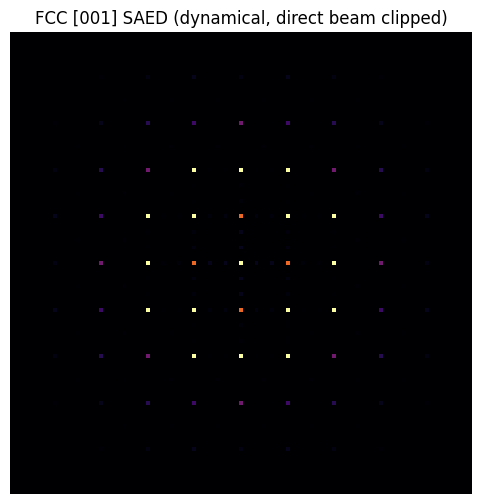

Inner 4 spots = {200}; diagonal = {220}.


In [28]:
atoms = AbtemDiffraction.build_crystal("Au", "fcc", 4.05, size=(6, 6, 20))
print(f"{len(atoms)} atoms, cell {np.round(atoms.cell.lengths(),1)} A")

dp = eng.saed(atoms)                              # static (single config)
fig, ax = plt.subplots(figsize=(6, 6))
AbtemDiffraction.show(ax, dp, title="FCC [001] SAED (dynamical, direct beam clipped)")
plt.show()
print("Inner 4 spots = {200}; diagonal = {220}.")


## 3. Frozen phonons — thermal-diffuse background

`num_frozen_phonons > 0` averages that many displaced-atom configurations, adding the
diffuse background that real patterns have (and that analysis tools expect). A few configs
suffice for CPU; real work uses 16–32.

tasks:  75%|#######5  | 3/4 [00:02<00:00,  1.37it/s]

tasks:  21%|##        | 5/24 [00:03<00:15,  1.25it/s]

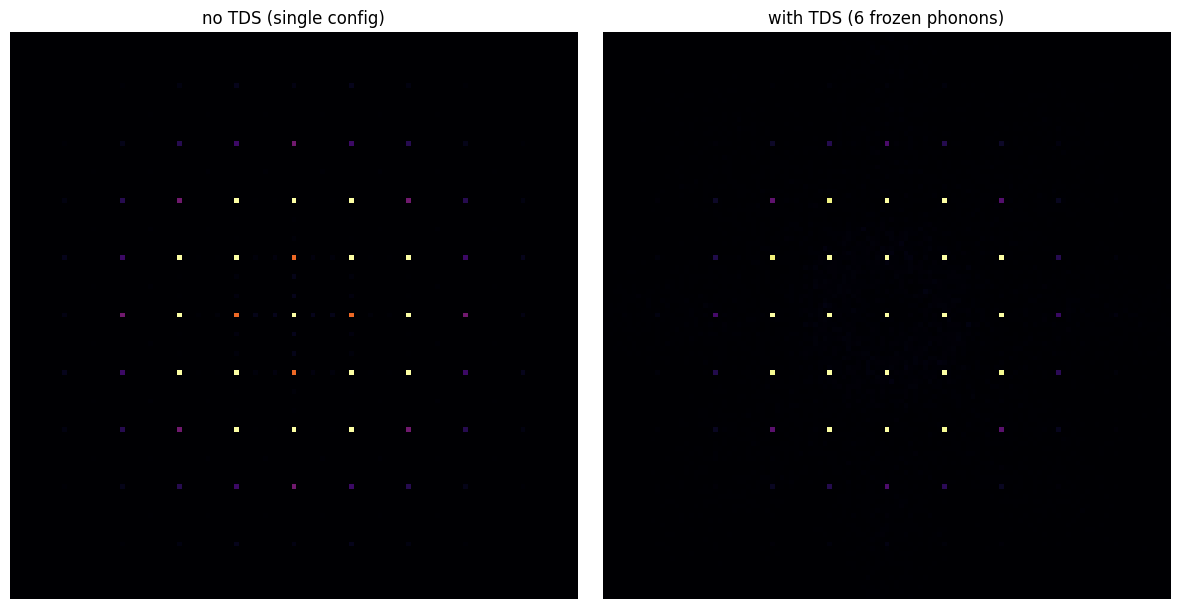

With TDS: diffuse background between spots + redistributed intensity.


In [29]:
dp_static = eng.saed(atoms, num_frozen_phonons=0)
dp_tds     = eng.saed(atoms, num_frozen_phonons=6)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
AbtemDiffraction.show(axs[0], dp_static, title="no TDS (single config)")
AbtemDiffraction.show(axs[1], dp_tds,    title="with TDS (6 frozen phonons)")
plt.tight_layout(); plt.show()
print("With TDS: diffuse background between spots + redistributed intensity.")


## 4. CBED — convergent-beam diffraction

A focused probe turns each reflection into a *disk* the size of the convergence angle.
Small convergence → separated disks; large convergence → overlapping disks (Ronchigram /
ptychography regime). For FCC Au the disks are ~10–12 mrad apart, so 8 mrad keeps them
separated.

tasks:  83%|########3 | 5/6 [00:02<00:00,  2.02it/s]

tasks:  83%|########3 | 5/6 [00:02<00:00,  2.25it/s]

tasks:  83%|########3 | 5/6 [00:02<00:00,  2.02it/s]

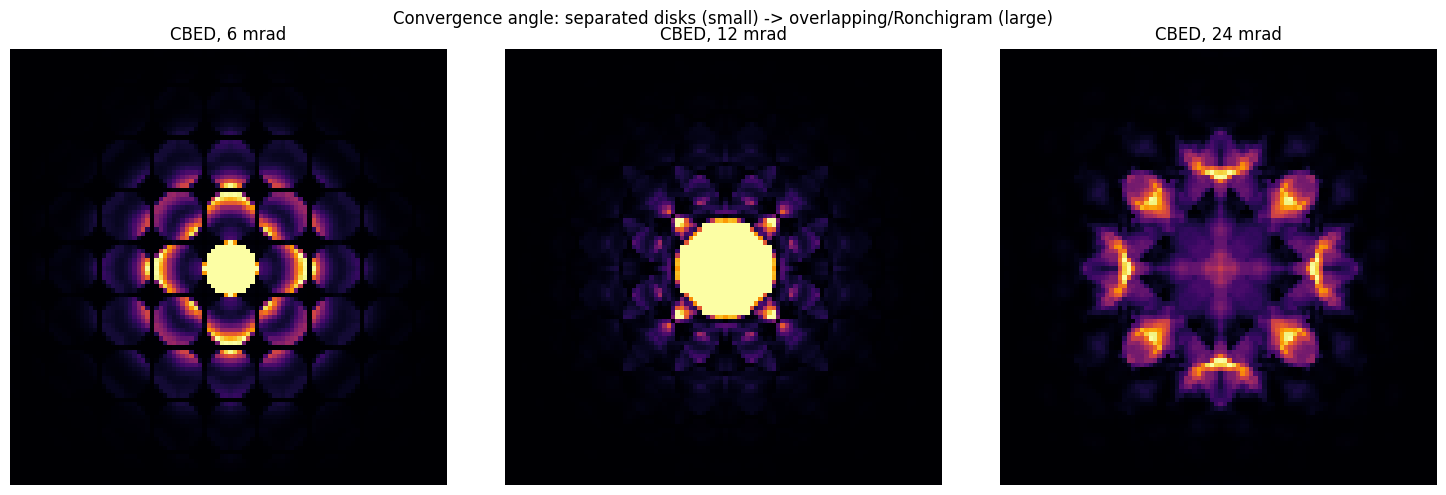

In [30]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for ax, conv in zip(axs, [6, 12, 24]):
    cb = eng.cbed(atoms, convergence_mrad=conv)
    AbtemDiffraction.show(ax, cb, beamstop_radius=int(conv*1.2), title=f"CBED, {conv} mrad")
plt.suptitle("Convergence angle: separated disks (small) -> overlapping/Ronchigram (large)")
plt.tight_layout(); plt.show()


## 5. 4D-STEM scan → portable dataset

`scan_4d` records a CBED pattern at every probe position and returns a 4D array
`(scan_y, scan_x, det_y, det_x)` plus a metadata dict. Save it with `save_4d`; any analysis
tool (py4DSTEM's `DataCube`) opens it directly. Kept small for CPU.

tasks:  75%|#######5  | 3/4 [00:20<00:06,  6.74s/it]

4D shape: (6, 6, 100, 100) | meta: {'convergence_mrad': 8.0, 'scan_gpts': (6, 6), 'scan_extent_A': [8.0, 8.0], 'energy_kev': 200.0, 'max_angle_mrad': 50.0, 'shape': (6, 6, 100, 100)}


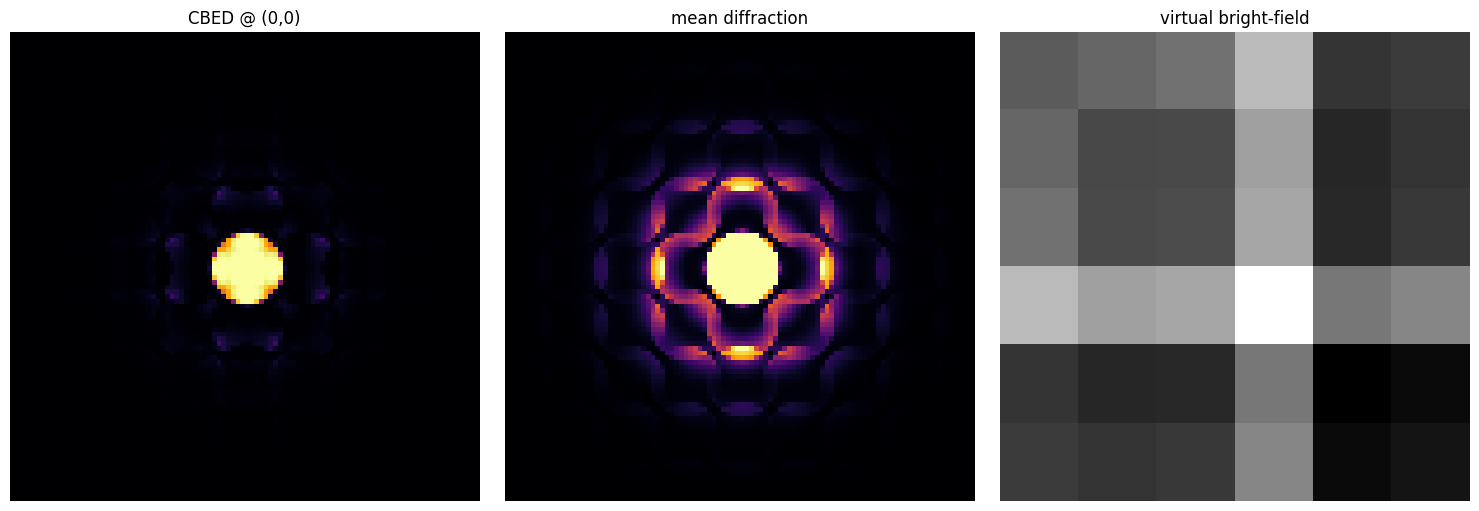

Saved fcc_4dstem.npy -> load elsewhere with py4DSTEM.DataCube(data=np.load(...)).


In [31]:
data_4d, meta = eng.scan_4d(atoms, convergence_mrad=8, scan_gpts=(6, 6))
print("4D shape:", data_4d.shape, "| meta:", meta)
AbtemDiffraction.save_4d(data_4d, "fcc_4dstem.npy")

# quick look at a few positions + a mean pattern + a virtual bright-field (plain numpy)
dp_mean = data_4d.mean(axis=(0, 1))
qy, qx = data_4d.shape[2] // 2, data_4d.shape[3] // 2
Y, X = np.mgrid[0:data_4d.shape[2], 0:data_4d.shape[3]]
bf = (data_4d * (np.hypot(Y-qy, X-qx) <= 8)[None, None]).sum(axis=(2, 3))

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
AbtemDiffraction.show(axs[0], data_4d[0, 0], beamstop_radius=10, title="CBED @ (0,0)")
AbtemDiffraction.show(axs[1], dp_mean, beamstop_radius=10, title="mean diffraction")
axs[2].imshow(bf, cmap="gray"); axs[2].set_title("virtual bright-field"); axs[2].axis("off")
plt.tight_layout(); plt.show()
print("Saved fcc_4dstem.npy -> load elsewhere with py4DSTEM.DataCube(data=np.load(...)).")


## 6. Different samples

**Route A — materials via ASE** (self-contained): one line each; different structures give
different diffraction symmetry.

tasks:  75%|#######5  | 3/4 [00:00<00:00,  3.66it/s]

tasks:  75%|#######5  | 3/4 [00:01<00:00,  1.59it/s]

tasks:  75%|#######5  | 3/4 [00:01<00:00,  2.32it/s]

tasks:  75%|#######5  | 3/4 [00:02<00:00,  1.38it/s]

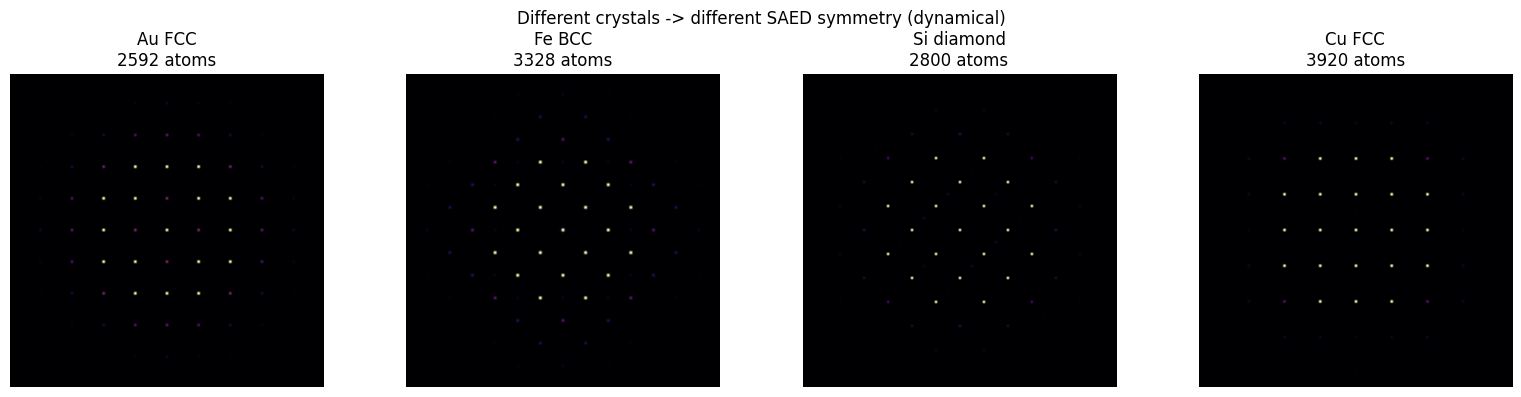

In [32]:
materials = [
    ("Au FCC",     ("Au", "fcc",     4.05, (6, 6, 18))),
    ("Fe BCC",     ("Fe", "bcc",     2.87, (8, 8, 26))),
    ("Si diamond", ("Si", "diamond", 5.43, (5, 5, 14))),
    ("Cu FCC",     ("Cu", "fcc",     3.61, (7, 7, 20))),
]
fig, axs = plt.subplots(1, len(materials), figsize=(4*len(materials), 4))
for ax, (name, (el, st, a, sz)) in zip(axs, materials):
    aa = AbtemDiffraction.build_crystal(el, st, a, size=sz)
    AbtemDiffraction.show(ax, eng.saed(aa), title=f"{name}\n{len(aa)} atoms")
plt.suptitle("Different crystals -> different SAED symmetry (dynamical)")
plt.tight_layout(); plt.show()


**Route B — the twin's *own* samples.** This is the integration point: any twin sample
hands back atoms via `get_atoms_in_region`, and `atoms_from_twin_sample` wraps them for the
same engine — so the dynamical pattern is of *your actual modeled object* (a defect, a
grain, an Atomsk cell), not a generic crystal.

**On sizing the request.** Twin samples honour the region they are asked
for, which changes this route in two ways:

- **Atom counts follow your request.** For the call below (`half_width_um=0.02`, a 400 Å
  box) the twin used to return a fixed ~93k atoms in a ~100 Å cube regardless of what you
  asked; it now returns ~209k in a ~139 Å cube (a *representative* volume — 400 Å of
  crystal is ~1.4 × 10⁶ atoms, too many to enumerate). `max_lateral_A` /
  `max_thickness_A` still crop to a tractable box, so what reaches multislice grew only
  from ~31k to ~36.5k atoms.
- **You can now ask for the box you actually want.** `half_width_um=0.003` returns ~36.5k
  atoms spanning 57 Å — the real atoms in that field — so the crop becomes unnecessary.
  This is the pattern to follow.

**Note on `dislocation_crystal`:** its default view is the **[111] zone axis**
(hexagonal projection), not [001]. Pass `zone_axis="001"` for the old square net. The
Burgers-vector default also changed to 2.525 Å = |a/2⟨110⟩|, the real FCC slip vector.

Run this cell inside the twin environment (the `samples` package must be importable).

twin sample -> 18923 atoms, cell [50.5 50.5 79.1] A


tasks:  75%|#######5  | 3/4 [00:08<00:02,  2.90s/it]

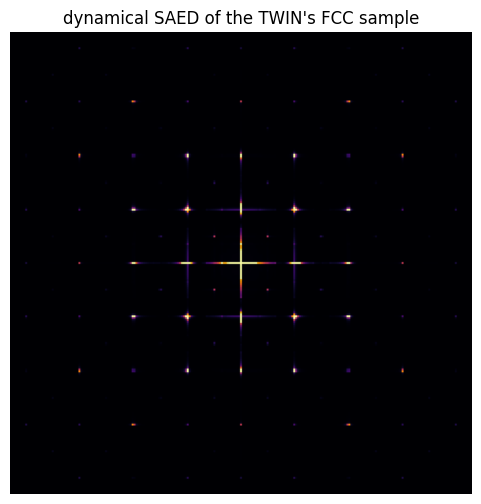

In [33]:
# --- Route B: from the twin's own samples (needs the twin `samples` package) ---
try:
    import samples  # the twin's sample registry
    s = samples.get_sample("fcc_single_crystal")          # or bcc_single_crystal, dislocation_crystal, ...
    twin_atoms = eng.atoms_from_twin_sample(s, half_width_um=0.02, depth_nm=10,
                                            max_lateral_A=50, max_thickness_A=80)
    print(f"twin sample -> {len(twin_atoms)} atoms, cell {np.round(twin_atoms.cell.lengths(),1)} A")
    dp_twin = eng.saed(twin_atoms)
    fig, ax = plt.subplots(figsize=(6, 6))
    AbtemDiffraction.show(ax, dp_twin, title="dynamical SAED of the TWIN's FCC sample")
    plt.show()
except ModuleNotFoundError:
    print("`samples` package not on the path — run this inside the twin environment.")
    print("(Route A above is fully self-contained and does not need the twin.)")


## Notes & limits

- **Fidelity ceiling is the structure, not the engine.** Multislice faithfully computes the
  diffraction of whatever atoms you give it — so for cases where the *object* must be right
  (a real dislocation core, a real strain field, texture), feed in an Atomsk/MD structure via
  the same `atoms` entry point. Add detector PSF/MTF and Poisson noise on top if your analyzer
  is sensitive to them (the twin already models dose).
- **Direct beam is kept in the data.** `show` only *displays* it clipped (beam stop); saved
  arrays contain the full pattern, which is what analysis tools need.
- **Large tilts:** `saed(..., tilt_mrad=...)` is small-angle (fine alignment). For big
  zone-axis changes use `tilted_atoms(atoms, tilt_deg_x=...)` (rotates the structure; the
  cell is then only approximately periodic at the faces — use a thick enough slab).
- **py4DSTEM round-trip:** load a saved `.npy` in a *separate, isolated* environment
  (`pip install py4dstem` downgrades NumPy to <2; restart the runtime), then
  `py4DSTEM.DataCube(data=np.load("fcc_4dstem.npy"))`.
- **GPU:** for full 128×128 scans with many phonon configs, set
  `abtem.config.set({"device": "gpu"})` (needs CuPy) — the cost is paid once at generation.


## Standalone multislice appendix (py4DSTEM round-trip, packaging notes)

## 0. Install (CPU build) — no version conflicts

The core of this appendix needs only **abTEM** and **ASE**, which work with the NumPy 2.x
that Colab ships — so there is **nothing to downgrade and no runtime restart**.

> **Important:** do *not* `pip install py4dstem` here. py4DSTEM currently pins `numpy<2`,
> which forces a NumPy downgrade and breaks the NumPy-2 packages Colab pre-installs
> (that is the source of the `numpy 1.26.4 is incompatible` errors). We keep py4DSTEM out
> of the core notebook and, in the optional Section 5, do the same analysis with plain
> NumPy — no extra dependency. A separate cell shows the real py4DSTEM call for anyone who
> specifically wants it, with the correct isolated-install instructions.

In [34]:
# Core dependencies only. These are compatible with Colab's NumPy 2.x.
!pip -q install abtem ase
import abtem, ase, numpy as np, matplotlib.pyplot as plt
print("abtem", abtem.__version__, "| ase", ase.__version__, "| numpy", np.__version__)


def show_diffraction(ax, pattern, title=None, beamstop_radius=6, cmap="inferno"):
    """Display a diffraction pattern with the direct (000) beam suppressed.

    In any diffraction pattern the undiffracted 'direct beam' at the centre is
    ~100x brighter than the Bragg spots, so a plain (even log) display shows only
    that central dot and the spots vanish. We clip the display maximum to the
    Bragg-spot level -- the direct beam saturates (as it does behind a real beam
    stop) and the weaker spots become visible. This changes only the DISPLAY, not
    the data."""
    p = np.asarray(pattern, dtype=float)
    cy, cx = np.unravel_index(np.argmax(p), p.shape)
    Y, X = np.mgrid[0:p.shape[0], 0:p.shape[1]]
    outside = np.hypot(Y - cy, X - cx) > beamstop_radius
    vmax = np.percentile(p[outside], 99.9) if outside.any() else p.max()
    vmax = max(vmax, 1e-12)
    ax.imshow(p, cmap=cmap, vmax=vmax)   # clip the bright direct beam
    ax.axis("off")
    if title:
        ax.set_title(title)


abtem 1.0.10 | ase 3.29.0 | numpy 2.1.3


## 1. Build the FCC crystal (same material as the twin: Au, a = 4.05 Å)

We build the atoms directly with ASE so the appendix is standalone. In the integrated
tool you would instead take `positions, Z = sample.get_atoms_in_region(...)` from the twin
and wrap them in an `ase.Atoms` object — the rest of this notebook is identical.

3600 atoms; cell (A) = [ 24.3  24.3 101.2]


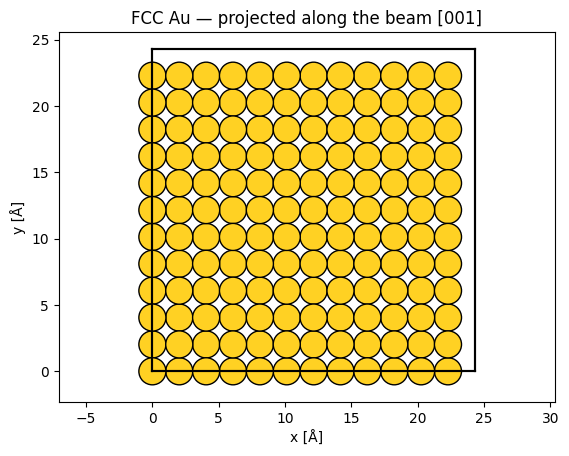

In [35]:
from ase.build import bulk

# Cubic FCC Au conventional cell, tiled to a thin slab.
#   lateral: 6x6 cells (~24 x 24 A)   thickness: 25 cells (~101 A ~ 10 nm)
a_Au = 4.05
atoms = bulk("Au", "fcc", a=a_Au, cubic=True) * (6, 6, 25)
print(f"{len(atoms)} atoms; cell (A) = {np.round(atoms.cell.lengths(), 1)}")

# --- how you would instead ingest atoms FROM the twin sample -------------------
# from ase import Atoms
# positions_A, Z = sample.get_atoms_in_region(cx_um=0, cy_um=0, half_width_um=0.02, depth_nm=10)
# atoms = Atoms(numbers=Z, positions=positions_A, cell=[Lx, Ly, Lz], pbc=True)
# -------------------------------------------------------------------------------

abtem.show_atoms(atoms, plane="xy", title="FCC Au — projected along the beam [001]")
plt.show()


## 2. A single dynamical SAED pattern (multislice)

We build a projected **potential** (sliced along the beam), send a **plane wave** through
it (multislice), and take the exit-wave **diffraction pattern**. Unlike the kinematical
engine, the spot *intensities* here reflect multiple scattering and the direct-beam
depletion, and they change correctly with thickness.

**About the bright centre.** Every diffraction pattern has a very bright spot in the middle
— the **direct (undiffracted) beam**. It is typically ~100× brighter than the Bragg spots,
so a naive display shows only that central dot and the spots look like they are missing.
They are not: we simply clip the display maximum to the Bragg level (`show_diffraction`
above), which saturates the direct beam — exactly what a physical **beam stop** does — so the
weaker diffracted spots become visible. This is a display choice; the data is unchanged.

tasks:  75%|#######5  | 3/4 [00:01<00:00,  1.94it/s]

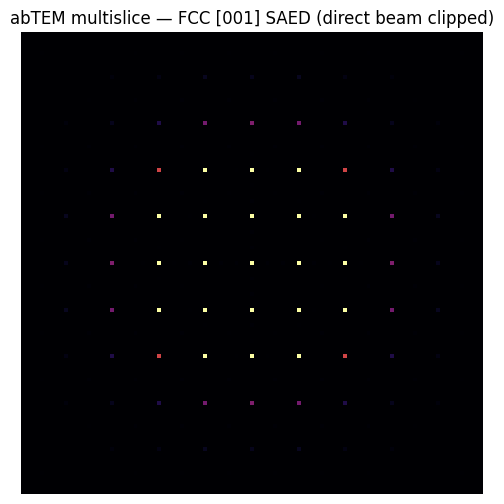

pattern shape: (119, 119)
The four inner spots are the {200} family; the diagonal ones are {220}.


In [36]:
# Potential: 0.08 A sampling, 2 A slices. 'infinite' projection is the standard fast choice.
potential = abtem.Potential(atoms, sampling=0.08, slice_thickness=2.0,
                            projection="infinite", parametrization="lobato")

# 200 kV plane-wave illumination -> exit wave -> diffraction pattern (out to 60 mrad).
plane_wave = abtem.PlaneWave(energy=200e3, sampling=0.08)
exit_wave  = plane_wave.multislice(potential).compute()
saed       = exit_wave.diffraction_patterns(max_angle=60).compute()

dp = np.asarray(saed.array)
fig, ax = plt.subplots(figsize=(6, 6))
# The bright centre is the DIRECT (undiffracted) beam -- ~100x brighter than the
# Bragg spots. show_diffraction clips it (like a beam stop) so the spots are visible.
show_diffraction(ax, dp, title="abTEM multislice — FCC [001] SAED (direct beam clipped)")
plt.show()
print("pattern shape:", dp.shape)
print("The four inner spots are the {200} family; the diagonal ones are {220}.")


## 3. Frozen phonons — the thermal-diffuse background

Real diffraction has a diffuse background from thermal atomic vibration (thermal-diffuse
scattering, TDS). Multislice reproduces it by averaging over several *frozen* snapshots of
displaced atoms. This background matters for analysis tools that background-subtract or fit
intensities — data without it is "too clean" and an analyzer may behave differently than on
real data. We use a few configs here for CPU; real work uses 16–32.

tasks:  31%|###1      | 5/16 [00:03<00:08,  1.25it/s]

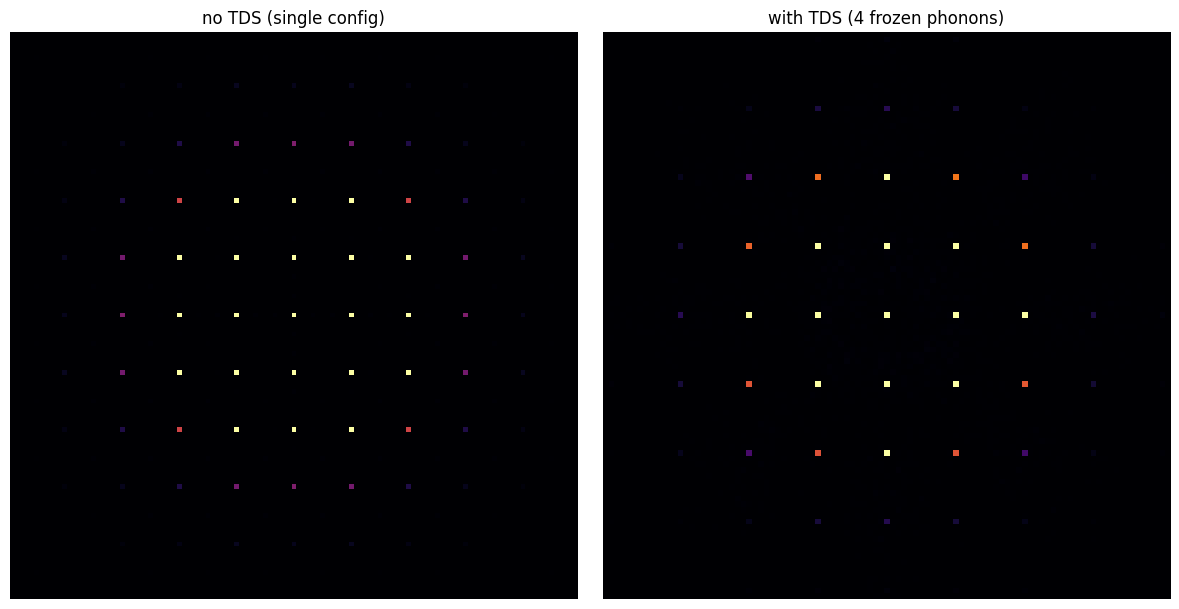

With frozen phonons, note the diffuse background between the spots (thermal-diffuse
scattering) and the redistributed intensity -- absent in the single-config pattern.


In [37]:
# sigmas ~ 0.08-0.10 A is a typical RMS thermal displacement at room temperature for Au.
frozen = abtem.FrozenPhonons(atoms, num_configs=4, sigmas=0.1, seed=1)
pot_fp = abtem.Potential(frozen, sampling=0.10, slice_thickness=2.0, projection="infinite")

saed_fp = (abtem.PlaneWave(energy=200e3, sampling=0.10)
           .multislice(pot_fp)
           .diffraction_patterns(max_angle=50)
           .mean(0)                     # average over the phonon configurations
           .compute())

dp_fp = np.asarray(saed_fp.array)
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
show_diffraction(axs[0], dp,    title="no TDS (single config)")
show_diffraction(axs[1], dp_fp, title=f"with TDS ({frozen.num_configs} frozen phonons)")
plt.tight_layout(); plt.show()
print("With frozen phonons, note the diffuse background between the spots (thermal-diffuse")
print("scattering) and the redistributed intensity -- absent in the single-config pattern.")


## 4. A small 4D-STEM scan → a portable 4D dataset

4D-STEM records a full diffraction pattern at every probe position, using a **convergent
probe** (a focused beam) rather than a plane wave. With a convergent probe each Bragg
reflection is no longer a sharp point — it spreads into a **disk** the size of the
convergence angle. So these patterns look different from the SAED spots above: they are
*CBED* (convergent-beam) patterns.

**A note on the convergence angle — this controls how the pattern looks.** If the
convergence semiangle is *smaller* than the spacing between reflections, the disks stay
separated and you see clean, spot-like disks. If it is *larger*, the disks **overlap** and
interference fringes appear in the overlaps — a "Ronchigram"-like pattern (this overlap is
exactly what ptychography reconstructs). For FCC Au at 200 kV the disks are ~10–12 mrad
apart, so we use **8 mrad** here to keep the disks separated and the pattern readable. Try
raising it to 20–30 mrad to see the overlapping-disk / ptychography regime.

We use a tiny **6×6** scan over a small region (kept small for CPU — real scans are
128×128+). The result is a 4D array `(scan_y, scan_x, det_y, det_x)` saved as a plain
`.npy`, which any analysis tool can open (py4DSTEM's `DataCube` wraps it directly).

tasks:  75%|#######5  | 3/4 [00:12<00:04,  4.28s/it]

4D-STEM dataset shape: (6, 6, 99, 99)  (convergence = 8 mrad)
saved -> fcc_4dstem.npy


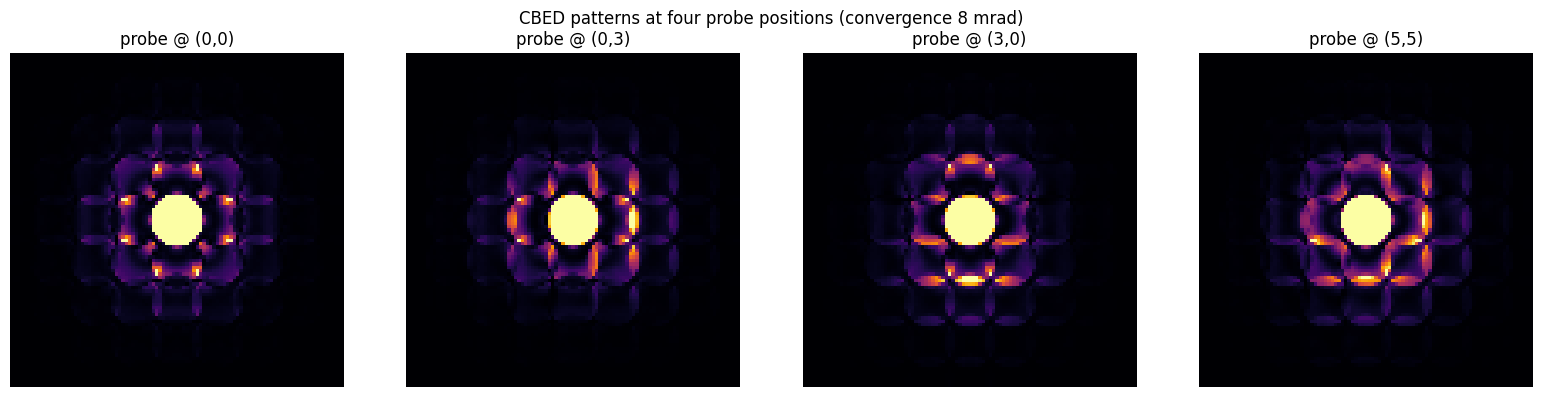

In [38]:
# Convergent probe. semiangle_cutoff sets the disk size:
#   8 mrad  < ~12 mrad disk spacing -> SEPARATED disks (clean, readable)
#   20-30 mrad                       -> OVERLAPPING disks (Ronchigram/ptychography)
CONV_MRAD = 8
probe = abtem.Probe(energy=200e3, semiangle_cutoff=CONV_MRAD, sampling=0.10)
pot_scan = abtem.Potential(atoms, sampling=0.10, slice_thickness=2.0, projection="infinite")
probe.grid.match(pot_scan)

# Scan a small region. We end just short of a full lattice repeat and scan a couple of
# unit cells so the sampled positions are representative (not all on one symmetry site).
scan_end = 2 * a_Au * (5/6)
scan = abtem.GridScan(start=(0, 0), end=(scan_end, scan_end), gpts=(6, 6))
detector = abtem.PixelatedDetector(max_angle=50)

dataset = probe.scan(pot_scan, scan=scan, detectors=detector).compute()
data_4d = np.asarray(dataset.array).astype(np.float32)   # (6, 6, det_y, det_x)
print(f"4D-STEM dataset shape: {data_4d.shape}  (convergence = {CONV_MRAD} mrad)")

np.save("fcc_4dstem.npy", data_4d)
print("saved -> fcc_4dstem.npy")

# A few CBED patterns across the scan (disks stay put; their intensities modulate).
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for ax, (iy, ix) in zip(axs, [(0,0),(0,3),(3,0),(5,5)]):
    show_diffraction(ax, data_4d[iy, ix], title=f"probe @ ({iy},{ix})", beamstop_radius=10)
plt.suptitle(f"CBED patterns at four probe positions (convergence {CONV_MRAD} mrad)")
plt.tight_layout(); plt.show()


## 5. Round-trip: analyse the simulated data as an external tool would

The point of the appendix: an analysis tool should treat the simulated 4D data like
experimental data. The two operations below — the **mean diffraction pattern** and a
**virtual bright-field** image — are exactly what a 4D-STEM analysis package does first,
and they need nothing beyond NumPy, so this runs with no extra dependency and no NumPy
conflict. (Section 5b shows the identical operations through py4DSTEM itself, isolated,
for anyone who wants the real library in the loop.)

loaded 4D dataset: (6, 6, 99, 99)


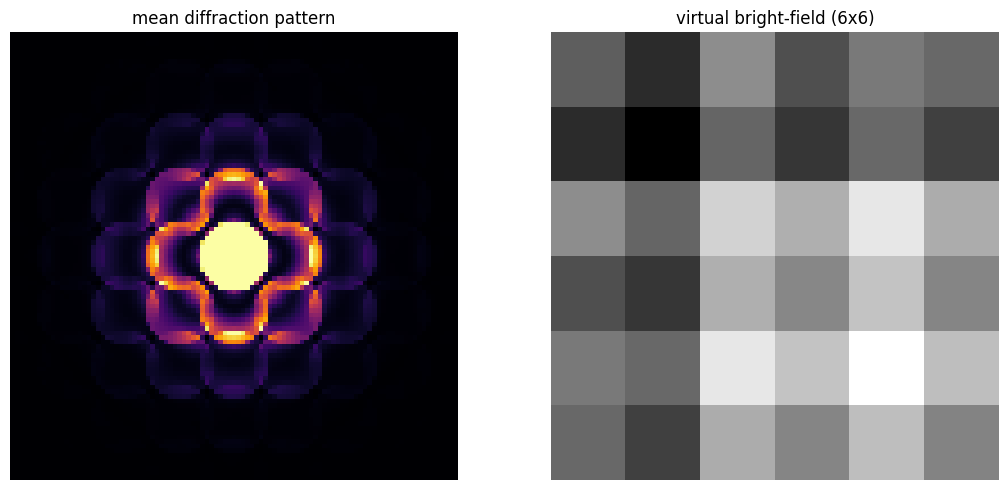

Round-trip complete: twin-style atoms -> abTEM multislice -> 4D dataset -> analysis.


In [39]:
# Load the saved dataset (as any external tool would open a file).
data_4d = np.load("fcc_4dstem.npy")          # (scan_y, scan_x, det_y, det_x)
sy, sx, qy, qx = data_4d.shape
print("loaded 4D dataset:", data_4d.shape)

# (1) Mean diffraction pattern over all probe positions.
dp_mean = data_4d.mean(axis=(0, 1))

# (2) Virtual bright-field: integrate a disk around the direct beam at each position.
cy, cx = qy // 2, qx // 2
Y, X = np.mgrid[0:qy, 0:qx]
bf_disk = np.hypot(Y - cy, X - cx) <= 6
bf_image = (data_4d * bf_disk[None, None]).sum(axis=(2, 3))

fig, axs = plt.subplots(1, 2, figsize=(11, 5))
show_diffraction(axs[0], dp_mean, title="mean diffraction pattern", beamstop_radius=10)
axs[1].imshow(bf_image, cmap="gray")
axs[1].set_title(f"virtual bright-field ({sy}x{sx})"); axs[1].axis("off")
plt.tight_layout(); plt.show()
print("Round-trip complete: twin-style atoms -> abTEM multislice -> 4D dataset -> analysis.")


### 5b. (Optional) The same round-trip through py4DSTEM itself

py4DSTEM is the standard 4D-STEM analysis package, and it reads our saved array directly.
The **only** catch is packaging: py4DSTEM currently requires `numpy<2`, so installing it in
Colab downgrades NumPy and **requires a runtime restart** (and will show incompatibility
warnings for Colab's NumPy-2 packages — harmless for this isolated analysis). Run this
section **only if you want py4DSTEM specifically**, and treat it as a separate step:

1. Run the cell below to install py4DSTEM (it will downgrade NumPy).
2. **Runtime → Restart session** (required for the new NumPy to load).
3. Re-run the imports and the analysis cell (skip the abTEM sections — the `.npy` is already
   on disk).

If you just need the analysis, Section 5 above already did it with no downgrade.

In [40]:
# --- OPTIONAL: only run if you specifically want py4DSTEM ---
# This downgrades NumPy to <2. Restart the runtime afterwards, then run the next cell.
# !pip -q install py4dstem
#
# After restarting the runtime, run:
#
# import numpy as np, py4DSTEM
# dc = py4DSTEM.DataCube(data=np.load("fcc_4dstem.npy"))
# dp_mean = dc.get_dp_mean()
# qy0, qx0 = dc.Qshape[0] // 2, dc.Qshape[1] // 2
# dc.get_virtual_image(mode="circle", geometry=((qy0, qx0), 6), name="BF")
# bf = dc.tree("BF").data
# # ... then plot dp_mean.data and bf as in Section 5.
print("Section 5b is optional and commented out by default (see the markdown above).")


Section 5b is optional and commented out by default (see the markdown above).


## 6. Trying more samples

Everything above works for *any* structure — you just change the atoms. There are two
routes.

**Route A — different materials with ASE (self-contained).** `ase.build.bulk` knows the
common crystal structures, so one line gives you a new crystal. Different structures give
visibly different diffraction symmetry.

tasks:  75%|#######5  | 3/4 [00:01<00:00,  1.56it/s]

tasks:  75%|#######5  | 3/4 [00:01<00:00,  2.34it/s]

tasks:  75%|#######5  | 3/4 [00:03<00:01,  1.23s/it]

tasks:  75%|#######5  | 3/4 [00:06<00:02,  2.13s/it]

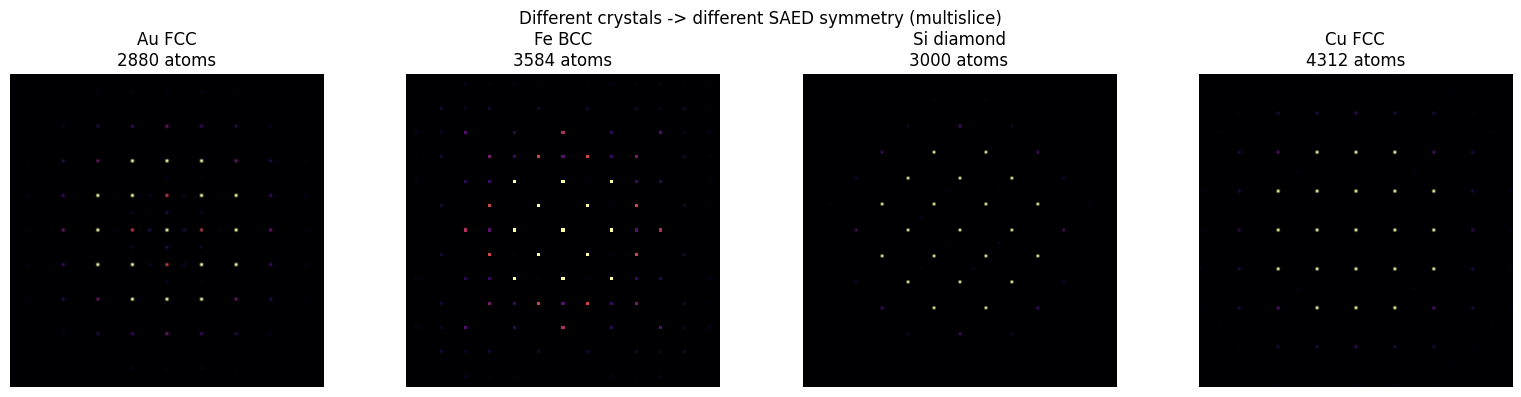

In [41]:
from ase.build import bulk

more_samples = [
    ("Au FCC",     bulk("Au", "fcc",     a=4.05, cubic=True) * (6, 6, 20)),
    ("Fe BCC",     bulk("Fe", "bcc",     a=2.87, cubic=True) * (8, 8, 28)),
    ("Si diamond", bulk("Si", "diamond", a=5.43, cubic=True) * (5, 5, 15)),
    ("Cu FCC",     bulk("Cu", "fcc",     a=3.61, cubic=True) * (7, 7, 22)),
]

fig, axs = plt.subplots(1, len(more_samples), figsize=(4*len(more_samples), 4))
for ax, (name, aa) in zip(axs, more_samples):
    pot = abtem.Potential(aa, sampling=0.09, slice_thickness=2.0, projection="infinite")
    dp = (abtem.PlaneWave(energy=200e3, sampling=0.09)
          .multislice(pot).diffraction_patterns(max_angle=55).compute())
    show_diffraction(ax, np.asarray(dp.array), title=f"{name}\n{len(aa)} atoms")
plt.suptitle("Different crystals -> different SAED symmetry (multislice)")
plt.tight_layout(); plt.show()


**Route B — the *same* structures you built in the main twin.** This is the point of the
shared `get_atoms_in_region` interface: any twin sample (single crystals, the polycrystal,
the dislocation crystal, an Atomsk-loaded cell) hands back `(positions_Å, atomic_numbers)`,
which you wrap in an `ase.Atoms` and feed to the identical abTEM code. Then the dynamical
pattern corresponds to *your actual modeled object* — e.g. the multislice diffraction of the
specific dislocation or grain structure from the main notebook, not a generic crystal.

The snippet below is the bridge (commented out, since it needs the twin's `samples` package
on the path). Everything after the `atoms = ...` line is the same as Sections 2–5.

**Two properties of the sample layer matter here:**

- `get_atoms_in_region``get_atoms_in_region` is **region-honest** — it returns the atoms really in the
  box you ask for, rather than a fixed-size block. So `half_width_um` is now a real
  control: `0.003` gives ~36.5k atoms spanning 57 Å (exact), while `0.02` asks for 400 Å
  of crystal (~1.4 × 10⁶ atoms) and therefore falls back to a *representative* ~139 Å
  volume of ~209k atoms. Ask for the box you want; size the request, not the crop.
- **`dislocation_crystal` now defaults to the [111] zone axis** (hexagonal projection)
  rather than [001]. If you want the old square net, pass `zone_axis="001"`. Its
  `burgers_A` default is also now 2.525 Å = |a/2⟨110⟩|, the real FCC slip vector.

`polycrystal_grains` additionally defaults to `orientation_mode="random_zone_axes"`, so
each grain sits on a different low-index zone axis — worth knowing if you bridge a
boundary-spanning region, since the pattern will be a genuine two-orientation overlap.


In [42]:
# --- Bridge from a twin sample to abTEM (run inside the main twin environment) ---
# import sys; sys.path.append("path/to/your/twin")   # where the `samples` package lives
# import samples
# from ase import Atoms
#
# sample = samples.get_sample("dislocation_crystal")   # or bcc_single_crystal, polycrystal_grains, ...
#                                                      # dislocation_crystal defaults to zone_axis="111"
#                                                      # -> hexagonal projection. Use zone_axis="001" for the old net.
# sample.generate_volume(40, 256, 256)                 # some samples need this first
# # Samples honour the requested region, so size the REQUEST, not a later crop.
# # half_width_um=0.003 -> ~36.5k atoms spanning 57 A (exact, multislice-sized).
# # half_width_um=0.02  -> a 400 A ask (~1.4e6 atoms) -> representative ~139 A volume.
# positions_A, Z = sample.get_atoms_in_region(cx_um=0, cy_um=0, half_width_um=0.003, depth_nm=12)
#
# # Wrap in an ASE Atoms with a periodic cell matching the returned extent.
# ext = positions_A.max(axis=0) - positions_A.min(axis=0)
# atoms_from_twin = Atoms(numbers=Z, positions=positions_A - positions_A.min(axis=0),
#                         cell=[ext[0], ext[1], ext[2]], pbc=True)
#
# # ...then run exactly the Section 2 / 3 / 4 code on `atoms_from_twin`.
print("Route B is a commented bridge: wrap twin get_atoms_in_region() output as ase.Atoms.")


Route B is a commented bridge: wrap twin get_atoms_in_region() output as ase.Atoms.


## Notes, limits, and the GPU next step

**What you gained over the kinematical engine.** Physically correct spot *intensities*,
thickness-dependent dynamical behaviour, and (with frozen phonons) a realistic thermal-diffuse
background — the channels that quantitative analysis tools (thickness, atom-counting, strain,
ptychography) actually read. Positions were already correct kinematically; *intensities and
background* are what multislice adds.

**What is still on you (not the engine).** "As good as real" is capped by the **structure**,
not just the physics: an idealised procedural crystal gives the diffraction *of an idealised
crystal*. For studies where the object must be right (a specific dislocation core, a real strain
field, a textured polycrystal), feed in a realistic structure — an Atomsk build or an MD/relaxed
cell via ASE — using the same `atoms` entry point as Section 1. Also add **detector effects**
(camera point-spread/MTF, Poisson noise; the twin already models dose) on top of the simulated
pattern if your analyzer is sensitive to them.

**Validate the validator.** To *claim* the simulated data is analysis-grade, show the external
tool recovers a **known** ground truth from it (e.g. feed a known-thickness cell and confirm the
thickness is recovered). That test earns the claim.

**Why CPU is fine here but a GPU matters at scale.** Every step above is small on purpose. The
expensive case is a **full 4D scan** (128×128 positions) with **many phonon configs** — impractical
on CPU, but well within reach on a GPU. abTEM runs on GPU via CuPy (`abtem.config.set({"device":
"gpu"})`); Prismatic's PRISM algorithm is purpose-built to accelerate *scanned* STEM and can be
dramatically faster for large 4D datasets on CUDA hardware. The delay is a **generation-time** cost
paid once, after which the external analysis runs on the saved dataset at full speed. That is the
right place to spend the time — and it keeps the interactive twin fast for its actual job
(testing acquisition and decision logic).